# Некоторые приемы предсказания ВР

При построении моделей прогноза полезным использование таких приемов, как:
* Оконное тестирование данных [(обратное тестирование)](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/introduction-forecasting/introduction-forecasting.html#backtesting-forecasting-models).
* Использование дополнительных метрик [оценки качества прогноза](https://www.lokad.com/forecasting-accuracy-definition/), в том числе [вероятностное прогнозирование](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html)
* Построение прогнозов с использованием сторонних библиотек (в первую очередь [`sklearn`](https://www.aeon-toolkit.org/en/latest/examples/forecasting/forecasting_sklearn.html))
* Конвейеризация и автоматический выбор ступеней конвейера, их параметров и вариантов ([`auto ml`](https://arxiv.org/abs/2312.08528))
* [Ансамблирование прогнозов](https://habr.com/ru/articles/571296/).

В целом отметим [общий фреймворк](https://unit8.com/resources/darts-time-series-made-easy-in-python/), который можно бы было рекомендовать при проектироании экспериментов по предсказанию ВР одолженную в пакете [`darts`](https://github.com/unit8co/darts):
<img src="https://unit8.com/wp-content/uploads/2021/07/1_yaHh5V0AgxEYxJYrv9VQmA.png"
      style="width: 650px">

Также отметим еще один полезный вариант фремворка предсказаний, одолженный в публикациях идей [atuo-sktime](https://arxiv.org/pdf/2312.08528.pdf). В данном случае авторы предлагают рассмотреть нес

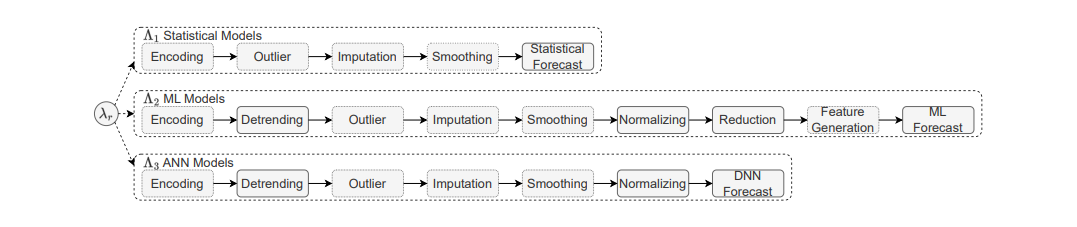

## Импорт и набор данных


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import sktime
# except:
#     !pip3 install sktime --user
#     !pip3 install pmdarima
#     !pip3 install statsmodels
#     !pip3 install prophet
# import sktime

In [5]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
# import pmdarima as pm

In [6]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', category=ConvergenceWarning)
warnings.simplefilter('ignore', category=FutureWarning)
warnings.simplefilter('ignore', category=NotImplementedError)
warnings.simplefilter('ignore', category=UserWarning)
 
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

In [7]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

from sktime.utils.plotting import plot_series
from sktime.utils.plotting import plot_windows
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_evaluation import evaluate
from sktime.transformations.series.impute import Imputer
from sktime.forecasting.model_selection  import ExpandingWindowSplitter, SlidingWindowSplitter
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.performance_metrics.forecasting import  MeanAbsolutePercentageError, MeanSquaredError

smape = MeanAbsolutePercentageError(symmetric = True)
rmse  = MeanSquaredError(square_root=True)

from sktime.transformations.series.difference import Differencer

In [9]:
from sklearn.metrics import mean_squared_error as mse_sk
from sklearn.metrics import mean_absolute_percentage_error

def print_metrics(y_true, y_pred_complex, y_pred_naive):
    # sklearn MAPE не поддерживает symmetric, поэтому используем sktime
    from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
    smape = MeanAbsolutePercentageError(symmetric=True)

    s_c = smape(y_pred_complex, y_true)
    s_n = smape(y_pred_naive, y_true)
    skill = 1 - s_c / s_n

    rmse_complex = mse_sk(y_true, y_pred_complex) ** 0.5

    print(f"sMAPE: {s_c:.3f}")
    print(f"RMSE:  {rmse_complex:.3f}")
    print(f"Skill: {skill:.3f}")

In [10]:
def fix_plot(y, ax=None, tick_step = 10, date_format='%Y-%m-%d'):
    if not ax: ax = plt.gca()
    ax.set_xticks(range(0, len(y), tick_step))  # каждые 10 недель
    ax.set_xticklabels(y.index[::tick_step].strftime('%Y-%m-%d'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

Импорт данных аналогично предыдущего урока.

In [11]:
df = pd.read_csv(
    "OPDS_DE_EDA.csv",
    parse_dates=["time"],
    index_col="time"
)
df.head(1)

,Consumption,Wind,Solar,temperature,radiation_direct_horizontal,hour,month,day_of_week,Consumption_detrended,season,day_of_week_str,daylight_duration,week,is_holiday,Consumption_resid,Wind_resid,Solar_resid,temperature_resid,radiation_direct_horizontal_resid
time,,,,,,,,,,,,,,,,,,,
2015-01-01,41.151,8.852,0.071,-0.981,0.0,0,1,3,-7.29271,Winter,Thu,7.921998,1,True,0.136794,0.610749,0.382488,-4.475639,-7.584582


In [12]:
y = df.Consumption.asfreq('W')
#y.index = y.index.to_period("W")
SEASON = 53 # 53 недели в году
y.head()

time
2015-01-04    38.517
2015-01-11    41.048
2015-01-18    42.468
2015-01-25    43.563
2015-02-01    42.863
Freq: W-SUN, Name: Consumption, dtype: float64

Check splitted data size: Train: 173, Test: 88


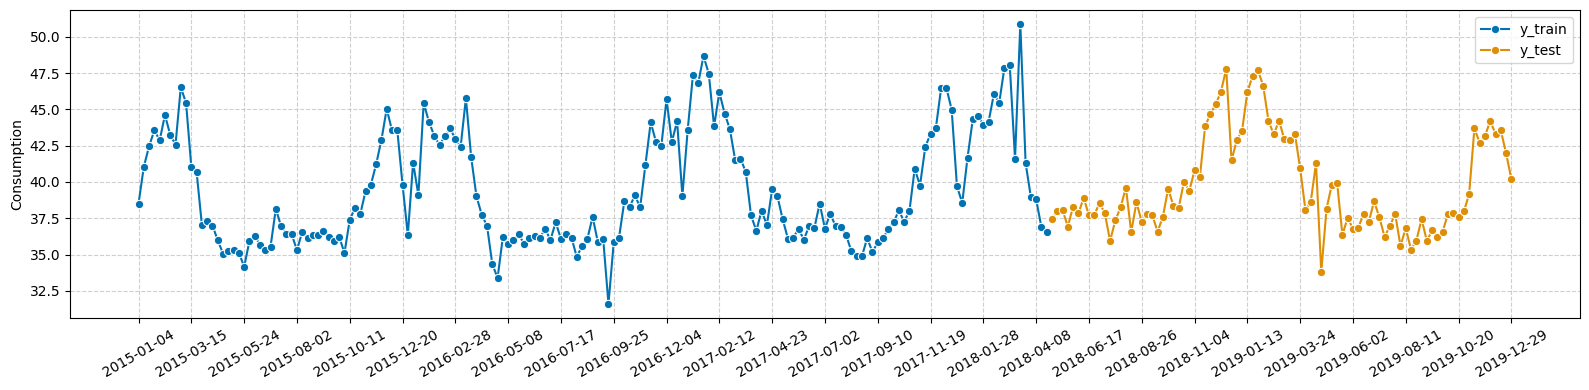

In [303]:
from sktime.split import temporal_train_test_split

TEST_SIZE = int(0.34 * y.size)

y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

print(f'Check splitted data size: Train: {y_train.shape[0]}, Test: {y_test.shape[0]}')

plot_series(y_train, y_test, labels=["y_train", "y_test"])
fix_plot(y)

## Оценека неопределенности модели
### Обратное и последовательное тестирование моделей

Существует как минимум четыре [источника неопределенности](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series) при прогнозировании с помощью моделей временных рядов:
* Случайная составляющая ошибки (флуктуации);
* Ошибка оценки параметров (смещение);
* Ошибка связанная с выбором параметров модели на исторических данных (обобщающая способность, переобучение);
* Ошибка связанная с продолжением процесса генерирования исторических данных в будущем (воспроизводимость паттерном поведения ВР, дрифт данных).

<!-- - __Случайная составляющая ошибки (флуктуации)__ — это неустранимый шум, присущий самой природе данных. Даже при идеально подобранной модели будущие наблюдения будут отклоняться от прогноза из-за непредсказуемых внешних воздействий или внутренней стохастичности процесса.
- __Ошибка оценки параметров (смещение)__ — возникает потому, что параметры модели (например, коэффициенты регрессии или веса в дереве решений) оцениваются на конечной выборке. Эти оценки подвержены выборочной изменчивости: при другом наборе исторических данных они были бы иными, что привело бы к иному прогнозу.
- __Ошибка, связанная с выбором модели на исторических данных__ — отражает неопределённость в архитектуре или гиперпараметрах модели. Мы выбираем одну модель из множества возможных (ARIMA, XGBoost, Prophet и т.д.), но не знаем, действительно ли она наилучшим образом описывает истинный процесс. Эта неопределённость включает риски переобучения, недообучения и ограниченную обобщающую способность.
- __Ошибка, связанная с продолжением процесса генерирования данных в будущем (дрифт данных)__ — предполагает, что закономерности, наблюдаемые в прошлом, сохранятся в будущем. Однако в реальности могут произойти структурные изменения: смена режима работы системы, внешние шоки (экономические, климатические, технологические), изменение поведения пользователей. В таких случаях даже идеальная модель на исторических данных даёт смещённый прогноз. -->


Самый простой способ  повышения надежности  оценки производительности - мы можем  разделить  набор данных несколько раз по аналогии с методом `k-folds`. Однако, в соответствии с особенностями временных рядов - временной связанностью метод`k-folds` должен [не нарушать принцип казуальности](https://forecastegy.com/posts/time-series-cross-validation-python/). Другими словами [выборка валидации должна следовать за тренировочными данными](https://otexts.com/fpp3/tscv.html). Проще всего организовать такое следование в рамках имеющейся тренировочной выборки. Другими словами модель испытывается на исторических (ретро) данных. __Такой подход также известен как [<tt>backtesting/ walk-forward validation</tt>](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html)__.

>Напомним, результат [кросс-валидации](https://www.statology.org/k-fold-cross-validation/) по нескольким блокам более валиден [(менее смещен)](https://machinelearningmastery.com/k-fold-cross-validation/), нежели валидация одной [отложенной выборкой](https://scikit-learn.org/stable/modules/cross_validation.html).

>Backtesting (ретроспективное тестирование) и walk-forward validation  (пошаговая валидация) часто используются как синонимы, но в строгом смысле они отражают разные варианты  одного и того же принципа.
>
>__Walk-forward validation__ -  процедура при которой: начальное обучающее окно фиксируется (например, первые 365 дней),
модель тестируется на следующем коротком интервале (например, 7 дней), затем обучающее окно расширяется (или сдвигается), включая данные, использованные для теста, процесс повторяется до конца выборки.
>
>__Backtesting__ не имеет конкретного алгоритма , но часто преполагает проверку точности модели на последовательности интервалов без дообучения - то есть имитация работы модели в реальной среде



### Walk-forward validation

#### ExpandingWindowSplitter

В случае временного ряда кросс валидация может быть выполнена в скользящем окне по данным  [<tt>rolling backtest evaluation</tt>](https://docs.aws.amazon.com/whitepapers/latest/time-series-forecasting-principles-with-amazon-forecast/step-4-evaluate-predictors.html#prediction-quantiles-and-accuracy-metrics).
> [Приемущественно метода](https://mydata.ch/backtesting-in-time-series-forecasting-for-maximum-performance/)  бектеста скользящим окном следующие:
>* позволяет  быть уверенным, что  прогнозы точны и последовательны в течение длительного периода времени.
>* может помочь  найти и исправить "плавоющие" ошибки в модели данных. То есть редкие, но достаточно регулярные ошибки (неучтенную информоацию), которые можно участь в модели.
>* может помочь выявить недостающие внешние факторы в данных, которые помогут модели делать более точные прогнозы.
<!-- ✅It allows you to ensure that your forecasts are accurate and consistent over a long period of time

✅It can help you to find and correct errors in your models.

✅It can help you to identify missing external factors in your data that would help the model make better forecasts -->

>Напомним, что в прогнозировании временных рядов под <tt>бэктестингом</tt> понимается процесс проверки модели прогноза на исторических данных. Этот метод предполагает пошаговое движение назад во времени, чтобы оценить, насколько хорошо показала бы себя модель, если бы она использовалась для прогнозирования в этот период времени.

С технической точки зрения идея тут [заключается следующем](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html). Задается некторая ширина окна временного ряда. Заданное окно скользит по временному ряду с начального положения, например, таким образом, что все данные перед ним являются тренировочными, а после тестовыми. Могут быть и [другие стратегии](https://www.sktime.net/en/stable/examples/forecasting/window_splitters.html), например, что только лишь выборка заданного размера перед окном является тренировочной. Такие стратегии называются `ExpandingWindowSplitter` и `SlidingWindowSplitter` соответственно.

Для использования данных стратегий рекомендуем задавать оконо списком чисел вместо дат. Попробуем для начала визуализировать `ExpandingWindowSplitter`

> Отметим что по своей идеалогии данная процедура аналогична тому, что модель бы тестировалась на поступающих данных в соответствующих рабочих режмах. При этом целью такого тестирования бы была оценка работоспособности модели. Другими словами тестирование гипотезы о необходимости сменить модель (например переобучить). Такая процедура называется [<tt>walk-forward validation</tt>](https://machinelearningmastery.com/backtest-machine-learning-models-time-series-forecasting/).

<!-- In time series forecasting, backtesting refers to the process of validating a predictive model using historical data. The technique involves moving backwards in time, step-by-step, to assess how well a model would have performed if it had been used to make predictions during that time period. -->

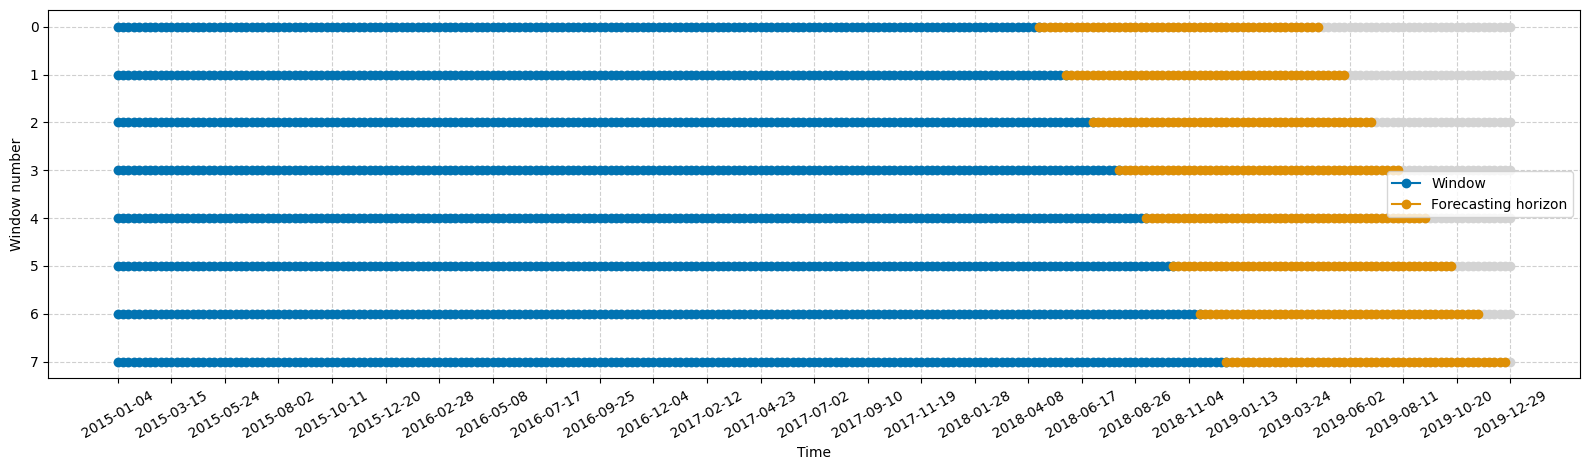

Number of Folds = 8


In [304]:
fh=np.arange(SEASON)
cv = ExpandingWindowSplitter(step_length=5, fh=fh,  initial_window = len(y_train) )
plot_windows(cv, y)
fix_plot(y)
n_splits = cv.get_n_splits(y)
print(f"Number of Folds = {n_splits}")

#### SlidingWindowSplitter

В целом стратегии спилата окон [могут быть и другими]( https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/backtesting.html).

На практике также стратегия сплита должны выбираться так, чтобы [соответствовать задаче](https://dl.leima.is/time-series/timeseries-evaluation.forecasting/). Например, в ряде случаев окно валидации должно опережать окно теста так, чтобы мы могли симулировать процесс в котором накопление данных значительно медленней появления новых данных. Или же например, в случае моделей глубокого обучения окно должно всегда быть фиксированного размера. Также  в некоторых случая - длинных ВР, отдельны интерес может представлять бектест для отдельных паттернов. В этом случае полезным будет использование нескольких стратегий спилат окна.


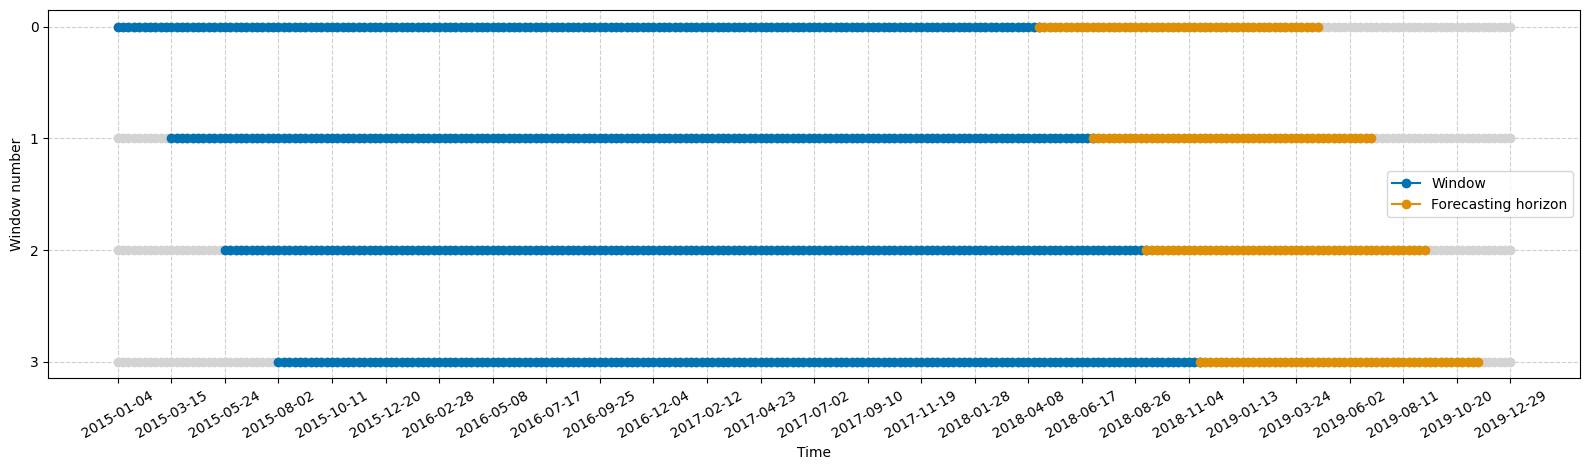

Number of Folds = 4


In [305]:
fh=np.arange(SEASON)
cv = SlidingWindowSplitter(step_length=10, fh=fh, window_length=len(y_train) )
plot_windows(cv, y)
fix_plot(y)
n_splits = cv.get_n_splits(y)
print(f"Number of Folds = {n_splits}")

#### Процедура evaluate

Провести [валидацию модели](https://www.sktime.net/en/latest/examples/01_forecasting.html) на можно при помощи метода [`evaluate`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.model_evaluation.evaluate.html). Обратите внимание тут в качестве входных данных мы используем только значения временного ряда, без указания их временного шага. Отметим, что в некоторых моделя это будет не корректно. В данном случае в качестве аргумента `cv` мы зададим сплитер, визуализированный выше. Также выбирем стратегию оценки `refit`. То есть каждый раз модель будет полностью переобучаться. Возможны также стратегии `update` и `no-update_params`.

In [306]:
forecaster =  NaiveForecaster(strategy='mean', sp=SEASON)

forecaster.fit(y_train)

cv = ExpandingWindowSplitter(step_length=5, fh=fh,  initial_window = len(y_train) )

In [307]:
df = evaluate(forecaster=forecaster, 
              y=y.values, 
              cv=cv, 
              strategy="refit", 
              return_data=True)
df.head(8)

,test_MeanAbsolutePercentageError,fit_time,pred_time,len_train_window,cutoff,y_train,y_test,y_pred
0,0.051098,0.000962,0.006652,173,172,0 0 38.517 1 41.048 2 42.46...,0 172 36.556 173 37.461 174 38.02...,0 172 37.113333 173 36.949000 1...
1,0.052488,0.001123,0.008458,178,177,0 0 38.517 1 41.048 2 42.46...,0 177 38.308 178 37.837 179 38.90...,0 177 35.829000 178 36.104000 1...
2,0.049678,0.001013,0.005102,183,182,0 0 38.517 1 41.048 2 42.46...,0 182 38.558 183 37.857 184 35.94...,0 182 36.775333 183 36.309333 1...
3,0.048643,0.000866,0.004964,188,187,0 0 38.517 1 41.048 2 42.46...,0 187 39.617 188 36.544 189 38.60...,0 187 36.400000 188 35.935667 1...
4,0.045020,0.000822,0.005275,193,192,0 0 38.517 1 41.048 2 42.46...,0 192 37.712 193 36.582 194 37.60...,0 192 36.372000 193 36.009667 1...
5,0.041635,0.001431,0.005235,198,197,0 0 38.517 1 41.048 2 42.46...,0 197 38.223 198 40.032 199 39.38...,0 197 36.813333 198 37.013667 1...
6,0.041437,0.000976,0.007239,203,202,0 0 38.517 1 41.048 2 42.46...,0 202 43.824 203 44.704 204 45.35...,0 202 40.988000 203 42.418333 2...
7,0.039856,0.000838,0.005283,208,207,0 0 38.517 1 41.048 2 42.46...,0 207 41.486 208 42.875 209 43.53...,0 207 43.769000 208 42.494667 2...


Из таблицы виден небольшой рост ошибки с увеличением шага валидации. 
Рекомендуется оценивать статистические характеристики прогноза перед его развертыванием в рабочем режиме. 
Также как и рекомендуется регулярно переоценивать характеристики в процессе работы. 
Для этого оценка может быть проведена по выбранным метрикам и с заданным периодом. Метрика может быть задана аргументом `scoring`.  

В примере ниже мы проведем такую оценку без повторного обучения модели. В качестве метрики зададим `MeanSquaredPercentageError`.

In [308]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanSquaredPercentageError

df = evaluate(forecaster=forecaster, 
              y=y.values, 
              cv=cv, 
              strategy="no-update_params", 
              return_data=True, 
              scoring=MeanSquaredPercentageError() )

df.iloc[:, :5].head(5)

,test_MeanSquaredPercentageError,fit_time,pred_time,len_train_window,cutoff
0,0.003656,0.001997,0.006509,173,172
1,0.003699,0.000827,0.005028,178,177
2,0.003362,0.001111,0.006189,183,182
3,0.003344,0.000886,0.005792,188,187
4,0.003002,0.000879,0.006335,193,192


#### evaluate со своими метриками

Отметим, что оценка может быть проведена по нескольким метрикам!

В примере ниже задана используемая нами кастомная метрика skill и стандартные метрики smape, rmse, mae

In [309]:
from sktime.performance_metrics.forecasting import make_forecasting_scorer

def skill_score_func(y_true, y_pred):
    y_true = y_true.squeeze()
    y_pred = y_pred.squeeze()
    y_pers = y_true.shift(1)
    y_pers.iloc[0] = y_true.iloc[0]
    valid = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_pers))
    if not valid.any():
        return np.nan
    mae_m = np.mean(np.abs((y_true[valid] - y_pred[valid])))
    mae_b = np.mean(np.abs((y_true[valid] - y_pers[valid])))
    return 1 - mae_m / (mae_b + 1e-12)

skill_scorer = make_forecasting_scorer(
    func=skill_score_func,
    name="skill_score",
    greater_is_better=True
)



In [310]:
from sktime.performance_metrics.forecasting import MeanSquaredError, MeanAbsoluteError

smape = MeanAbsolutePercentageError(symmetric=True)
rmse       = MeanSquaredError(square_root=True)
mae = MeanAbsoluteError()


# Добавляете в список скореров
scorers = [smape, rmse, mae, skill_scorer]

forecaster = forecaster.clone()
df = evaluate(forecaster, y=y, cv=cv, scoring=scorers, return_data=True)
df.iloc[:, :5].head(5)

,test_MeanAbsolutePercentageError,test_MeanSquaredError,test_MeanAbsoluteError,test_skill_score,fit_time
0,0.052040,2.485440,2.081270,-0.490579,0.041164
1,0.053514,2.536398,2.140149,-0.402301,0.005486
2,0.050579,2.465147,2.031797,-0.328890,0.001385
3,0.049480,2.444325,1.989687,-0.302280,0.001063
4,0.045672,2.341467,1.847329,-0.221900,0.001652


Процедура <tt>backtest</tt> важна при несмещенной оценке показателей модели. ТО есть при выборе лучших моделей для решения тех или иных задач. В этом смысле процедура сравнима (но не эквивалентна!) процедуре [`bagging`](https://otexts.com/fpp3/bootstrap.html).

Отметим также, что при помощи процедуры `backtest` может быть построена процедура автоматизированногог сравнения моделей предсказания [`benchmarking`](https://github.com/sktime/sktime/blob/main/examples/04_benchmarking_v2.ipynb).

Отметим также, что на практике [выбор метрики](https://unit8co.github.io/darts/generated_api/darts.metrics.metrics.html#) или [метрик](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) для сравнения ВР это не тривиальный вопрос. Метрики могут быть разделены [на несколько классов](https://dl.leima.is/time-series/timeseries-metrics.forecasting/) при этом каждая из [метрик](https://otexts.com/fpp3/accuracy.html) будует иметь свою [интерпретацию](https://www.mdsi.tum.de/fileadmin/w00cet/di-lab/pdf/Amazon_SS2022_Final_Report.pdf). 

>Также отметим, что более верной оценкой точности на прогнозе было бы использование т.н. [__динамического прогноза__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#dinamicheskij-prognoz). Т.е. такого, когда следующие значения предсказанной величины строятся на результатах предсказания ее предыдущих значений а не на исходных тестовых данных. В противовес этому тестирование на выборке исходных данных может быть названо [__статическим прогнозом__](https://timeweb.cloud/tutorials/python/prognozirovanie-vremennyh-ryadov-python-3#staticheskij-prognoz).

#### визуализация evaluate

В некоторых случаях также полезным может быть визуализация результатов оценки `evaluate`. Она может быть проведена следующим образом.

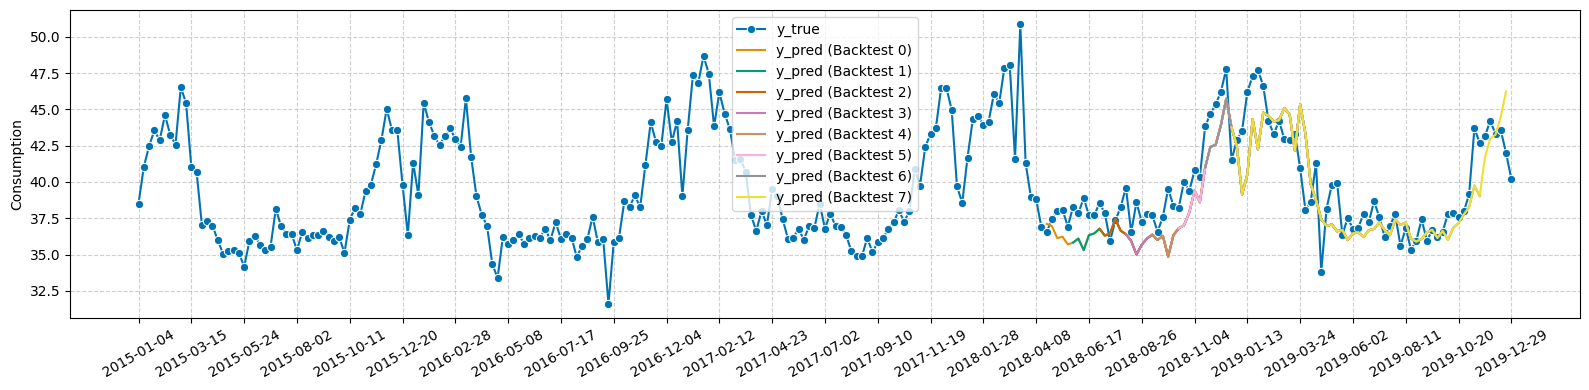

In [311]:
cv_len = len(df["y_pred"])

plot_series(
    y,
    *[df["y_pred"].iloc[i] for i in range(cv_len)],
     markers=["o"]+[""]*cv_len,
     labels=["y_true"] + ["y_pred (Backtest " + str(x) + ")" for x in range(cv_len)],
);fix_plot(y)

>Также важно указать, что помимо процедуры `backtesting` валидация моделей может быть проведена несколькими способами:
>1. Путем оценки/исследования остатков модели для предсказания ей тренировочного/валидационного набора данных.
>2. Путем оценки моделей при помощи информационных критериев. Этим методом можно пользоваться для параметрических методов. При этом используются мини-максные [информационные критерии](https://bookdown.org/mpfoley1973/time-series/regression.html), которые в том числе были рассмотрены в работе <tt>ARIMA</tt>. В общем случае критерии формулируются, например, как:
>$$AIC = N \log\left(\frac{SSE}{N}\right) + 2(k + 2),$$
>где $N$ - объем выборки, $SSE$ - сумма квадратов ошибок, $k$ - общее число параметров модели.

## Вероятностные предсказания

### Особенности вероятностного прогнозирования

Типичные реализации прогнозирования, которые мы рассматривали прежде [являются точечными](https://www.lokad.com/probabilistic-forecasting-definition/). То есть предсказывают одно значение для одного шага прогноза. Такое поведение модели явялется нормальным. Однако,  в ряде случаев помимо самого значения прогноза требуется знание каких то [статистческих характеристик прогноза](https://otexts.com/fpp3/prediction-intervals.html). В наиболее полном случае требуется знание распределения результатов прогноза для каждой точки. Такой прогноз [называется  вероятностным](https://www.lokad.com/tv/2022/3/2/probabilistic-forecasting-for-supply-chain/). 

Другими словами вероятностный прогноз содержит набор вероятностей, связанных со всеми возможными будущими исходами для каждой точки прогноза. В противовес этому точечный прогноз указывает на один конкретный исход в качестве "прогноза". 

Вероятностные прогнозы важны, когда неопределенность прогназирования значема и неустранима Факторы неопределнности прогноза почти всегда имеет место в сложных системах. Например, для цепочек поставок вероятностные прогнозы необходимы для принятия надежных решений в условиях неопределенности будущего. В частности, спрос и время выполнения заказа - два ключевых аспекта анализа цепочки поставок - лучше всего учитывать с помощью вероятностного прогнозирования. Вероятностная перспектива естественным образом способствует экономической приоритезации решений на основе их ожидаемой, но неопределенной отдачи. 

Важно отметить, что не все методы прогноза допускают вероятностное прогназирование. Более того для оценки точности вероятностного прогноза требуются специальные метрики, которые отличаются от детерминированных аналогов. А также для использования вероятностных прогнозов требуется специализированный инструментарий, отличающийся от детерминированных аналогов.

<!-- A forecast is said to be probabilistic, instead of deterministic, if it contains a set of probabilities associated with all possible future outcomes, instead of pinpointing one particular outcome as “the” forecast. Probabilistic forecasts are important whenever uncertainty is irreducible, which is nearly always the case whenever complex systems are concerned. For supply chains, probabilistic forecasts are essential to produce robust decisions against uncertain future conditions. In particular, demand and lead time, two key aspects of the supply chain analysis, are both best addressed via probabilistic forecasting. The probabilistic perspective lends itself naturally to the economic prioritization of the decisions based on their expected but uncertain returns. A large variety of statistical models deliver probabilistic forecasts. Some are structurally close to their deterministic counterparts while others are very different. Assessing the accuracy of a probabilistic forecast requires specific metrics, which differ from their deterministic counterparts. The exploitation of probabilistic forecasts requires specialized tooling that diverges from its deterministic counterparts. -->

И так, [Вероятностное прогнозирование обобщает](https://www.lokad.com/probabilistic-forecasting-definition/) то, что известно о будущих событиях, или мнения о них. В отличие от прогнозов с одним значением (point forecast) (например, прогнозов о том, что максимальная температура в данном месте в данный день составит 23 градуса Цельсия или что результатом данного футбольного матча будет безголевая ничья), вероятностные прогнозы присваивают вероятность каждому из нескольких различных исходов, а полный набор вероятностей представляет собой вероятностный прогноз (Probabilistic Forecasting). Другими словами в таким прогнозе мы предсказываем интервал значений, ассоциирующийся с неопределенностью предсказания (prediction intervals, Интервал прогнозирования - это диапазон значений, которые прогноз может принимать с заданной вероятностью. ). 
<!-- Probabilistic forecasting summarizes what is known about, or opinions about, future events. In contrast to single-valued forecasts (such as forecasting that the maximum temperature at a given site on a given day will be 23 degrees Celsius, or that the result in a given football match will be a no-score draw), probabilistic forecasts assign a probability to each of a number of different outcomes, and the complete set of probabilities represents a probability forecast. In other words, in such a prediction, we predict an interval of values associated with the prediction uncertainty 

 A prediction interval is a range of values that the forecast can take with a given probability.


В общем случае Результаты вероятностного прогнозирования [могут быть](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html): 
* интервалы - `predict_interval(fh=None, X=None, coverage=0.90)`
* квантили - `predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`
* диспрсия - `predict_var(fh=None, X=None, cov=False)`
* распределение - `predict_proba(fh=None, X=None, marginal=True)`

Примечания:
* у разных прогнозистов разные возможности! Также метрики, оценка и настройка различаются по "типу прогноза".
* Вероятностный прогноз может меняться от типасоставных шагов Пример: бутстрап

Заметим, $95\%$-ный интервал прогноза должен содержать диапазон значений, включающий фактическое будущее значение с вероятностью $95\%$. Тогда Вероятностное прогнозирование нацелено на получение полного прогнозного распределения. Точечное прогнозирование, с другой стороны, обычно возвращает среднее значение, медиану или другую точечную меру указанного распределения. Однако в реальных сценариях лучше прогнозировать не только наиболее вероятный будущий результат, но и множество альтернативных исходов.

<!-- 
In other words You can always train a forecasting model on historical data and predict a certain value, but this will never be more than a (hopefully) reasonable estimate. 

What is probabilistic forecasting? Intuition
* produce low/high scenarios of forecasts
* quantify uncertainty around forecasts
* produce expected range of variation of forecasts

Generally, probabilistic forecasting results could be : 
* forecast intervals - predict_interval(fh=None, X=None, coverage=0.90)
* forecast quantiles - predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])
* forecast variance - predict_var(fh=None, X=None, cov=False)
* distribution forecast - predict_proba(fh=None, X=None, marginal=True)

Notes:
* different forecasters have different capabilities! 
* Also metrics, evaluation & tuning are different by “type of forecast”.

Hence, a 95% prediction interval should contain a range of values that include the actual future value with probability 95%. Probabilistic forecasting aims to generate the full forecast distribution. Point forecasting, on the other hand, usually returns the mean or the median or said distribution. However, in real-world scenarios, it is better to forecast not only the most probable future outcome, but many alternative outcomes as well.
-->

<blockquote>
Формальный вид прогноза (эндогенный, одна временная метка прогноза):
* Пусть $y(t_1), \dots, y(t_n)$ - это наблюдения в фиксированные моменты времени $t_1, \dots, t_n$.
(мы рассматриваем $y$ как $\mathbb{R}^n$-значную случайную величину).
* Пусть $y'$ - это (истинное) значение, которое будет наблюдаться в будущий момент времени $\tau$.
(мы рассматриваем $y'$ как $\mathbb{R}$-значную случайную величину)

Более формальные детали и интуиция:

* __"точечный прогноз"__ - это предсказание/оценка условного ожидания $E[y'|y]$, где $y'$ - истинный результат. Интуиция: "из множества повторений/разных попыток предсказания - результат значение средним арифметическим значением".

* __"дисперсионный прогноз"__ (`predict_var(fh=None, X=None, cov=False)`) - это предсказание/оценка условного ожидания дисперсии $Var[y'|y]$. Интуиция: "из множества повторений - это значение является средним квадратичным расстоянием от наблюдения до идеального точечного прогноза".

* __"квантильный прогноз"__(`predict_quantiles(fh=None, X=None, alpha=[0.05, 0.95])`), в точке квантиля $\alpha \in (0,1)$ - это предсказание/оценка $\alpha$-квантиля $y'|y$, т.е. $F^{-1}_{y'|y}(\alpha)$, где $F^{-1}$  это (обобщенная) обратная `CDF` = квантильная функция случайной величины $y'|y$. Интуиция: "Из множества повторений вероятность появления данного будет равна или меньше  значения $\alpha$".
 
* __"Интервальный прогноз"__ или __"интервал предсказания"__ (`predict_interval(fh=None, X=None, coverage=0.90)`) с (симметричным) охватом $c \in (0,1)$ - это пара прогноз/оценка с нижней границей $a$ и верхней границей $b$, такая, что $P(\alpha \le y' \ge b|y)=c$ и $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Интуиция: "Из множества повторений результат будет содержаться в интервале $[a,b]$  с вероятностью $c$. Причем вероятность того, что будут результаты выше равна вероятности того, что  будут результаты ниже".

* __"прогноз распределения"__ или __"полный вероятностный прогноз"__ (`predict_proba(fh=None, X=None, marginal=True)`)- это предсказание/оценка распределения $y'|y$ например, "это нормальное распределение со средним 42 и дисперсией 1". Интуиция: исчерпывающее описание механизма порождения множества повторений.

<!-- Примечания:
* _нижняя/верхняя часть интервальных прогнозов_ - это квантильные прогнозы в точках квантилей $0,5 - c/2$ и $0,5 + c/2$ (при условии, что распределения прогнозов абсолютно непрерывны).
* все остальные прогнозы могут быть получены из полного вероятностного прогноза; полный вероятностный прогноз может быть получен из всех квантильных или всех интервальных прогнозов.
* не существует точной зависимости между другими типами прогнозов (точечный или дисперсионный vs квантильный)
* в частности, точечный прогноз не обязательно должен быть медианным прогнозом aka 0,5-квантильным прогнозом. Это может быть 
$\alpha$-quantile для любого $\alpha$! -->
<!-- 
Частая путаница в литературе и пакетах python: * охват 'c' vs квантиль '\alpha' * охват 'c' vs значимость 'p = 1-c' * квантиль нижней границы интервала, 'p/2', vs 'p' * интервальные прогнозы vs связанные, но существенно разные понятия: доверительный интервал для прогнозируемого среднего; байесовский апостериор или интервал доверия для прогнозируемого среднего * все прогнозы выше могут быть байесовскими, путаница: "апостериоры разные" или "должны оцениваться по-разному". -->



<!-- Formal view (endogeneous, one forecast time stamp):

Let $y(t_1), \dots, y(t_n)$ be observations at fixed time stamps $t_1, \dots, t_n$.

(we consider $y$ as an $\mathbb{R}^n$-valued random variable)

Let $y'$ be a (true) value, which will be observed at a future time stamp $\tau$.

(we consider $y'$ as an $\mathbb{R}$-valued random variable)

More formal details & intuition:
* a “point forecast” is a prediction/estimate of the conditional expectation $E[y'|y]$ where $y'$ is a true result.
. Intuition: “out of many repetitions/differnt attempts to forecast, this value is the arithmetic average of all observations”.
* a “variance forecast” ('predict_var(fh=None, X=None, cov=False)')  is a prediction/estimate of the conditional expectation $Var[y'|y]$ 
. Intuition: “out of many repetitions/worlds, this value is the average squared distance of the observation to the perfect point forecast”.
* a “quantile forecast”, at quantile point  $\alpha \in (0,1)$ is a prediction/estimate of the 
$\alpha$-quantile of $y'|y$, i.e., of $F^{-1}_{y'|y}(\alpha)$, where $F^{-1}$
 is the (generalized) inverse cdf = quantile function of the random variable $y'|y$. 
 Intuition: “out of many repetitions/worlds, a fraction of exactly 
 will have equal or smaller than this value.”
* an “interval forecast” or “predictive interval” with (symmetric) coverage $c \in (0,1)$ is a prediction/estimate pair of lower bound $a$ and upper bound 
$b$ such that $P(\alpha \le y' \ge b|y)=c$
and $P(y'>b|y)=P(y<a|y)=(1-c)/2$. Intuition: “out of many repetitions/worlds, a fraction of exactly $c$
will be contained in the interval $[a,b]$, and being above is equally likely as being below”.
* a “distribution forecast” or “full probabilistic forecast” is a prediction/estimate of the distribution of $y'|y$
, e.g., “it’s a normal distribution with mean 42 and variance 1”. Intuition: exhaustive description of the generating mechanism of many repetitions/worlds.

Notes:

* lower/upper of interval forecasts are quantile forecasts at quantile points  $0.5 - c/2$
 and $0.5 + c/2$
 (as long as forecast distributions are absolutely continuous).
* all other forecasts can be obtained from a full probabilistic forecasts; a full probabilistic forecast can be obtained from all quantile forecasts or all interval forecasts.
* there is no exact relation between the other types of forecasts (point or variance vs quantile)
* in particular, point forecast does not need to be median forecast aka 0.5-quantile forecast. Can be 
$\alpha$-quantile for any $\alpha$!

Frequent confusion in literature & python packages: * coverage 'c' vs quantile '\alpha' * coverage 'c' vs significance 'p = 1-c' * quantile of lower interval bound, 'p/2', vs 'p' * interval forecasts vs related, but substantially different concepts: confidence interval on predictive mean; Bayesian posterior or credibility interval of the predictive mean * all forecasts above can be Bayesian, confusion: “posteriors are different” or “have to be evaluted differently”

 -->



<!-- **Пусть** создается "распределение" или "диапазон" прогнозных значений,
в моменты времени, определяемые **горизонтом прогнозирования** `fh`

* заданные **прошлые данные** `y` (серия) и, возможно, экзогенные данные `X`, для `подгонки` или `прогнозирования`: `fh`, `y`, `X`.
Выходные данные из `predict_probabilistic`: некоторый объект "распределения" или "диапазона"

**Большое предостережение**: существует множество возможных способов моделирования "распределения" или "диапазона"!
Используется на практике и легко путается! (и часто, практически, путают!)
 -->
<!-- 
**Let**  produce "distribution" or "range" of forecast values,
at time stamps defined by **forecasting horizon** `fh`

* given **past data** `y` (series), and possibly exogeneous data `X`, to `fit` or `predict`: `fh`, `y`, `X`
Output, from `predict_probabilistic`: some "distribution" or "range" object

**Big caveat**: there are multiple possible ways to model "distribution" or "range"!
Used in practice and easily confused! (and often, practically, confused!) -->

Одним из важных свойств вероятностного предсказания является возможность введения [дополнительных метрик](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#overview---theory), позволяющих корректировать прогноз.

Мы ожидаем, что прогнозируемое `y` имеет форму, отличную от истинного `y`, поэтому метрики имеют вид

`metric(y_true: series, y_pred: proba_prediction) -> float`.

где `proba_prediction` - тип конкретного "типа вероятностного предсказания".

Т.е. мы имеем следующую [таблицу](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#Formal-view-(endogeneous,-one-forecast-time-stamp)) функции для потери/метрики $L$:

<!-- | Name                  |  prediction/estimate of                   | general form |
| ----                  | ----------------------                    | -------- |
| точечный прогноз      | условное ожидание $\mathbb{E}[y'\|y]$     | `metric(y_true, y_pred)` | 
| Прогноз дисперсии     | условной дисперсии $Var[y'\|y]$           | `metric(y_pred, y_pt, y_var)` (требует точечного прогноза)     |
| квантильный прогноз   | $\alpha\in (0,1)$;  $\alpha$- квантиль от $y'\|y$  | `metric(y_true, y_quantiles, alpha)` | 
| интервальный прогноз  |  $c\in (0,1) \ for \ [a,b] \ P(a\le y' \le b \| y) = c$    |`metric(y_true, y_interval, c)` | 
| Прогноз распределения | закона/распределения $y'\|y$                       | `metric(y_true, y_distribution)` |
 -->
 
 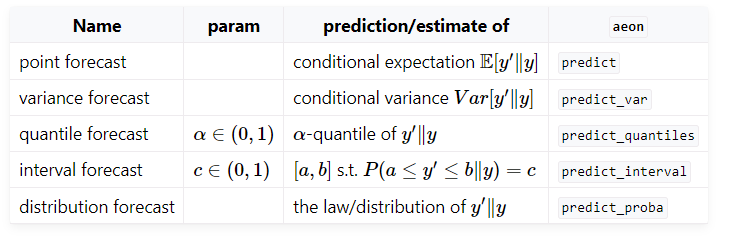
<!-- #### overview - theory

Predicted `y` has different form from true `y`, so metrics have form

`metric(y_true: series, y_pred: proba_prediction) -> float`

where `proba_prediction` is the type of the specific "probabilistic prediction type".

I.e., we have the following function signature for a loss/metric $L$:

| Name | param | prediction/estimate of | general form |
| ---- | ----- | ---------------------- | -------- |
| point forecast | | conditional expectation $\mathbb{E}[y'\|y]$ | `metric(y_true, y_pred)` |
| variance forecast | | conditional variance $Var[y'\|y]$ | `metric(y_pred, y_pt, y_var)` (requires point forecast too) |
| quantile forecast | $\alpha\in (0,1)$ | $\alpha$-quantile of $y'\|y$ | `metric(y_true, y_quantiles, alpha)` |
| interval forecast | $c\in (0,1)$| $[a,b]$ s.t. $P(a\le y' \le b\| y) = c$ | `metric(y_true, y_interval, c)` |
| distribution forecast | | the law/distribution of $y'\|y$ | `metric(y_true, y_distribution)` | -->


Технически существует [множество способов](https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html) оценки интервалов прогнозирования. Способы можно разделить на специфические для моделей (например оценка дисперсии предсказывается в процессе оценки коэффициентов [<tt>ARIMA</tt>](https://otexts.com/fpp2/arima-forecasting.html#prediction-intervals-3) или [для наивных предсказаний](https://otexts.com/fpp2/prediction-intervals.html#benchmark-methods)) и т.н. независимые от модели способы. Важно понимать что большинство способов требуют, чтобы остатки (ошибки) модели следовали [нормальному распределению](https://otexts.com/fpp3/prediction-intervals.html). 
Когда это свойство не предполагается, обычно используются несколько альтернатив: 
* Интервалы прогнозирования на основе бутстрепных остатков и [рекурсивно-многошагового прогноза](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
<img src="https://skforecast.org/0.5.0/img/diagram-recursive-mutistep-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирования на основе квантильной регрессии и [прямого многошагового прогноза](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html).
<img src="https://skforecast.org/0.5.0/img/diagram-direct-multi-step-forecasting.png" alt="" style="width:500px;">
* Интервалы прогнозирование с использованием техники [bootstrap](https://skforecast.org/0.5.0/user_guides/prediction-intervals). При этом на каждой точке горизонта вычисляются значения нужных процентилей (квантилей).
<img src="https://skforecast.org/0.5.0/img/diagram-bootstrapping-prediction-intervals.png" style="width:500px;">
* С использованием квантильной регресии (оценка интервалов).
* Методы т.н. [конформного предсказация](https://algotrading101.com/learn/conformal-prediction-guide/). В методе предлагается задаться оценкой разрброса и определить число предсказаний, которые туда попадают.

>[Интересно также отметить](https://robjhyndman.com/hyndsight/narrow-pi/), что  почти все интервалы прогнозирования слишком узкие. Например, номинальные 95 %-ные интервалы могут обеспечивать охват только от 71 до 87 % возможных значений прогнозов. Это хорошо известное явление, которое возникает потому, что модель распределения не учитывают все источники неопределенности. В моделях прогнозирования существует как минимум четыре источника неопределенности:
> * случайный член ошибки
> * Оценки параметров
> * Выбор модели для исторических данных
> * Продолжение процесса генерирования исторических данных в будущем.
>
> При построении интервалов прогнозирования для моделей временных рядов обычно учитывается только первый из этих источников. Поэтому целесообразно использовать тестовые данные для проверки эмпирического покрытия интервала, а не полагаться только на ожидаемое значение.

<!-- Let us note that technuically there are multiple ways to estimate prediction intervals, most of which require that the residuals (errors) of the model follow a normal distribution. When this property cannot be assumed, two alternatives commonly used are 
* Prediction intervals based on bootstrapped residuals and [recursive-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/autoregresive-forecaster.html).
* Prediction intervals based on quantile regression and [direct-multi-step forecaster](https://skforecast.org/0.5.0/user_guides/direct-multi-step-forecasting.html). https://cienciadedatos.net/documentos/py42-forecasting-prediction-intervals-machine-learning.html

Interesting to note that 
in real-world problems, almost all prediction intervals are too narrow. For example, nominal 95% intervals may only provide coverage between 71% and 87%. This is a well-known phenomenon and arises because they do not account for all sources of uncertainty. With forecasting models, there are at least four sources of uncertainty:
The random error term
The parameter estimates
The choice of model for the historical data
The continuation of the historical data generating process into the future
When producing prediction intervals for time series models, generally only the first of these sources is taken into account. Therefore, it is advisable to use test data to validate the empirical coverage of the interval and not only rely on the expected one.
https://robjhyndman.com/hyndsight/narrow-pi/-->


Отметим еще раз важность прогнозирования интервалов предсказания [(доверительных интервалов) во временных рядах](https://nixtlaverse.nixtla.io/mlforecast/docs/tutorials/prediction_intervals_in_forecasting_models.html#importance-of-confidence-interval-prediction-in-time-series):
* __Оценка неопределенности__: Доверительный интервал обеспечивает меру неопределенности, связанной с прогнозами временных рядов. Он позволяет количественно оценить изменчивость и диапазон разборса возможных будущих значений, что очень важно для принятия обоснованных решений.
* __Оценка точности__: Имея доверительный интервал, можно оценить надежность прогнозов. Если интервал узкий, это говорит о том, что прогноз более точный и надежный. С другой стороны, если интервал широкий, это указывает на большую неопределенность и меньшую точность прогноза.
* __Управление рисками__: Доверительный интервал помогает в управлении рисками, предоставляя информацию о возможных сценариях будущего. Он позволяет определить диапазоны, в которых могут находиться реальные значения, и принимать решения на основе этих возможных сценариев.
* __Эффективная коммуникация__: Доверительный интервал - полезный инструмент для четкой и точной передачи прогнозов. Он позволяет донести до заинтересованных сторон изменчивость и неопределенность, связанную с прогнозами, избегая неправильной или слишком оптимистичной интерпретации результатов.

Поэтому прогнозирование доверительных интервалов во временных рядах необходимо для понимания и управления неопределенностью, оценки точности прогнозов и принятия обоснованных решений на основе возможных сценариев будущего.

>Большинство моделей временных рядов генерируют прогнозы, которые следуют нормальному распределению, что подразумевает, что мы предполагаем, что возможные будущие значения следуют нормальному распределению. Однако, реальное распределение не всегда такое.

### Примеры использования вероятностного прогноза 

#### Покрытие интервала predict_interval

Как уже было замечено вероятностное прогназирование часто используется для двух процедур:
* [процедура `backtest`](https://joaquinamatrodrigo.github.io/skforecast/0.8.1/user_guides/backtesting.html) в качестве допонительной меры отбора моделей и настройки их параметров.
* [допонительные метрики](https://auto.gluon.ai/stable/tutorials/timeseries/forecasting-metrics.html) оценки для будущих значений при настройки моделей. В том числе как мера оценки [интервала разброса значений оценки](https://otexts.com/fpp3/prediction-intervals.html). Такие метрики могут помочь и дополнить процедуру evaluation. Каждая из метрик будет иметь [свою интерпретацию](https://otexts.com/fpp3/distaccuracy.html).

**Давайте посмотрим примеры.**



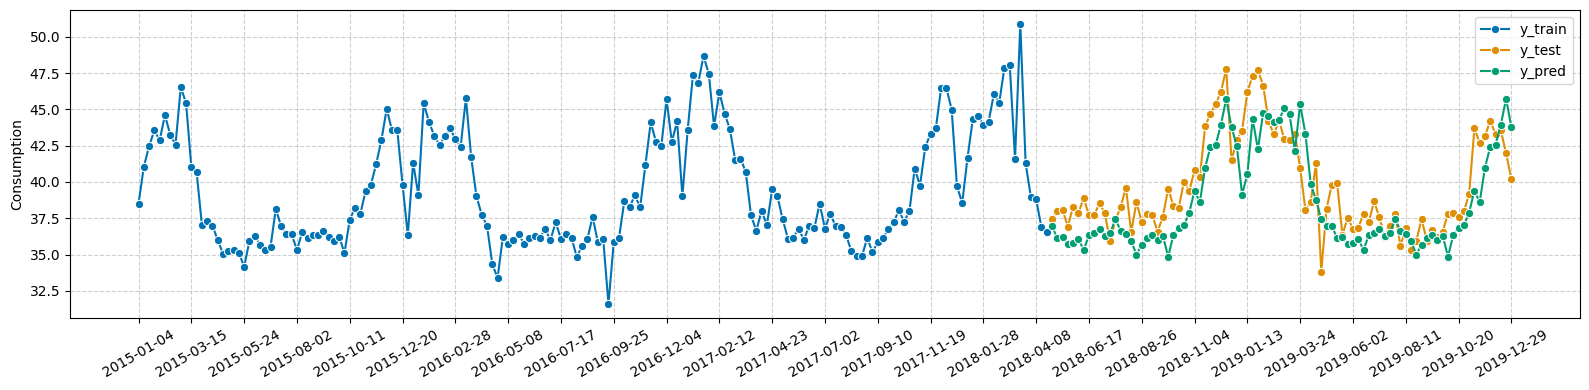

In [312]:
fh = ForecastingHorizon(y_test.index, is_relative=False)
forecaster = NaiveForecaster(strategy="mean", sp = SEASON)
forecaster.fit(y_train)
y_pred = forecaster.predict(fh=fh)

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
fix_plot(y)
 

Для начала рассмотрим случай наивного предсказания интервала покрытия предсказания [predict_interval](https://www.sktime.net/en/stable/examples/01b_forecasting_proba.html#Probabilistic-forecasting-interfaces-in-sktime)
Входы:
`fh` - горизонт прогнозирования (не обязательно, если рассматривается в подгонке модели)
покрытие (`coverage`) -> float (или список float), по умолчанию=0.9 ( это  номинальный охват(ы) интервала(ов) прогнозирования)
Выходные данные: `pandas.DataFrame` c двумя колонками (нижняя и верхняя грани интервала)

Отметим что покрытие может быть списком, вида например `coverage = [ 0.5, 0.75, 0.9]` где каждое значение означает свой номинальный уровень в терминах квантилей.

<!-- Inputs:
fh - forecasting horizon (not necessary if seen in fit)
coverage, float or list of floats, default=0.9
nominal coverage(s) of the prediction interval(s) queried
Output: pandas.DataFrame
Row index is fh
Column has multi-index:
3rd level = string “lower” or “upper”
Entries = forecasts of lower/upper interval at nominal coverage in 2nd lvl, for var in 1st lvl, for time in row  -->

In [313]:
coverage = 0.99
y_pred_ints = forecaster.predict_interval(coverage=coverage)
y_pred_ints.head(3  )

Consumption           
                  0.99           
                 lower      upper
2018-04-29   22.807994  51.090006
2018-05-06   21.990994  50.273006
2018-05-13   22.089660  50.371673

Посмотрим как это визуализируется

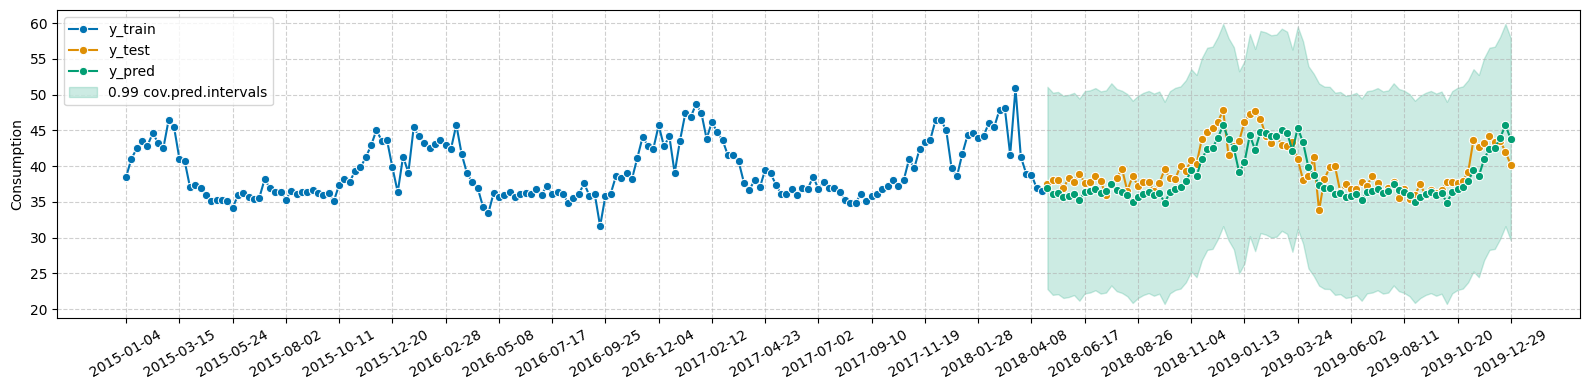

In [314]:
y_pred = forecaster.predict(fh)

fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

ax.fill_between(
    ax.get_lines()[-1].get_xdata(),
    y_pred_ints["Consumption"][coverage]["lower"],
    y_pred_ints["Consumption"][coverage]["upper"],
    alpha=0.2,
    color=ax.get_lines()[-1].get_c(),
    label=f"{coverage} cov.pred.intervals",
)
ax.legend(); fix_plot(y)


Отметим, что отдельные квантили могут быть расчитаны, если покрытие задано списком.

In [315]:
coverage = [0.5, 0.9, 0.95]
y_pred_ints = forecaster.predict_interval(coverage=coverage)
y_pred_ints.head(3)

Consumption                                                       
                  0.50                  0.90                  0.95           
                 lower      upper      lower      upper      lower      upper
2018-04-29   33.246129  40.651871  27.918943  45.979057  26.189023  47.708977
2018-05-06   32.429129  39.834871  27.101943  45.162057  25.372023  46.891977
2018-05-13   32.527796  39.933538  27.200610  45.260724  25.470690  46.990643

#### Предсказание для квантилей predict_quantiles

также посмотрим на квантили сходимости по заданым квантиляем

In [316]:
alpha = [0.1, 0.5,   0.9]
y_pred_quantiles = forecaster.predict_quantiles(alpha=alpha)
y_pred_quantiles.head(3)

Consumption                      
                   0.1        0.5        0.9
2018-04-29   29.913429  36.949000  43.984571
2018-05-06   29.096429  36.132000  43.167571
2018-05-13   29.195096  36.230667  43.266237

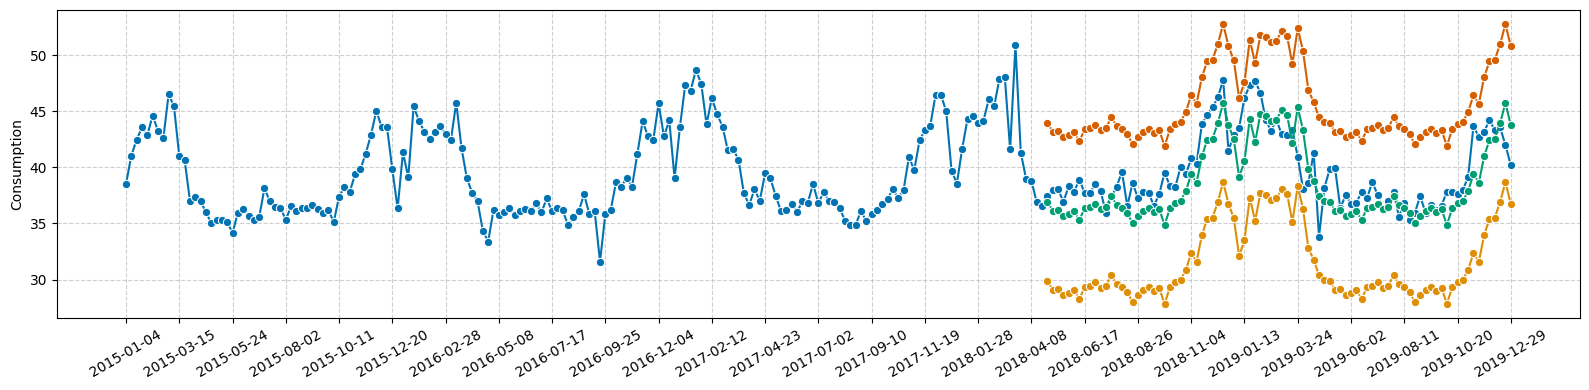

In [317]:
_, columns = zip(*y_pred_quantiles.items())
fig, ax = plot_series(y, *columns)
fix_plot(y)

#### Предсказание дисперсии predict_var

Аналогична может быть произведена оценка дисперсии предсказаний

In [318]:
y_pred_variance = forecaster.predict_var()
y_pred_variance.head(3)

,0
2018-04-29,30.138836
2018-05-06,30.138836
2018-05-13,30.138836


Построим оценку

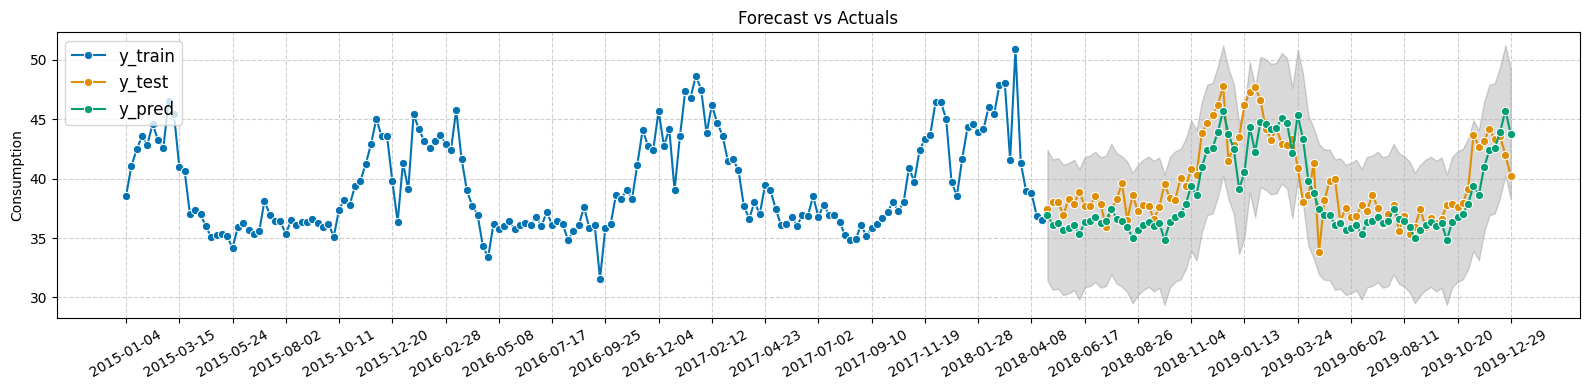

In [319]:
lower_series = pd.Series(y_pred.values.squeeze() - np.sqrt(y_pred_variance.values.squeeze()), index=y_test.index)
upper_series = pd.Series(y_pred.values.squeeze() + np.sqrt(y_pred_variance.values.squeeze()), index=y_test.index)

fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series.values, 
             upper_series.values, 
             color='k', 
             alpha=0.15)

plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=12)
fix_plot(y)
plt.show()


#### Сравним покрытие для двух предсказаний визуально

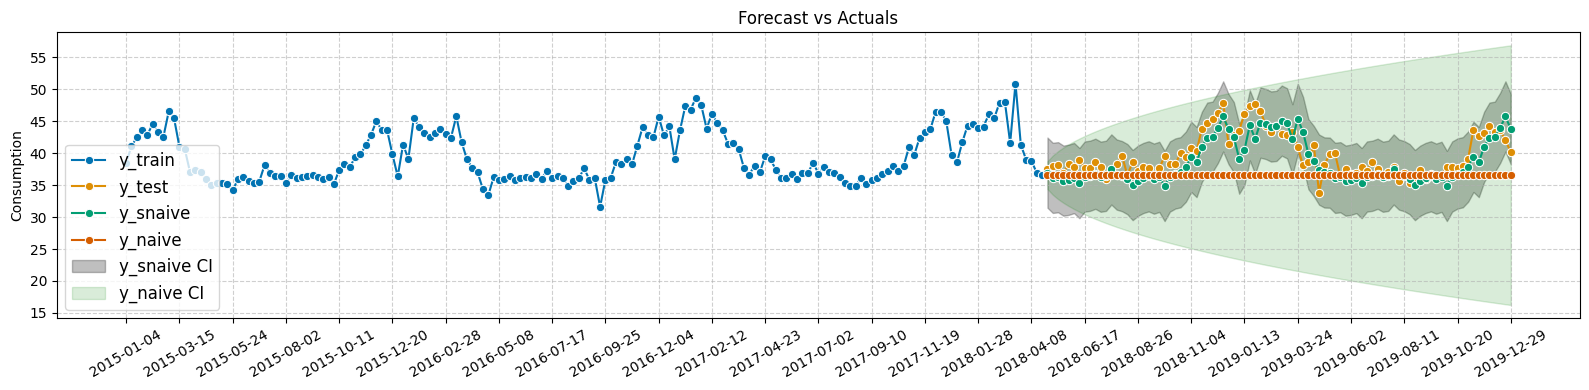

In [428]:
from matplotlib.patches import Patch

forecaster1 = NaiveForecaster(strategy="mean", sp = SEASON)
forecaster2 = NaiveForecaster(strategy="last", )
forecaster1.fit(y_train)
forecaster2.fit(y_train)
y_pred1 = forecaster1.predict(fh=fh)
y_pred_variance1 = forecaster1.predict_var()
lower_series1 = pd.Series(y_pred1.values.squeeze() - np.sqrt(y_pred_variance1.values.squeeze()), index=y_test.index)
upper_series1 = pd.Series(y_pred1.values.squeeze() + np.sqrt(y_pred_variance1.values.squeeze()), index=y_test.index)
y_pred2 = forecaster2.predict(fh=fh)
y_pred_variance2 = forecaster2.predict_var()
lower_series2 = pd.Series(y_pred2.values.squeeze() - np.sqrt(y_pred_variance2.values.squeeze()), index=y_test.index)
upper_series2 = pd.Series(y_pred2.values.squeeze() + np.sqrt(y_pred_variance2.values.squeeze()), index=y_test.index)

fig, ax = plot_series(y_train, y_test, y_pred1,y_pred2, labels=["y_train", "y_test", "y_snaive", "y_naive"])

ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series1.values, 
             upper_series1.values, 
             color='k', 
             alpha=0.25)

ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series2.values, 
             upper_series2.values, 
             color='g', 
             alpha=0.15)

# Получаем текущие хэндлы и метки от plot_series
handles, labels = ax.get_legend_handles_labels()

# Добавляем "прокси"-патчи для легенды заполнений
proxy_fill1 = Patch(color='k', alpha=0.25, label='y_snaive CI')
proxy_fill2 = Patch(color='g', alpha=0.15, label='y_naive CI')

# Объединяем: сначала линии, потом заполнения (или наоборот — как хотите)
all_handles = handles + [proxy_fill1, proxy_fill2]
all_labels = labels + ['y_snaive CI', 'y_naive CI']

# Обновляем легенду
ax.legend(handles=all_handles, labels=all_labels, loc='best', fontsize=12)

plt.title('Forecast vs Actuals')
fix_plot(y)  # предполагается, что это ваша функция
plt.show()

### Мера вероятностного прогнозирования

#### pinball loss

Рассмотрим квантильный прогноз (`pred_quantiles`). <br>
формально, 
- квантильный прогноз $\widehat{y}_j(t_i)$, - это прогнозы для квантиля $\alpha_j$, в диапазоне $i=1\dots N, j=1\dots k$;
- $\alpha_j$ - квантили `alpha`, 
- $t_i$ - будущие метки, индексируемые в `fh`.
<!-- Let's Generating some quantile predictions.
`pred_quantiles` now contains quantile forecasts\
formally, forecasts $\widehat{y}_j(t_i)$ where $\widehat{y_j}$ are forecasts at quantile $\alpha_j$, with range $i=1\dots N, j=1\dots k$\
$\alpha_j$ are the elements of `alpha`, and $t_i$ are the future time stamps indexed by `fh` -->

In [321]:
forecaster.fit(y_train, fh=fh)
pred_quantiles = forecaster.predict_quantiles(alpha=[0.1, 0.25, 0.5, 0.75, 0.9])
pred_quantiles.head(2)

Consumption                                         
                  0.10       0.25    0.50       0.75       0.90
2018-04-29   29.913429  33.246129  36.949  40.651871  43.984571
2018-05-06   29.096429  32.429129  36.132  39.834871  43.167571

При оценках квантилей возникает вопрос о том, как 
- использовать значения  квантилей для сравнения моделей предсказания между собой
- как выбрать модель, правильно [предсказывающую квантиль](https://arxiv.org/pdf/2211.02989.pdf)).

>В отличие от точечных прогнозов (MAE, RMSE), квантильный прогноз намеренно смещён.
>
>Например, 0.9-квантиль не должен быть близок к среднему значению — он должен быть выше большинства наблюдений.

Точечные  метрики ошибок здесь неподходят.

ля оценки качества квантильных прогнозов используют  [квантильную функцию потерь](https://github.com/aryan-jadon/Regression-Loss-Functions-in-Time-Series-Forecasting-PyTorch) ([quantiles loss](https://www.lokad.com/quantile-regression-time-series-definition/) - `pinball loss`.


Для значения квантиля $\alpha \in (0,1) $ мера [<tt>pinball loss</tt>](https://www.lokad.com/pinball-loss-function-definition/)  

$$L_{\alpha}(\widehat{y}_{\alpha}, y) := \begin{cases} \alpha \cdot \Theta (y - \widehat{y}_{\alpha})\text{, if } y\ge \widehat{y}_{\alpha} \\ (1-\alpha) \cdot \Theta (\widehat{y}_{\alpha} - y) \text{, otherwise }\end{cases}$$

или

$$L_{\alpha}(\widehat{y}_{\alpha}, y) := \alpha \cdot \Theta (y - \widehat{y}_{\alpha}) + (1-\alpha) \cdot \Theta (\widehat{y}_{\alpha} - y)$$

где 
- $\Theta (x) := \begin{cases}1 \text{, if } x\ge 0 \\ 0 \text{, otherwise }\end{cases}$ - функция Хевисайда.
- $y$ — наблюдаемое значение,
- $\hat{y}_{\alpha}$  — прогноз квантиля уровня $\alpha \in (0,1) $.
  
Вид  <tt>pinball loss</tt>       
<img src='https://www.lokad.com/images/learn/pinball-loss-function_hu_179f4609b474327e.webp' style="width:300px;">   
 
__Важно понимать__, что <tt>pinball loss</tt> - это не метрика, Абсолютные значения не так важны, как сравнение моделей!

__Pinball loss__ штрафует асимметрично:
- если модель недооценила квантиль ($y>\hat{y}_{\alpha}$ ), штраф пропорционален ${\alpha}$;
- если модель переоценила квантиль ($y<\hat{y}_{\alpha}$ ), штраф пропорционален ${1-\alpha}$.
- Минимум математического ожидания pinball loss достигается на истинном ${\alpha}$ - квантиле распределения.
- меньший pinball loss - более точный квантильный прогноз.
- pinball loss косвенно отражает калибровку модели (если квантиль 0.9 часто оказывается ниже наблюдений - высокая потеря. 

Пример: для $\alpha=0.9$ модель сильно наказывается за недооценку, но слабо — за переоценку.<br>
Это ровно соответствует смыслу $90$-го квантиля:
истинное значение должно быть ниже прогноза примерно в $90\%$ случаев.


>Заметим, что оценка точности квантильного прогноза - сложная задача. Действительно, в отличие от классических прогнозов, где цель состоит в том, чтобы прогноз был как можно ближе к наблюдаемым значениям, в квантильных прогнозах ситуация смещена (намеренно). Поэтому наивное сравнение наблюдаемых и прогнозируемых значений не приносит эффекта. В тоже время функция потерь `pinball loss` возвращает значение, которое можно интерпретировать как [точность квантильной модели прогнозирования](https://www.lokad.com/pinball-loss-function-definition/).
>
>Функция `pinball loss` всегда положительна, и чем дальше от цели тем больше ее значение. Наклон функции  используется как параметр для отражения желаемого дисбаланса в квантильном прогнозе.Наиболее важный результат, связанный с функцией потерь пинбол, заключается в том, что чем меньше потери пинбола, тем точнее квантильный прогноз. В ряде случаев можно считать, что функция потерь является индекаторм отсуствия переобучения у модели. Кроме того функция может быть использовна непосредственно как метрика, позволяя сравнить несколько [моделей между собой](https://www.lokad.com/tv/2022/1/5/no1-at-the-sku-level-in-the-m5-forecasting-competition/).
>
> Отметим, что функция `pinball loss` не единственная метрика для сравнения [вероятностных прогнозов моделей](https://www.lokad.com/continuous-ranked-probability-score/), есть и лругие популярные решния, например [ранговый вероятностный скор (CSRP)](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.performance_metrics.forecasting.probabilistic.CRPS.html)
<!-- The function is always positive and the further away from the target 
, the larger the value of 
. The slope is used to reflect the desired imbalance in the quantile forecast.
The most important result associated with the pinball loss function is that the lower the pinball loss, the more accurate the quantile forecast. -->

<!-- Evaluating the accuracy of a quantile forecast is a subtle problem. Indeed, contrary to the classic forecasts where the goal is to have the forecast as close as possible from the observed values, the situation is biased (on purpose) when it comes to quantile forecasts. Hence the naive comparison observed vs forecasts is not satisfying. The pinball loss function returns a value that can be interpreted as the accuracy of a quantile forecasting model.https://www.lokad.com/pinball-loss-function-definition/ -->

<!-- It can be seen that pinball loss differs depending on the evaluated quantile. The higher the quantile, the more the loss function penalizes underestimates, and the less it penalizes overestimates. As with MSE and MAE, the goal is to minimize its values (the lower loss, the better).

Two disadvantages of quantile regression, compared to the bootstrap approach to prediction intervals, are that each quantile needs its regressor and quantile regression is not available for all types of regression models. However, once the models are trained, the inference is much faster since no iterative process is needed.

This type of prediction intervals can be easily estimated using ForecasterAutoregDirect models. -->

<!-- Возможны следцующие модификации [`pinball loss`](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#metrics:-general-signature-and-averaging):

* *множественный квантильный прогноз* $\widehat{\bf y}:=\widehat{y}_1, \dots, \widehat{y}_k$ для квантилей ${\bf \alpha} = \alpha_1,\dots, \alpha_k$ 
$$L_{{\bf \alpha}}(\widehat{\bf y}, y) := \frac{1}{k}\sum_{i=1}^k L_{\alpha_i}(\widehat{y}_i, y)$$
* *интервальныq прогноз* $[\widehat{a}, \widehat{b}]$ при симметричной сходимости $c$   
$$L_c([\widehat{a},\widehat{b}], y) := \frac{1}{2} L_{\alpha_{low}}(\widehat{a}, y) + \frac{1}{2}L_{\alpha_{high}}(\widehat{b}, y)$$ где $\alpha_{low} = \frac{1-c}{2}, \alpha_{high} = \frac{1+c}{2}$.

При усредненнии значений функции потерь допустимы следующие варианты:
* значения квантилей, если их несколько - элементы `alpha` в `predict_interval(fh, alpha)`
* временные метки в горизонте прогнозирования `fh` - элементы `fh` в `fit(fh)`  `predict_interval(fh, alpha)`
* переменные `y`, в случае многомерного прогноз (сейчас мы рассмотриваем одномерный случай). -->

<!-- Сначала мы покажем значения квантилей и временные метки:
1. усреднение только по временным меткам `fh` -> одно число на значение квантиля в `alpha`
2. усреднение по ничему -> одно число на значение квантиля в `alpha` и временной метке `fh`
3. усреднение и по `fh`, и по квантильным значениям в `alpha` -> одно число
 -->

<!-- Let view the example of the quantile loss aka interval loss aka pinball loss, in the univariate case.

For one quantile value $\alpha$, the (per-sample) pinball loss function is defined as\
$L_{\alpha}(\widehat{y}, y) := \alpha \cdot \Theta (y - \widehat{y}) + (1-\alpha) \cdot \Theta (\widehat{y} - y)$,\
where $\Theta (x) := [1$ if $x\ge 0$ and $0$ otherwise $]$ is the Heaviside function.

This can be used to evaluate:

* *multiple quantile* forecasts $\widehat{\bf y}:=\widehat{y}_1, \dots, \widehat{y}_k$ for quantiles ${\bf \alpha} = \alpha_1,\dots, \alpha_k$ via\
$L_{{\bf \alpha}}(\widehat{\bf y}, y) := \frac{1}{k}\sum_{i=1}^k L_{\alpha_i}(\widehat{y}_i, y)$
* *interval forecasts* $[\widehat{a}, \widehat{b}]$ at symmetric coverage $c$ via\
$L_c([\widehat{a},\widehat{b}], y) := \frac{1}{2} L_{\alpha_{low}}(\widehat{a}, y) + \frac{1}{2}L_{\alpha_{high}}(\widehat{b}, y)$ where $\alpha_{low} = \frac{1-c}{2}, \alpha_{high} = \frac{1+c}{2}$

(all are known to be strictly proper losses for their respective prediction object)

There are *three things we can choose to average over*:

* quantile values, if multiple are predicted - elements of `alpha` in `predict_interval(fh, alpha)`
* time stamps in the forecasting horizon `fh` - elements of `fh` in `fit(fh)` resp `predict_interval(fh, alpha)`
* variables in `y`, in case of multivariate (later, first we look at univariate)

We will show quantile values and time stamps first:

1. averaging by `fh` time stamps only -> one number per quantile value in `alpha`

2. averaging over nothing -> one number per quantile value in `alpha` and `fh` time stamp

3. averaging over both `fh` and quantile values in `alpha` -> one number
 -->

#### Сравнение качества предсказаний квантилей по PinballLoss

In [322]:
from sktime.performance_metrics.forecasting.probabilistic import PinballLoss, CRPS, EmpiricalCoverage

вычислим  среднее значение функции потерь для заданного горизонта прогназирования для двух моделей (наивной и сезонной наивной модели)

In [323]:
alpha=[0.1, 0.25, 0.5 + 1e-8, 0.75, 0.9]


forecaster1.fit(y_train, fh=fh)
pred_quantiles1 = forecaster1.predict_quantiles(alpha=alpha)

forecaster2.fit(y_train, fh=fh)
pred_quantiles2 = forecaster2.predict_quantiles(alpha=alpha)

loss = PinballLoss(score_average=False)
loss_1 = loss(y_true=y_test, y_pred=pred_quantiles1)
loss_2 = loss(y_true=y_test, y_pred=pred_quantiles2)


loss_df = pd.concat( [
        loss_1.rename("s_naive"),
        loss_2.rename("naive"),
    ], axis=1)

loss_df

,s_naive,naive
0.10,0.815289,2.062043
0.25,1.231273,3.083490
0.50,0.924578,1.650011
0.75,0.719903,1.627630
0.90,0.591825,1.436625


- Для квантиля 0.9 модель демонстрирует меньшие средние pinball потери по сравнению с квантилем 0.1, что указывает на лучшее описание верхнего хвоста распределения.
- Модель s_naive лучше описывает вероятностное распределение данных каждого уровня α.
- Простая наивная модель особенно плохо описывает нижний хвост распределения, тогда как сезонная наивная модель существенно его стабилизирует.
- Однако, для медианы s_naive медианный квантиль (0.5) хорошо откалиброван, тогда как низкие квантили (0.1, 0.25) систематически занижены, а высокие квантили (0.75, 0.9) завышены.

Для PinballLoss также доступны 
- вычисления индивидуальных значений потерь, по выборке, без усреднения,
т.е. $L_{\alpha}(\widehat{y}(t_i), y(t_i))$ для каждого $t_i$ в `fh` и каждого $\alpha$ в `alpha`
```python
loss_pb = loss.evaluate_by_index(y_true=y_test, y_pred=pred_quantiles) 
```
- вычисления средних значение функции потерь  для всех значений `alpha` и `fh`
```python
loss_multi = PinballLoss(score_average=True)
val = loss_multi(y_true=y_test, y_pred=pred_quantiles)
```  
- или средних значений по шагам
```python
loss_multi.evaluate_by_index(y_true=y_test, y_pred=pred_quantiles)
```
<!-- это одно число для каждого значения квантиля $\alpha$ в `alpha` и временной точки $t_i$ в `fh`. -->
<!-- 2. computing the the individual loss values, by sample, no averaging,\
i.e., $L_{\alpha}(\widehat{y}(t_i), y(t_i))$ for every $t_i$ in `fh` and every $\alpha$ in `alpha`\
this is one number per quantile value $\alpha$ in `alpha` and time point $t_i$ in `fh` -->

#### Сравнение качества покрытия интервалов по PinballLoss

Аналогично изученному случаю с квантилям можно расчитать функцию потерь и для других типов вероятносного прогнозирования. 

* *интервальныq прогноз* $[\widehat{a}, \widehat{b}]$ при симметричной сходимости $c$   
$$L_c([\widehat{a},\widehat{b}], y) := \frac{1}{2} L_{\alpha_{low}}(\widehat{a}, y) + \frac{1}{2}L_{\alpha_{high}}(\widehat{b}, y)$$ где $\alpha_{low} = \frac{1-c}{2}, \alpha_{high} = \frac{1+c}{2}$.


Ниже пример интервального прогноза.  

In [324]:
loss = PinballLoss(score_average=False)

# Pinball loss по 95% интервалам
pred_interval_1 = forecaster1.predict_interval(coverage=0.95)
pred_interval_2 = forecaster2.predict_interval(coverage=0.95)

loss_interval_1 = loss(y_true=y_test, y_pred=pred_interval_1).mean()
loss_interval_2 = loss(y_true=y_test, y_pred=pred_interval_2).mean()

interval_df = pd.DataFrame({
    "snaive_95": [loss_interval_1],
    "naive_95": [loss_interval_2]
})

interval_df

,snaive_95,naive_95
0,0.268999,0.668844


- snaive явно точнее по 95% интервалу, т.к. Pinball loss меньше → интервалы ближе к фактическим значениям.
- naive даёт гораздо более «широкие» или плохо откалиброванные интервалы → Pinball loss выше.

#### Оценка покрытия интервалов моделей


Pinball loss позволяет сравнивать модели по каждому квантилю отдельно,<br>
и полученные результаты показывают, что даже простое добавление сезонности может существенно повысить качество вероятностного прогноза. <br>
Однако, Pinball loss не показывает то, как на самом деле модели покрывают интервальные предсказания

In [507]:
def coverage(y_true, y_pred_quantiles):
    quantile_levels = y_pred_quantiles.columns.get_level_values(1).astype(float)
    coverages = [(y_true <= y_pred_quantiles[col]).mean() for col in y_pred_quantiles.columns]
    df = pd.DataFrame({
        "coverage": coverages,
        "ideal_coverage": quantile_levels
    }, index=quantile_levels)
    df["coverage_error"] = df["coverage"] - df["ideal_coverage"]
    return df

coverage_result = coverage(y_test, pred_quantiles1)
coverage_result

,coverage,ideal_coverage,coverage_error
0.10,0.000000,0.10,-0.100000
0.25,0.034091,0.25,-0.215909
0.50,0.215909,0.50,-0.284091
0.75,0.920455,0.75,0.170455
0.90,1.000000,0.90,0.100000


- Низкие квантиля (0.1–0.5): (coverage < ideal_coverage) - прогнозы завышены: фактические значения часто меньше квантильного прогноза, т.е. модель не даёт низкие значения, недооценивает риск маленьких событий.
- Высокие квантиля (0.75–0.9) : (coverage > ideal_coverage) - прогнозы занижены: фактические значения часто меньше прогноза, т.е. фактические наблюдения чаще оказываются ниже прогнозируемого квантиля.

Как 3 примера:
- Квантиль 0.90 - покрытие 1.0 (ошибка 0.10) - модель занижает прогноз
- Квантиль 0.10 - покрытие 0.0 (ошибка -0.10) - модель не позволяет попасть в этот интервал  
- Оба значения говорят о слишьком широкой оценке интервала
- Квантиль 0.50 - покрытие 0.2 (ошибка -0.30) - модель сдвинута вверх: предсказанная медиана выше большинства фактических значений.
- Модель не откалибрована, интервалы несимметричные относительно фактических данных.
- Интервалы прогноза широкие и смещённые, Верхний прогноз перекрывает больше наблюдений, чем должен, нижний не достаёт до факта. Центральная квантиль (медиана) выше фактических значений → смещение вверх.

Аналогично интервальному пинболу построим и оценку интервального покрытия

In [508]:
def coverage_from_quantiles(pred_quantiles, y_test, alpha_low, alpha_high):
    lower_col = [c for c in pred_quantiles.columns if np.isclose(c[1], alpha_low)][0]
    upper_col = [c for c in pred_quantiles.columns if np.isclose(c[1], alpha_high)][0]

    lower = pred_quantiles[lower_col]
    upper = pred_quantiles[upper_col]

    return ((y_test >= lower) & (y_test <= upper)).mean()
# Использование
interval_95_1 = interval_coverage(y_test, pred_quantiles1, coverage=0.25)
interval_95_2 = interval_coverage(y_test, pred_quantiles2, coverage=0.25)
print(f'snaive CI95 = {interval_95_1:.3f}, naive CI95 = {interval_95_2:.3f}')

snaive CI95 = 0.182, naive CI95 = 0.114


Обе модели дают более широкие прогнозы, чем нужно. Попробуем это визуализировать по сравнению с реальным покрытием значений

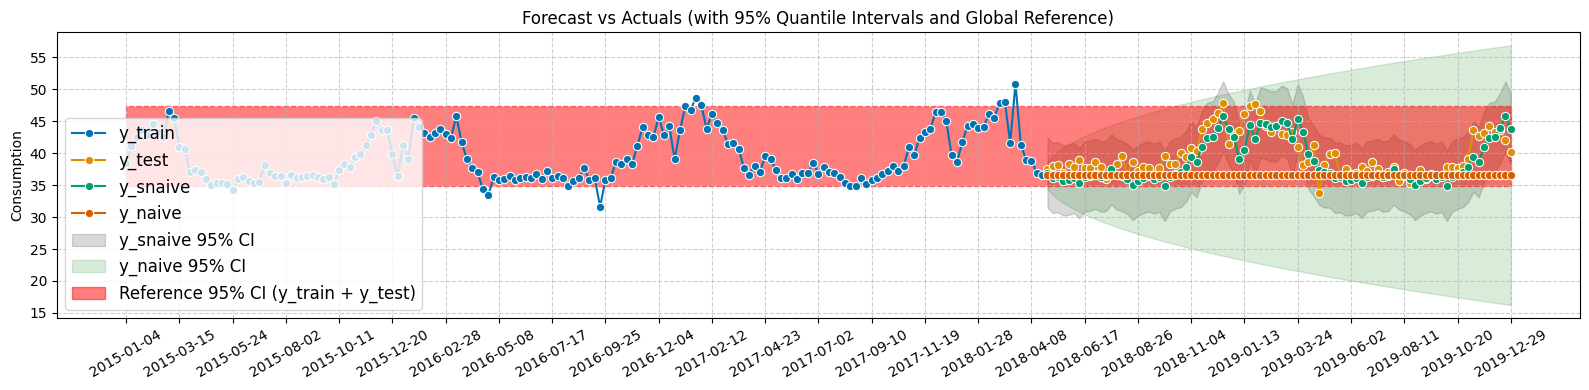

In [327]:

# Вычисляем квантили (например, 2.5% и 97.5%) по полному ряду
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)

# Создаём постоянные линии для эталонного интервала
ref_lower_series = pd.Series([ref_lower] * len(y), index=y.index)
ref_upper_series = pd.Series([ref_upper] * len(y), index=y.index)

# Построение графика
fig, ax = plot_series(y_train, y_test, y_pred1, y_pred2, labels=["y_train", "y_test", "y_snaive", "y_naive"])

# Квантильные интервалы ваших моделей
ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series1.values, 
             upper_series1.values, 
             color='k', 
             alpha=0.15)

ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series2.values, 
             upper_series2.values, 
             color='g', 
             alpha=0.15)

# Эталонный интервал (на основе объединённого ряда)
# Получаем X-данные из первой и последней линии
x_first = ax.get_lines()[0].get_xdata()
x_last = ax.get_lines()[-1].get_xdata()

# Объединяем
x_combined = np.concatenate([x_first, x_last])

ax.fill_between(x_combined, 
                ref_lower_series.values, ref_upper_series.values, 
                color='red', alpha=0.5, linestyle='--', label=None)

# Легенда
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
proxy_fill1 = Patch(color='k', alpha=0.15, label='y_snaive 95% CI')
proxy_fill2 = Patch(color='g', alpha=0.15, label='y_naive 95% CI')
proxy_fill_ref = Patch(color='red', alpha=0.5, label='Reference 95% CI (y_train + y_test)')

all_handles = handles + [proxy_fill1, proxy_fill2, proxy_fill_ref]
all_labels = labels + ['y_snaive 95% CI', 'y_naive 95% CI', 'Reference 95% CI (y_train + y_test)']

ax.legend(handles=all_handles, labels=all_labels, loc='best', fontsize=12)

plt.title('Forecast vs Actuals (with 95% Quantile Intervals and Global Reference)')
fix_plot(y)
plt.show()

В целом из графика виден недостаток выборки для корректировки решений

#### Оценка распределний вероятностей

Мы рассмотрели следующие варианты оценки вероятностных прогнозов:
- __Pinball loss__ по квантилям измеряет, насколько прогнозируемый квантиль соответствует фактической частоте превышений. <ul>
<li>Если Pinball loss маленький - значит фактические значения распределены относительно прогнозного квантиля близко к ожидаемой вероятности.
<li>Если Pinball loss большой, фактические значения чаще оказываются выше или ниже прогнозного квантиля, чем предполагает уровень квантиля.</ul>
- __Pinball loss для интервальных прогнозов__ измеряет, насколько границы прогнозного интервала согласованы с фактическими наблюдениями. <ul>
<li>Маленькие  значение Pinball loss - интервалы находятся на правильном уровне относительно фактических данных. 
<li>Большое значение Pinball loss - интервалы не соответствуют распределению наблюдаемых значений (слишком высокие, слишком низкие или слишком широкие/узкие).</ul>
- __Coverage error__ - насколько прогнозные интервалы соответствуют заявленным значениям квантилей вероятности.<br> Empirical coverage: доля фактических значений, которые попали внутрь прогнозного интервала (или ниже/выше квантиля).

Однако указанные величины не отвечают на несолько важных вопросов, которые могут возникнуть при сравнении моделей:
- на сколько смещены результаты моделей (__смещение__)<br>
```python
bias = (y_test.values[:, None] - pred_quantiles1.values).mean(axis=0)
```
<ul>
<li> Если положительный - прогноз выше фактических значений (верхние квантиля). </li>
<li> Если отрицательный - прогноз ниже (нижние квантиля). </li>
</ul>
- на сколько широкий интервал неопределенности оценки ( <b>Интерквантильная ширина</b> / дисперсия) <ul>
    
```python    
    iqr_width = (pred_quantiles['0.75'] - pred_quantiles['0.25']).mean()
```
более узкие интервалы → меньше неопределённости.    
</ul>
- как результаты восстонавливают распределение данных реальных прогнозов <b>Continuous Ranked Probability Score (CRPS)</b> <ul>
<li> Сравнивает всё прогнозное распределение с фактическим наблюдением.</li>
<li> Малое значение CRPS - распределение прогноза хорошо согласовано с фактическими данными.
    
```python
    from sktime.performance_metrics.forecasting import CRPS

    crps_score_1 = CRPS()(y_true=y_test, y_pred=pred_quantiles1)
    crps_score_2 = CRPS()(y_true=y_test, y_pred=pred_quantiles2)
```
</ul>
 


[CRPS (Continuous Ranked Probability Score)](https://dl.leima.is/time-series/timeseries-metrics.forecasting.crps/) — это метрика для вероятностных прогнозов, которая измеряет расхождение между прогнозным распределением и фактическим наблюдением.
Значения CRPS представляет собой оценку совместно дисперсии, смещения и покрытия квантилей.
 
 - Калибровка (coverage): CRPS снижается, если интервалы (квантили) соответствуют фактическим данным.
 - Sharpness (ширина распределения): слишком широкие интервалы увеличивают CRPS, потому что 
F расходится с индикатором.
- Bias (смещение): если прогноз систематически выше или ниже фактических значений, CRPS увеличивается.


<!-- Для каждого момента времени t проводится сравнение:

- Прогнозного распределения $F_t(y_t)$ (CDF – кумулятивная функция распределения).
- Фактического наблюдения $y_t$.
 -->
[CRPS определяется как](https://www.lokad.com/continuous-ranked-probability-score/):

$$ {CRPS(F_t, y_t) = \int_{-\infty}^{\infty}\Big(F_t(y)- {\mathbf 1}(y_t\le y)\Big)^2dy} $$

где 
- ${F(y)=\mathbf{P}\left[y \leq y_t\right]}$ – кумулятивная функция распределения (CDF)
- Фактического наблюдения $y_t$ для каждого момента времени t.
- ${\mathbf 1}(y_t\le z)$ - индекаторная функция Хевисайда (ступенька), принимающая значение 1 если аргумент выше 0 или 0 в ином случае.

CRPS обобщает среднюю абсолютную ошибку (MAE). Фактически,  (она сводится к MAE, если прогноз является детерминированным). 

На пракитке ${CRPS(F_t, y_t) = \sum_{k=0}^x F(y_k)^2 + \sum_{x+1}^{n} (F(y_k) - 1)^2} $ <br>
или 
 CRPS  может быть вычислен как *множественный квантильный прогноз* $\widehat{\bf y}:=\widehat{y}_1, \dots, \widehat{y}_k$ для квантилей ${\bf \alpha} = \alpha_1,\dots, \alpha_k$ 
$$CRPS \approx\frac{1}{k}\sum_{i=1}^k L_{\alpha_i}(\widehat{y}_i, y)$$

То есть CRPS — это  усреднённое значение пинболл по всем квантилям

#### Анализ результатов вероятностных прогнозов

In [328]:
def evaluate_forecaster(forecaster, y_train, y_test, fh, 
                        alpha=[0.025, 0.05, 0.125, 0.25, 0.5, 0.75, 0.875, 0.9, 0.95, 0.975],
                    fit = True):
    """
    Оценка вероятностного прогноза модели forecaster.
    
    Метрики:
    - Pinball loss по каждому alpha
    - CRPS
    - Bias (смещение медианного прогноза)
    - Sharpness (дисперсия прогнозов)
    - Coverage для CI50, CI75, CI90, CI95
    """
    if fit:
        forecaster.fit(y_train, fh=fh)
    
    pred_quantiles = forecaster.predict_quantiles(alpha=alpha)

    pl = PinballLoss(score_average=False)
    # Pinball по каждому alpha
    pinball_losses = {
        f"pinball_{int(a*100)}": pl(y_true=y_test, 
                                    y_pred=pred_quantiles[[col for col in pred_quantiles.columns if np.isclose(col[1], a)]]).mean()
        for a in alpha
    }

    # Интервалы
    def ci(alpha_low, alpha_high):
        lower_col = [col for col in pred_quantiles.columns if np.isclose(col[1], alpha_low)][0]
        upper_col = [col for col in pred_quantiles.columns if np.isclose(col[1], alpha_high)][0]
        lower = pred_quantiles[lower_col]  # это Series
        upper = pred_quantiles[upper_col]  # это Series
        return ((y_test >= lower) & (y_test <= upper)).mean()

    coverage_dict = {
        "CI_50": ci(0.25, 0.75),
        "CI_75": ci(0.125, 0.875),
        "CI_90": ci(0.05, 0.95),
        "CI_95": ci(0.025, 0.975)
    }

    # CRPS
    crps = np.mean([
        np.mean(np.maximum(a*(y_test - pred_quantiles[col]), (a-1)*(y_test - pred_quantiles[col])))
        for col in pred_quantiles.columns
        for a in [col[1]]
    ])

    # Bias и Sharpness
    median_col = [col for col in pred_quantiles.columns if np.isclose(col[1], 0.5)][0]
    median = pred_quantiles[median_col]  # <-- это Series
    bias = (y_test - median).mean()
    sharpness = pred_quantiles.var(axis=1).mean()

    result = {**pinball_losses, **coverage_dict, "crps": crps, "bias": bias, "sharpness": sharpness}
    return pd.Series(result)


In [329]:


# Сравнение двух моделей
metrics_snaive = evaluate_forecaster(forecaster1, y_train, y_test, fh)
metrics_naive  = evaluate_forecaster(forecaster2, y_train, y_test, fh)

pd.DataFrame([metrics_snaive, metrics_naive], index=["sNaive", "Naive"])


,pinball_2,pinball_5,pinball_12,pinball_25,pinball_50,pinball_75,pinball_87,pinball_90,pinball_95,pinball_97,CI_50,CI_75,CI_90,CI_95,crps,bias,sharpness
sNaive,0.296932,0.507369,0.929075,1.231273,0.924578,0.719903,0.649746,0.591825,0.395637,0.241066,0.886364,1.0,1.0,1.0,0.648741,1.117318,60.708394
Naive,0.747021,1.278977,2.353688,3.083490,1.650011,1.627630,1.571915,1.436625,0.966268,0.590666,0.909091,1.0,1.0,1.0,1.530629,3.127091,420.147997


Анализ результатов:

- Pinball Loss по квантилям:
    - sNaive показывает намного меньшие ошибки по всем квантилям, особенно для экстремальных 5% и 95% квантилей.
    - Naive сильно переоценивает прогнозные значения, особенно на краях распределения.
- Coverage
    - 90% и 95% - Обе модели покрывают интервалы полностью, т.е. фактические значения всегда лежат внутри 90% и 95% интервалов.
    - Это может указывать на слишком широкие интервалы.
    - Для CI50 немного недопокрытие у sNaive (0.886), у Naive чуть выше (0.909).

Это говорит, что интервалы у sNaive более информативные и компактные, а у Naive широкие, что "гарантирует" покрытие, но снижает точность прогноза.
- CRPS
    - Меньшее CRPS у sNaive → прогнозы ближе к реальному распределению и более информативны.
    - Naive хуже, вероятностная оценка менее точная.
- Bias (смещение)
    - sNaive имеет меньшее смещение — медианный прогноз почти совпадает с реальным значением.
    - Naive сильно завышает прогноз.
- Sharpness (разброс квантилей)
    - Naive генерирует очень широкий прогнозный интервал, отсюда и покрытие 100% — модель просто «слишком осторожная».
    - sNaive даёт более концентрированные и информативные прогнозы.

Вывод: 
- sNaive достаточно надежна для практики, а Naive — надежность достигается за счет чрезмерного расширения интервалов.
- Naive слишком широкий (прогнозы «не ломаются» при изменении внешних условий или шума) → устойчивый, но «неинформативный».
- sNaive: bias = 1.11, CRPS = 0.648 → стабильные прогнозы.
- Naive: bias = 3.12, CRPS = 1.53 → прогнозы чувствительны к вариациям данных.
- sNaive показывает адекватные значения pinball loss на краях → прогноз устойчив к экстремальным событиям.
- sNaive имеет узкие интервалы (меньший sharpness) с сохранением покрытия → прогностическая ценность выше.

Naive:
- Надежность искусственно достигнута за счет слишком широких интервалов.
- Неустойчива к экстремальным значениям: bias большой, CRPS высокий.
- Мало информативна для практических решений.

### Использование вероятностного прогназирование в процедуре `backtest`

#### evaluate  с PinballLoss

Изученная функция потерь может быть использована в режиме тестирования моделей, [например на ретроданных](https://www.sktime.net/en/latest/examples/01b_forecasting_proba.html#evaluation-by-backtesting).<br>
Для этого в функции `evaluate` нужно указывать заданный `pinball loss` как параметр  `scoring`. <br>
Отметим, что в результатах каждая строка - это один сплит тренировки/теста в режиме `walk forward` для заданной `cv` функции.

In [330]:
loss = PinballLoss()
 
fh=1+np.arange(SEASON)
cv = ExpandingWindowSplitter(step_length=10, fh=fh,  initial_window = len(y_train) )

forecaster =  NaiveForecaster(sp=SEASON)

results = evaluate(
    forecaster=forecaster, y=y.values, cv=cv, strategy="refit", return_data=True, scoring=[loss, mae]
)


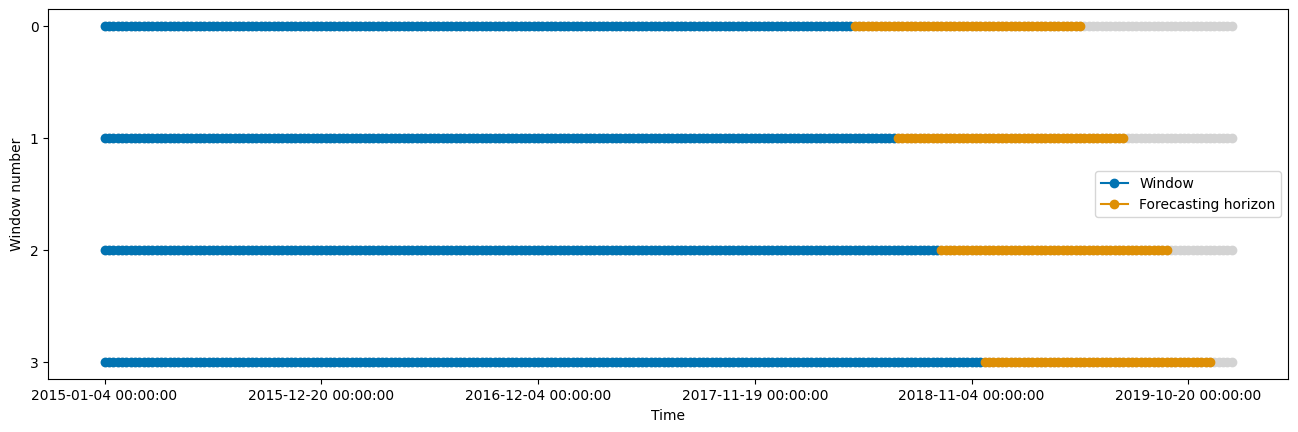

In [331]:
plot_windows(cv, y,); plt.show()

In [332]:
results.iloc[:, :5]

,test_PinballLoss,test_MeanAbsoluteError,fit_time,pred_quantiles_time,pred_time
0,0.290570,2.087057,0.004136,0.047709,0.023801
1,0.290288,2.094113,0.001053,0.018197,0.016425
2,0.290226,2.017906,0.000802,0.017227,0.016025
3,0.290012,2.015226,0.000807,0.017136,0.016091


- Изменение менее 0.001 между фолдами -  очень высокая стабильность квантильного прогноза
- Модель не чувствительна к сдвигу точки валидации (cut point)
- Небольшие колебания (MAE~4%) - Есть слабое улучшение при увеличении train window

Проверим тоже для остальных метрик

#### Детальный анализ ExpandingWindowSplitter

In [357]:
def run_cross_validation(forecaster, y, cv, sp=SEASON, refit=True):
    results_list = []
    current_forecaster = forecaster.clone() if hasattr(forecaster, 'clone') else NaiveForecaster(sp=sp)
    
    # Фитим один раз, если refit=False
    if not refit:
        # Получаем индексы первого фолда
        train_idx_first, test_idx_first = next(cv.split(y.values))
        y_train_first = y.values[train_idx_first]
        current_forecaster.fit(y_train_first, fh=np.arange(1, len(y.values[test_idx_first])+1))
    
    for train_idx, test_idx in cv.split(y.values):
        y_train_cv, y_test_cv = y.values[train_idx], y.values[test_idx]
        
        # Если refit=True, фитим каждый раз
        if refit:
            current_forecaster.fit(y_train_cv, fh=np.arange(1, len(y_test_cv)+1))
        
        # Оценка модели на этом окне
        metrics = evaluate_forecaster(
            forecaster=current_forecaster,
            y_train=y_train_cv,
            y_test=y_test_cv,
            fh=np.arange(1, len(y_test_cv)+1),
            fit=False  # уже обучена
        )
        
        # Добавляем window length и cut_date
        metrics["window_length"] = len(train_idx)
        metrics["cut_date"] = y.index[train_idx[-1]]
        
        results_list.append(metrics)
    
    return pd.DataFrame(results_list)

- покрытие не меняется при росте window_length  - признак структурной устойчивости.
- экстремальные квантили ограничены длиной ряда и наивным методом.
- Повышение sharpness без потери coverage - Прогноз становится и более точным, и более уверенным при росте window_length
- Модель устойчива по разбросу, но неустойчива по уровню (знак смещения меняется)
- Распределение в целом инвариантно к cut_date.

#### SlidingWindowSplitter

In [358]:
cv = SlidingWindowSplitter(step_length=10, fh=fh, window_length=len(y_train) )  
df_metrics_cv = run_cross_validation(forecaster1, y, cv, SEASON)
df_metrics_cv

,pinball_2,pinball_5,pinball_12,pinball_25,pinball_50,pinball_75,pinball_87,pinball_90,pinball_95,pinball_97,CI_50,CI_75,CI_90,CI_95,crps,bias,sharpness,window_length,cut_date
0,0.300018,0.513540,0.944503,1.278539,1.046660,0.717161,0.634319,0.579483,0.389466,0.237981,0.886792,1.0,1.0,1.0,0.664167,1.240736,60.708394,173.0,2018-04-22
1,0.281403,0.480991,0.881497,1.176769,0.988696,0.701140,0.611880,0.557635,0.373145,0.227480,0.849057,1.0,1.0,1.0,0.628064,1.078467,54.315265,173.0,2018-07-01
2,0.274212,0.466394,0.844156,1.102410,0.898869,0.779506,0.653164,0.590841,0.389997,0.236014,0.867925,1.0,1.0,1.0,0.623556,0.763969,54.602381,173.0,2018-09-09
3,0.272995,0.462951,0.831597,1.067242,0.827326,0.818620,0.684113,0.616440,0.403958,0.243498,0.849057,1.0,1.0,1.0,0.622874,0.589932,55.951915,173.0,2018-11-18


- Интервалы сильно переоценены (слишком широкие)
- неопределённость «структурная»  - Sharpness варьируется
- crps: устойчивая форма распределения
- смещение явно присутствует, модель слишьком простая

#### SlidingWindowSplitter стратегия без рефит

In [359]:
cv = SlidingWindowSplitter(step_length=10, fh=fh, window_length=len(y_train) )  
df_metrics_cv = run_cross_validation(forecaster1, y, cv, SEASON, refit = False)
df_metrics_cv

,pinball_2,pinball_5,pinball_12,pinball_25,pinball_50,pinball_75,pinball_87,pinball_90,pinball_95,pinball_97,CI_50,CI_75,CI_90,CI_95,crps,bias,sharpness,window_length,cut_date
0,0.300018,0.513540,0.944503,1.278539,1.046660,0.717161,0.634319,0.579483,0.389466,0.237981,0.886792,1.000000,1.000000,1.000000,0.664167,1.240736,60.708394,173.0,2018-04-22
1,0.299576,0.545207,1.109283,1.745669,2.016374,1.559087,1.008445,0.855242,0.480742,0.262945,0.490566,0.773585,0.924528,0.962264,0.988257,1.223075,60.708394,173.0,2018-07-01
2,0.293833,0.501171,1.164256,2.106966,2.858956,2.281740,1.405442,1.155974,0.584270,0.270506,0.245283,0.547170,0.905660,0.943396,1.262311,0.993358,60.708394,173.0,2018-09-09
3,0.292956,0.508755,1.225108,2.164916,3.025311,2.387039,1.395434,1.145784,0.593614,0.275195,0.245283,0.509434,0.849057,0.943396,1.301411,0.958264,60.708394,173.0,2018-11-18


при выборе стратегии без рефит - по сути стратегии долгосрочного предсказания:
- качество вероятностного прогноза ухудшается с ростом горизонта прогноза
- при этом все меньше значений попадают в интервал
- смщение слегка падает. ширина прогноза не меняется
  

### Калибровка интервалов

#### Бут-стреп калибровка

Калибровка квантилей — это коррекция прогнозных интервалов, чтобы они лучше соответствовали реальному покрытию (например, 95% интервал должен ловить 95% точек).

В задачах прикладного анализа данных при использовании вероятностных прогнозов возникает проблема калибровки вероятности: даже если модель выдаёт квантили, они не обязательно соответствуют заявленному уровню покрытия (например, 90% интервал может ловить только 70% точек). Калиброванная модель гарантирует, что при регулярных условиях работы эмпирическое покрытие совпадает с номинальным.

Для калибровки применяются несколько подходов:

- Bootstrap-based calibration (беггинг) — коррекция квантилей на основе остатков модели в тренировочной выборке
- Conformal Prediction — построение интервалов по валидационной (калибровочной) подвыборке ( метод имеет теоретическую гарантию даже на конечной выборки);
<!-- - Probability Integral Transform (PIT) — диагностика и коррекция через трансформацию прогнозного распределения. -->
- 
Рассмотрим беггинг. Метод реализуется следующим образом:
- На обучающей части ряда строится in-sample прогноз (пошагово или скользящим окном), из которого извлекаются остатки — разница между фактом и прогнозом.
- Для каждого шага горизонта прогнозирования генерируется набор псевдореализаций будущего: к точечному прогнозу добавляются случайно перемешанные подвыборки остатков.
- По этим псевдореализациям вычисляются эмпирические квантили (например, 5% и 95%), которые и служат калиброванными границами интервала.

Такой подход не требует предположений о распределении ошибок и устойчив к нестационарности, так как использует только наблюдаемую историю ошибок модели.

In [400]:
TEST_SIZE = int(0.34 * y.size)

y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

In [402]:
forecaster = NaiveForecaster(strategy="mean", sp = SEASON) 

fh = ForecastingHorizon(y_test.index, is_relative=False)
forecaster.fit(y_train) 

y_pred = forecaster.predict(fh=fh)


pred_quantiles = forecaster.predict_quantiles(alpha=[0.05,0.1,0.25,0.5001,0.75,0.9, 0.95])


In [405]:
def bootstrap_calibration_quantiles(forecaster, y_train, y_test, fh, alpha=[0.05, 0.1, 0.25, 0.5001, 0.75, 0.9, 0.95], B=1000):
    # Обучаем модель
    forecaster.fit(y_train, fh=fh)
    y_pred = forecaster.predict(fh=fh)

    # Получаем остатки: делаем "in-sample" прогнозы по частям
    # чтобы не было NaN
    residuals = []
    for i in range(len(y_train)):
        if i >= SEASON:
            # Используем последние SEASON точек для прогноза на i
            subset = y_train[i-SEASON:i]
            temp_forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
            temp_forecaster.fit(subset)
            y_pred_in = temp_forecaster.predict(fh=[1])
            residuals.append(y_train.iloc[i] - y_pred_in.iloc[0])
    
    residuals = np.array(residuals)

    # Bootstrap квантили
    calibrated_quantiles = {}
    for a in alpha:
        boot_quantiles = []
        for _ in range(B):
            boot_res = np.random.choice(residuals, size=len(y_pred), replace=True)
            y_boot = y_pred.values + boot_res  # используем .values чтобы избежать индексов
            q = np.quantile(y_boot, a)
            boot_quantiles.append(q)
        calibrated_quantiles[a] = np.mean(boot_quantiles)
    
    return pd.Series(calibrated_quantiles)

# Применение
calibrated_quantiles = bootstrap_calibration_quantiles(forecaster, y_train, y_test, fh)
calibrated_quantiles

0.0500    33.749326
0.1000    34.827532
0.2500    36.199629
0.5001    37.926594
0.7500    42.047602
0.9000    44.887543
0.9500    46.145955
dtype: float64

In [407]:
# Прогноз
y_pred = forecaster.predict(fh=fh)

# Квантили
lower_90 = calibrated_quantiles[0.05]  # 5%
upper_90 = calibrated_quantiles[0.95]  # 95%

# Или для каждого шага fh:
# Преобразуем fh в индекс
fh_index = fh.to_pandas()

lower_series = pd.Series([calibrated_quantiles[0.05]] * len(fh), index=fh_index)
upper_series = pd.Series([calibrated_quantiles[0.95]] * len(fh), index=fh_index)

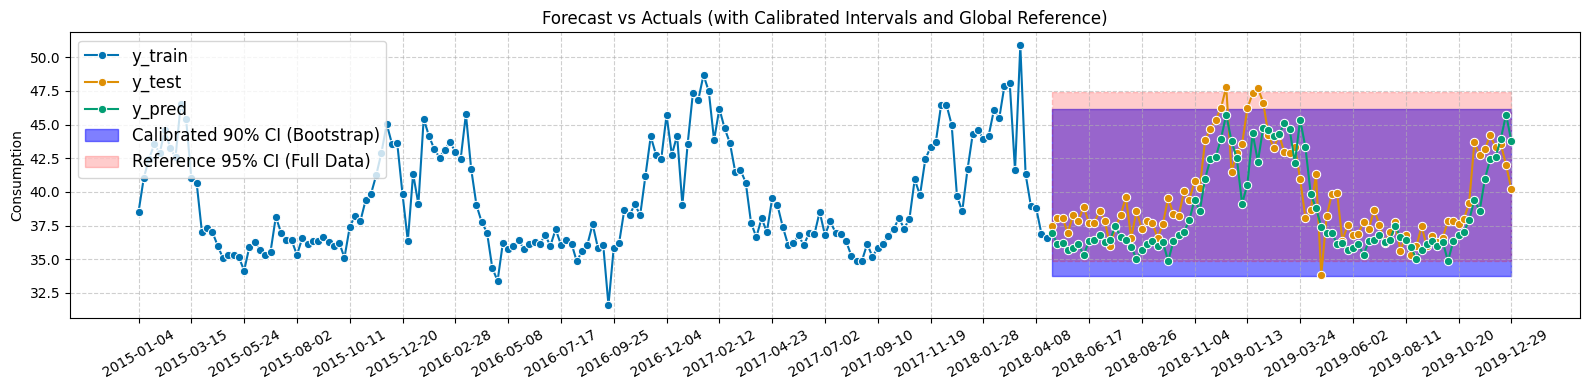

In [411]:
# Прогноз
y_pred = forecaster.predict(fh=fh)

# Построение графика
fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

# Bootstrap калиброванные интервалы (для fh)
ax.fill_between(ax.get_lines()[-1].get_xdata(), 
             lower_series.values, 
             upper_series.values, 
             color='b', 
             alpha=0.5)

# Эталонный интервал (на основе объединённого ряда) — только для точек y_test
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)
ref_lower_series = pd.Series([ref_lower] * len(y_test), index=y_test.index)
ref_upper_series = pd.Series([ref_upper] * len(y_test), index=y_test.index)

ax.fill_between(ax.get_lines()[-1].get_xdata(), 
                ref_lower_series.values, ref_upper_series.values, 
                color='red', alpha=0.2, linestyle='--', label=None)

# Легенда
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
proxy_fill1 = Patch(color='b', alpha=0.5, label='Calibrated 90% CI (Bootstrap)')
proxy_fill_ref = Patch(color='red', alpha=0.2, label='Reference 95% CI (Full Data)')

all_handles = handles + [proxy_fill1, proxy_fill_ref]
all_labels = labels + ['Calibrated 90% CI (Bootstrap)', 'Reference 95% CI (Full Data)']

ax.legend(handles=all_handles, labels=all_labels, loc='best', fontsize=12)

plt.title('Forecast vs Actuals (with Calibrated Intervals and Global Reference)')
fix_plot(y)
plt.show()

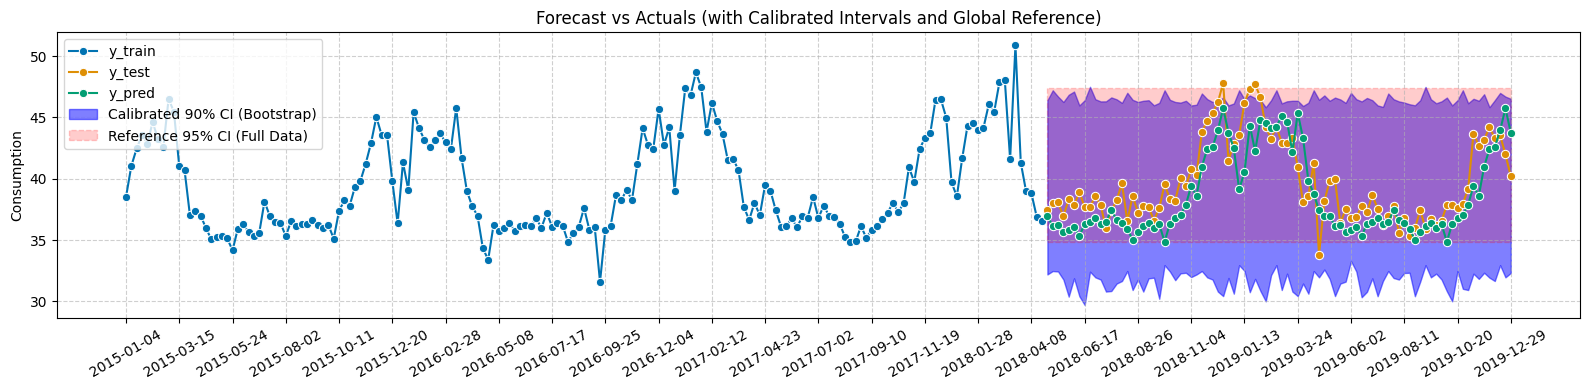

In [485]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series
from matplotlib.patches import Patch

# ---------------------------
# Настройки
# ---------------------------
SEASON = 7  # например, недельная сезонность
TEST_SIZE = 0.34  # доля теста

# y — это твой Series временного ряда
# Пример: y = pd.Series(..., index=pd.date_range(...))
SEASON = 53
# ---------------------------
# Train/Test split
# ---------------------------
TEST_SIZE = int(TEST_SIZE * y.size)
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

fh = ForecastingHorizon(y_test.index, is_relative=False)
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster.fit(y_train) 

# y_pred = forecaster.predict(fh=fh)
# fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

# ---------------------------
# Функция bootstrap для квантили
# ---------------------------
def bootstrap_calibration_quantiles(forecaster, y_train, fh, alpha=[0.05, 0.95], B=1000):
    forecaster.fit(y_train)
    y_pred = forecaster.predict(fh=fh)
    n_pred = len(y_pred)

    # 1. Рассчитаем остатки in-sample
    residuals = []
    for i in range(SEASON, len(y_train)):
        temp_forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
        temp_forecaster.fit(y_train[i-SEASON:i])
        y_pred_in = temp_forecaster.predict(fh=[1])
        residuals.append(y_train.iloc[i] - y_pred_in.iloc[0])
    residuals = np.array(residuals)

    # 2. Для каждого шага fh делаем бутстрап
    calibrated_lower = []
    calibrated_upper = []
    for t in range(n_pred):
        boot_samples = []
        for b in range(B):
            boot_res = np.random.choice(residuals, size=1, replace=True)
            boot_samples.append(y_pred.iloc[t] + boot_res[0])
        calibrated_lower.append(np.quantile(boot_samples, alpha[0]))
        calibrated_upper.append(np.quantile(boot_samples, alpha[1]))

    lower_series = pd.Series(calibrated_lower, index=y_pred.index)
    upper_series = pd.Series(calibrated_upper, index=y_pred.index)

    return lower_series, upper_series


#lower_series, upper_series = bootstrap_calibration_quantiles(forecaster, y_train, fh, alpha=[0.05, 0.95], B=1000)

y_pred = forecaster.predict(fh=fh)

fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

# Калиброванные интервалы
x = ax.get_lines()[-1].get_xdata()
ax.fill_between(x, lower_series.values, upper_series.values, color='b', alpha=0.5, label='Calibrated 90% CI (Bootstrap)')

# Эталонный интервал
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)
ref_lower_full = np.full(len(x), ref_lower)
ref_upper_full = np.full(len(x), ref_upper)
ax.fill_between(x, ref_lower_full, ref_upper_full, color='red', alpha=0.2, linestyle='--', label='Reference 95% CI (Full Data)')

ax.legend(loc='best')
plt.title('Forecast vs Actuals (with Calibrated Intervals and Global Reference)')
fix_plot(y)
plt.show()

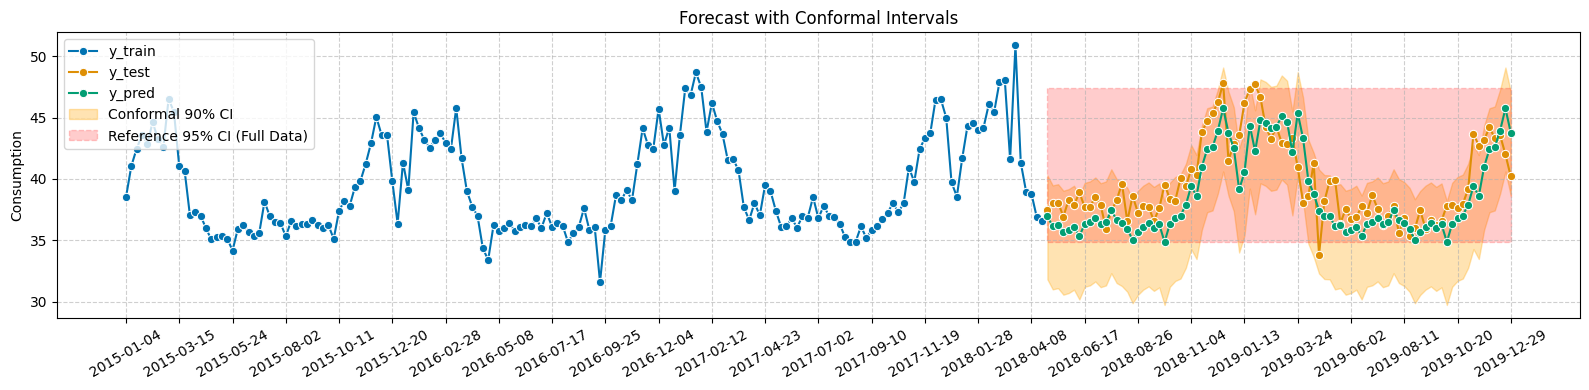

Конформное покрытие 90% CI: 88.64%


In [491]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series
from matplotlib.patches import Patch

# ---------------------------
# Настройки
# ---------------------------
SEASON = 53  # недельная сезонность
TEST_SIZE = 0.34  # доля теста
ALPHA = 0.1   # уровень доверия: 0.1 -> 90% CI
B = 1000      # для bootstrap

# y — твой Series временного ряда
# y = pd.Series(..., index=pd.date_range(...))

# ---------------------------
# Train/Test split
# ---------------------------
TEST_SIZE = int(TEST_SIZE * y.size)
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)
fh = ForecastingHorizon(y_test.index, is_relative=False)

# ---------------------------
# Обучаем NaiveForecaster
# ---------------------------
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster.fit(y_train)
y_pred = forecaster.predict(fh=fh)

# ---------------------------
# Конформные интервалы
# ---------------------------
# 1. In-sample остатки
residuals = []
for i in range(SEASON, len(y_train)):
    temp_forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
    temp_forecaster.fit(y_train[i-SEASON:i])
    y_in = temp_forecaster.predict(fh=[1])
    residuals.append(y_train.iloc[i] - y_in.iloc[0])
residuals = np.array(residuals)

# 2. Конформный интервал для теста
lower_conf = y_pred.values - np.quantile(residuals, 1-ALPHA/2)
upper_conf = y_pred.values - np.quantile(residuals, ALPHA/2)

# Преобразуем в Series для удобства
lower_series_conf = pd.Series(lower_conf, index=y_pred.index)
upper_series_conf = pd.Series(upper_conf, index=y_pred.index)

# ---------------------------
# Визуализация
# ---------------------------
fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

# Конформные интервалы
x = ax.get_lines()[-1].get_xdata()  # индексы точек предсказания
ax.fill_between(x, lower_series_conf.values, upper_series_conf.values, 
                color='orange', alpha=0.3, label='Conformal 90% CI')

# Эталонный интервал по всему ряду
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)
ref_lower_full = np.full(len(x), ref_lower)
ref_upper_full = np.full(len(x), ref_upper)
ax.fill_between(x, ref_lower_full, ref_upper_full, color='red', alpha=0.2, linestyle='--', 
                label='Reference 95% CI (Full Data)')

ax.legend(loc='best')
plt.title('Forecast with Conformal Intervals')
fix_plot(y)
plt.show()

# ---------------------------
# Проверка покрытия
# ---------------------------
coverage_conf = ((y_test >= lower_series_conf) & (y_test <= upper_series_conf)).mean()
print(f"Конформное покрытие 90% CI: {coverage_conf:.2%}")


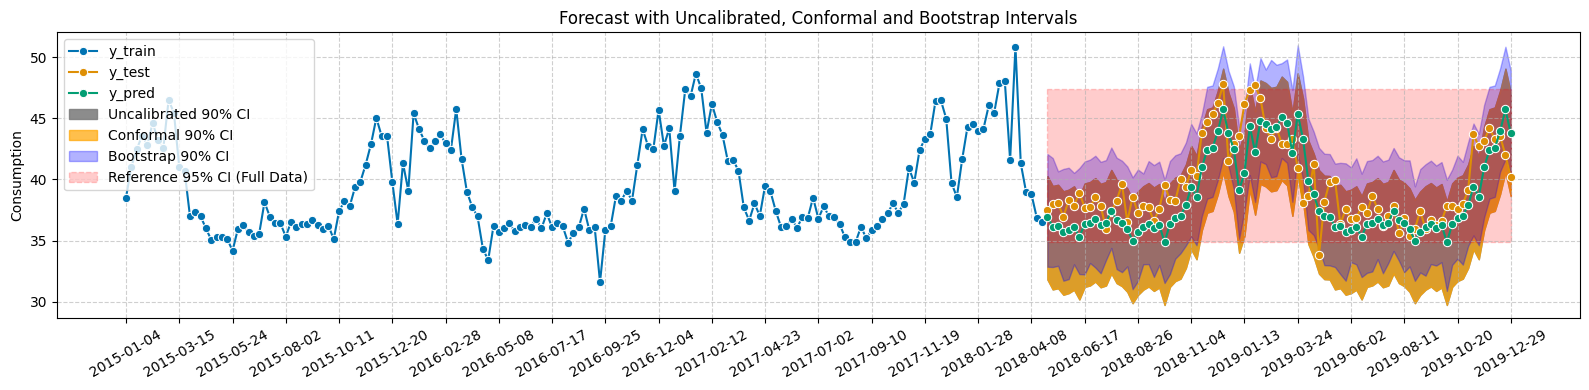

Uncalibrated coverage 90% CI: 88.64%
Conformal coverage 90% CI: 88.64%
Bootstrap coverage 90% CI: 93.18%


In [504]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series
from matplotlib.patches import Patch

# ---------------------------
# Настройки
# ---------------------------
SEASON = 53  # недельная сезонность
TEST_SIZE = 0.34
ALPHA = 0.1  # 90% CI
B = 1000    # для bootstrap

# ---------------------------
# Train/Test split
# ---------------------------
TEST_SIZE = int(TEST_SIZE * y.size)
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)
fh = ForecastingHorizon(y_test.index, is_relative=False)

# ---------------------------
# Обучаем NaiveForecaster
# ---------------------------
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster.fit(y_train)
y_pred = forecaster.predict(fh=fh)

# ---------------------------
# Остатки in-sample
# ---------------------------
residuals = []
for i in range(SEASON, len(y_train)):
    temp_forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
    temp_forecaster.fit(y_train[i-SEASON:i])
    y_in = temp_forecaster.predict(fh=[1])
    residuals.append(y_train.iloc[i] - y_in.iloc[0])
residuals = np.array(residuals)

# ---------------------------
# Чистый (uncalibrated) интервал
# ---------------------------
lower_uncal = y_pred.values - np.quantile(residuals, 1-ALPHA/2)
upper_uncal = y_pred.values - np.quantile(residuals, ALPHA/2)
lower_series_uncal = pd.Series(lower_uncal, index=y_pred.index)
upper_series_uncal = pd.Series(upper_uncal, index=y_pred.index)

# ---------------------------
# Конформные интервалы
# ---------------------------
lower_conf = y_pred.values - np.quantile(residuals, 1-ALPHA/2)
upper_conf = y_pred.values - np.quantile(residuals, ALPHA/2)
lower_series_conf = pd.Series(lower_conf, index=y_pred.index)
upper_series_conf = pd.Series(upper_conf, index=y_pred.index)

# ---------------------------
# Bootstrap интервалы
# ---------------------------
n_pred = len(y_pred)
lower_boot, upper_boot = [], []

for t in range(n_pred):
    boot_samples = []
    for b in range(B):
        boot_res = np.random.choice(residuals, size=1, replace=True)
        boot_samples.append(y_pred.iloc[t] + boot_res[0])
    lower_boot.append(np.quantile(boot_samples, ALPHA/2))
    upper_boot.append(np.quantile(boot_samples, 1-ALPHA/2))

lower_series_boot = pd.Series(lower_boot, index=y_pred.index)
upper_series_boot = pd.Series(upper_boot, index=y_pred.index)

# ---------------------------
# Визуализация
# ---------------------------
fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
x = ax.get_lines()[-1].get_xdata()  # индексы точек предсказания

# Чистый интервал до калибровки
ax.fill_between(x, lower_series_uncal.values, upper_series_uncal.values, color='grey', alpha=0.9, label='Uncalibrated 90% CI')

# Конформный интервал
ax.fill_between(x, lower_series_conf.values, upper_series_conf.values, color='orange', alpha=0.7, label='Conformal 90% CI')

# Bootstrap-интервал
ax.fill_between(x, lower_series_boot.values, upper_series_boot.values, color='blue', alpha=0.3, label='Bootstrap 90% CI')

# Эталонный интервал по всему ряду
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)
ref_lower_full = np.full(len(x), ref_lower)
ref_upper_full = np.full(len(x), ref_upper)
ax.fill_between(x, ref_lower_full, ref_upper_full, color='red', alpha=0.2, linestyle='--', label='Reference 95% CI (Full Data)')

ax.legend(loc='best')
plt.title('Forecast with Uncalibrated, Conformal and Bootstrap Intervals')
fix_plot(y)
plt.show()

# ---------------------------
# Проверка покрытия
# ---------------------------
coverage_uncal = ((y_test >= lower_series_uncal) & (y_test <= upper_series_uncal)).mean()
coverage_conf = ((y_test >= lower_series_conf) & (y_test <= upper_series_conf)).mean()
coverage_boot = ((y_test >= lower_series_boot) & (y_test <= upper_series_boot)).mean()
print(f"Uncalibrated coverage 90% CI: {coverage_uncal:.2%}")
print(f"Conformal coverage 90% CI: {coverage_conf:.2%}")
print(f"Bootstrap coverage 90% CI: {coverage_boot:.2%}")


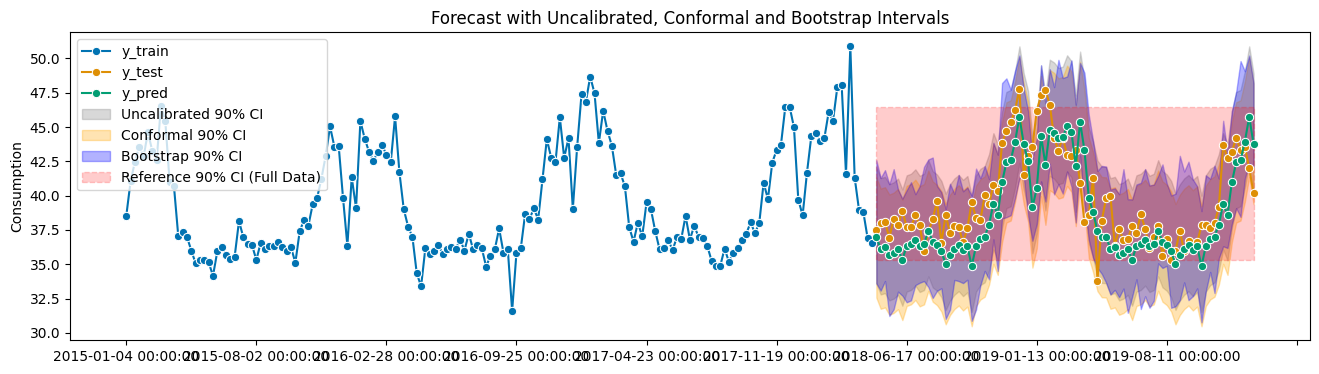

Uncalibrated 90% CI coverage: 92.05%
Conformal 90% CI coverage: 93.18%
Bootstrap 90% CI coverage: 90.91%


In [506]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# ---------------------------
# Настройки
# ---------------------------
SEASON = 53  # недельная сезонность
TEST_SIZE = 0.34
ALPHA = 0.1   # 90% CI
B = 100      # для bootstrap

# ---------------------------
# Train/Test split
# ---------------------------
TEST_SIZE_INT = int(TEST_SIZE * len(y))
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE_INT)
fh = ForecastingHorizon(y_test.index, is_relative=False)

# ---------------------------
# Naive Forecaster
# ---------------------------
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster.fit(y_train)
y_pred = forecaster.predict(fh=fh)

# ---------------------------
# Остатки in-sample
# ---------------------------
residuals = []
for i in range(SEASON, len(y_train)):
    temp_forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
    temp_forecaster.fit(y_train[i-SEASON:i])
    y_in = temp_forecaster.predict(fh=[1])
    residuals.append(y_train.iloc[i] - y_in.iloc[0])
residuals = np.array(residuals)

# ---------------------------
# Uncalibrated Interval (просто ± квантиль остатков)
# ---------------------------
q_low  = np.quantile(residuals, ALPHA / 2)
q_high = np.quantile(residuals, 1 - ALPHA / 2)

lower_series_unc = y_pred + q_low
upper_series_unc = y_pred + q_high


# ---------------------------
# Split Conformal Interval
# ---------------------------
# Для split conformal обычно используют абсолютные ошибки
abs_residuals = np.abs(residuals)
q_conf = np.quantile(abs_residuals, 1-ALPHA)
lower_series_conf = y_pred - q_conf
upper_series_conf = y_pred + q_conf

# ---------------------------
# Bootstrap Interval
# ---------------------------
n_pred = len(y_pred)
lower_boot, upper_boot = [], []

for t in range(n_pred):
    boot_samples = y_pred.iloc[t] + np.random.choice(residuals, size=B, replace=True)
    lower_boot.append(np.quantile(boot_samples, ALPHA/2))
    upper_boot.append(np.quantile(boot_samples, 1-ALPHA/2))

lower_series_boot = pd.Series(lower_boot, index=y_pred.index)
upper_series_boot = pd.Series(upper_boot, index=y_pred.index)

# ---------------------------
# Визуализация
# ---------------------------
fig, ax = plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
x = ax.get_lines()[-1].get_xdata()

# Uncalibrated
ax.fill_between(x, lower_series_unc.values, upper_series_unc.values, color='gray', alpha=0.3, label='Uncalibrated 90% CI')

# Conformal
ax.fill_between(x, lower_series_conf.values, upper_series_conf.values, color='orange', alpha=0.3, label='Conformal 90% CI')

# Bootstrap
ax.fill_between(x, lower_series_boot.values, upper_series_boot.values, color='blue', alpha=0.3, label='Bootstrap 90% CI')

# Reference (полный ряд)
ref_lower = y.quantile(0.05)
ref_upper = y.quantile(0.95)
ax.fill_between(x, np.full_like(x, ref_lower), np.full_like(x, ref_upper), color='red', alpha=0.2, linestyle='--', label='Reference 90% CI (Full Data)')

ax.legend(loc='best')
plt.title('Forecast with Uncalibrated, Conformal and Bootstrap Intervals')
plt.show()

# ---------------------------
# Покрытие
# ---------------------------
coverage_unc = ((y_test >= lower_series_unc) & (y_test <= upper_series_unc)).mean()
coverage_conf = ((y_test >= lower_series_conf) & (y_test <= upper_series_conf)).mean()
coverage_boot = ((y_test >= lower_series_boot) & (y_test <= upper_series_boot)).mean()

print(f"Uncalibrated 90% CI coverage: {coverage_unc:.2%}")
print(f"Conformal 90% CI coverage: {coverage_conf:.2%}")
print(f"Bootstrap 90% CI coverage: {coverage_boot:.2%}")


In [499]:
def get_conformal_intervals(forecaster, y_train, y_test, alpha=0.05):
    """
    Возвращает точечный прогноз и конформные интервалы для y_test.
    Использует y_train для обучения и калибровки.
    """
    from sktime.forecasting.base import ForecastingHorizon
    import numpy as np

    # Горизонт — индексы из y_test
    fh = ForecastingHorizon(y_test.index, is_relative=False)
    
    # Обучаем модель на y_train
    forecaster.fit(y_train, fh=fh)
    y_pred = forecaster.predict(fh=fh)
    
    # Собираем остатки на y_train (скользящим окном)
    residuals = []
    for i in range(1, len(y_train)):
        temp_f = forecaster.clone()
        temp_f.fit(y_train[:i], fh=[1])
        pred_i = temp_f.predict(fh=[1]).iloc[0]
        residuals.append(abs(y_train.iloc[i] - pred_i))
    
    if not residuals:
        raise ValueError("Недостаточно данных для калибровки")
    
    # Квантиль ошибок
    q = np.quantile(residuals, 1 - alpha)
    
    # Интервалы
    lower = y_pred - q
    upper = y_pred + q
    
    return y_pred, lower, upper

In [500]:
def plot_with_intervals(y_train, y_test, y_pred, lower, upper, title="Forecast"):
    from sktime.utils.plotting import plot_series
    from matplotlib.patches import Patch
    import matplotlib.pyplot as plt

    # Строим график
    fig, ax = plot_series(y_train, y_test, y_pred, labels=["Train", "Test", "Pred"])
    
    # ЗОЛОТОЕ ПРАВИЛО: X берём из последней линии
    x = ax.get_lines()[-1].get_xdata()
    
    # Заполняем — ТОЛЬКО .values!
    ax.fill_between(x, lower.values, upper.values, color='blue', alpha=0.2)
    
    # Легенда
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Patch(color='blue', alpha=0.2))
    labels.append('95% Conformal Interval')
    ax.legend(handles, labels)
    
    ax.set_title(title)
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Ver

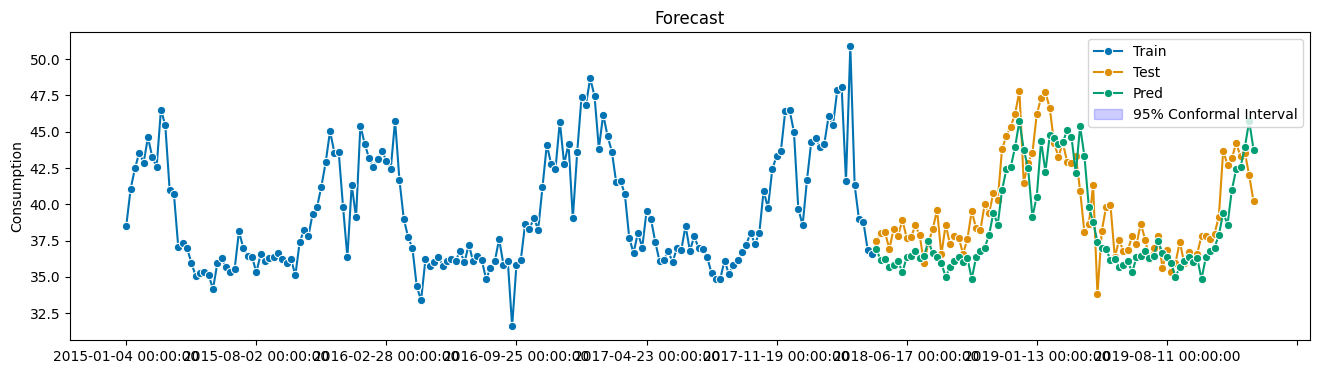

In [501]:
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)
y_pred, lower, upper = get_conformal_intervals(forecaster, y_train, y_test, alpha=0.05)
plot_with_intervals(y_train, y_test, y_pred, lower, upper)

 Алгоритм: Конформное прогнозирование (Conformal Prediction) для временных рядов
Вход:

Исторический временной ряд 
y
=
(
y
1
,
…
,
y
T
)
y=(y 
1
​
 ,…,y 
T
​
 )
Базовая модель прогнозирования (например, NaiveForecaster)
Желаемый уровень покрытия 
1
−
α
1−α (например, 0.95)
Горизонт прогноза 
H
H (сколько шагов вперёд предсказываем)
Шаг 1. Разделение данных на обучение и калибровку
Выберите размер калибровочного окна 
M
M (например, последние 20–200 точек).
Обучающая часть: 
y
train
=
y
1
:
T
−
M
y 
train
​
 =y 
1:T−M
​
 
Калибровочная часть: 
y
calib
=
y
T
−
M
+
1
:
T
y 
calib
​
 =y 
T−M+1:T
​
 
⚠️ Важно: разделение строго последовательное, без перемешивания!

Шаг 2. Генерация in-sample прогнозов на калибровочной части
Для каждого момента 
t
=
T
−
M
+
1
,
…
,
T
t=T−M+1,…,T:

Обучите временную копию модели на данных до 
t
t: 
y
1
:
t
−
1
y 
1:t−1
​
 
Сделайте 1-шаговый прогноз: 
y
^
t
y
^
​
  
t
​
 
Вычислите nonconformity score (меру несоответствия):
s
t
=
∣
y
t
−
y
^
t
∣
s 
t
​
 =∣y 
t
​
 − 
y
^
​
  
t
​
 ∣
Шаг 3. Определение квантиля калибровки
Найдите эмпирический квантиль уровня 
1
−
α
1−α от всех 
s
t
s 
t
​
 :
q
1
−
α
=
quantile
(
{
s
t
}
,
  
1
−
α
)
q 
1−α
​
 =quantile({s 
t
​
 },1−α)
Шаг 4. Построение финального прогноза
Обучите базовую модель на всём доступном ряду 
y
1
:
T
y 
1:T
​
 
Получите точечный прогноз на будущее: 
y
^
T
+
1
,
…
,
y
^
T
+
H
y
^
​
  
T+1
​
 ,…, 
y
^
​
  
T+H
​
 
Шаг 5. Формирование конформных интервалов
Для каждого шага 
h
=
1
,
…
,
H
h=1,…,H:

Нижняя граница: 
y
^
T
+
h
−
q
1
−
α
Верхняя граница: 
y
^
T
+
h
+
q
1
−
α
Нижняя граница:  
y
^
​
  
T+h
​
 −q 
1−α
​
 
Верхняя граница:  
y
^
​
  
T+h
​
 +q 
1−α
​
 
✅ Результат:
Прогнозный интервал 
[
y
^
T
+
h
±
q
1
−
α
]
[ 
y
^
​
  
T+h
​
 ±q 
1−α
​
 ]
При условии обменяемости ошибок гарантируется:
P
(
y
T
+
h
∈
интервал
)
≥
1
−
α
P(y 
T+h
​
 ∈интервал)≥1−α

In [472]:
from sktime.forecasting.naive import NaiveForecaster

# Разделение данных (без перемешивания!)
train_end = len(y) // 2
calib_end =  len(y)-train_end

y_train_ = y[:train_end]
y_calib_ = y[train_end:calib_end]
 

fh_test = ForecastingHorizon(y_test.index, is_relative=False)

# Модель
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)

# Конформные интервалы
lower, upper = conformal_prediction_intervals(
    forecaster=forecaster,
    y_train=y_train,
    y_calib=y_calib,
    fh_test=fh_test,
    alpha=0.05  # 95% CI
)

# Оценка покрытия
coverage = ((y_test >= lower) & (y_test <= upper)).mean()
print(f"Empirical coverage: {coverage:.3f}")

Empirical coverage: 1.000


In [468]:
# 1. Разделите данные НА ТЕКУЩИЙ МОМЕНТ
#    Например: последние 20 точек — калибровка, всё остальное — обучение
calib_size = 200
y_train = y[:-calib_size]   # обучение
y_calib  = y[-calib_size:]  # калибровка (самые свежие данные!)

# 2. Горизонт прогноза — будущее (относительно конца y)
H = 80  # например, 8 недель вперёд
fh_future = ForecastingHorizon(np.arange(1, H+1), is_relative=True)

# 3. Создайте и обучите модель (на ВСЕМ доступном трейне!)
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)

# 4. Получите КОНФОРМНЫЕ ИНТЕРВАЛЫ
lower, upper = conformal_prediction_intervals(
    forecaster=forecaster,
    y_train=y_train,
    y_calib=y_calib,
    fh_test=fh_future,
    alpha=0.05  # 95% интервал
)

# 5. Получите точечный прогноз (он уже внутри, но можно отдельно)
forecaster.fit(y, fh=fh_future)  # обучаем на ВСЁМ ряде!
y_pred = forecaster.predict(fh=fh_future)

# Готово! Теперь у вас есть:
# - y_pred — точечный прогноз на будущее,
# - lower, upper — калиброванные границы.

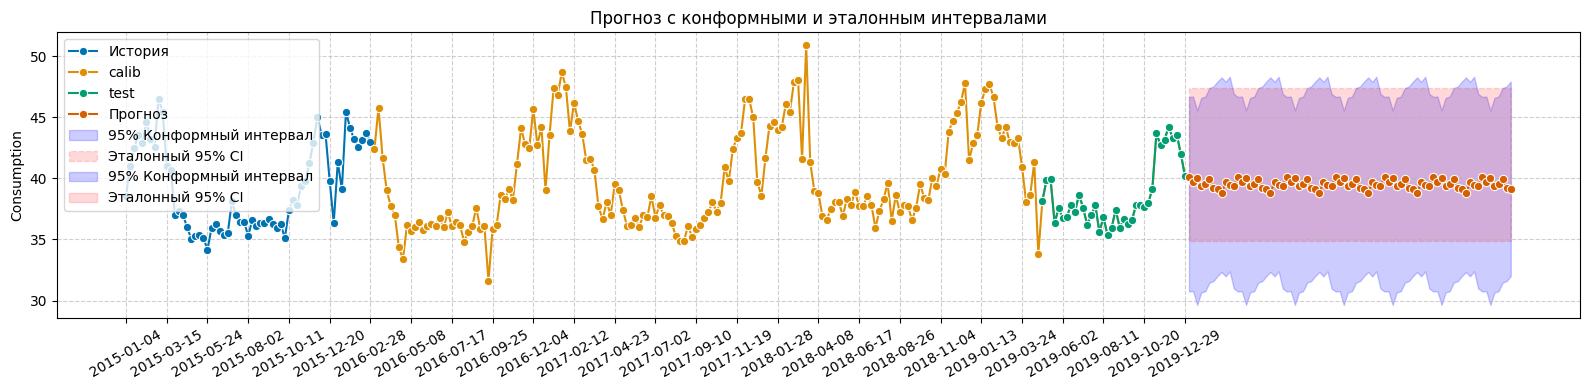

<Figure size 640x480 with 0 Axes>

In [471]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Прогноз на будущее (весь доступный ряд для обучения)
forecaster_full = NaiveForecaster(strategy="mean", sp=SEASON)
forecaster_full.fit(y, fh=fh_future)
y_pred = forecaster_full.predict(fh=fh_future)

# 2. Конформные интервалы (обучение на y_train, калибровка на y_calib)
lower_cp, upper_cp = conformal_prediction_intervals(
    forecaster=NaiveForecaster(strategy="mean", sp=SEASON),
    y_train=y_train,
    y_calib=y_calib,
    fh_test=fh_future,
    alpha=0.05
)

# 3. Эталонный интервал — глобальные квантили всего ряда
ref_lower = y.quantile(0.025)
ref_upper = y.quantile(0.975)

# Преобразуем fh_future в абсолютные даты
future_index = fh_future.to_absolute(y.index)
future_index = fh_future.to_pandas()
# Повторяем эталонные границы для каждого шага прогноза
ref_lower_series = pd.Series([ref_lower] * len(future_index), index=future_index)
ref_upper_series = pd.Series([ref_upper] * len(future_index), index=future_index)

# 1. Строим график через plot_series — получаем fig, ax
fig, ax = plot_series(y_train, y_calib, y_test, y_pred, labels=["История", 'calib', 'test',"Прогноз"])

# 2. Получаем X для последней линии (прогноза)
x_pred = ax.get_lines()[-1].get_xdata()  # ← эталонный источник X

# 3. Заполняем интервалы — ТОЛЬКО .values!
ax.fill_between(
    x_pred,
    lower_cp.values,          # ← обязательно .values
    upper_cp.values,          # ← обязательно .values
    color='blue',
    alpha=0.2,
    label='95% Конформный интервал'
)

ax.fill_between(
    x_pred,
    ref_lower_series.values,  # ← обязательно .values
    ref_upper_series.values,  # ← обязательно .values
    color='red',
    alpha=0.15,
    linestyle='--',
    label='Эталонный 95% CI'
)

# 4. Добавляем вертикальную линию "сегодня"
# ax.axvline(y.index[-1], color='gray', linestyle='--', linewidth=1)

# 5. Легенда и оформление
from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
interval_patches = [
    Patch(color='blue', alpha=0.2, label='95% Конформный интервал'),
    Patch(color='red', alpha=0.15, label='Эталонный 95% CI')
]
ax.legend(handles=handles + interval_patches, loc='best')
plt.title('Прогноз с конформными и эталонным интервалами')
fix_plot(y)
plt.tight_layout()
plt.show()

In [486]:
def conformal_intervals_on_test(forecaster, y_train, y_test, alpha=0.05):
    """
    Строит конформные интервалы для y_test, используя y_train как обучающую часть.
    
    Параметры:
    ----------
    forecaster : sktime forecaster (не обучён!)
    y_train : pd.Series — обучающая часть
    y_test : pd.Series — тестовая часть (уже известна)
    alpha : float — уровень значимости (0.05 → 95% CI)
    
    Возвращает:
    ----------
    y_pred : pd.Series — точечный прогноз на y_test
    lower : pd.Series — нижняя граница
    upper : pd.Series — верхняя граница
    """
    from sktime.forecasting.base import ForecastingHorizon
    
    # Горизонт теста
    fh_test = ForecastingHorizon(y_test.index, is_relative=False)
    
    # Обучаем модель на y_train
    forecaster.fit(y_train, fh=fh_test)
    y_pred = forecaster.predict(fh=fh_test)
    
    # Генерация in-sample ошибок на y_train (скользящим окном)
    residuals = []
    for i in range(len(y_train)):
        if i >= 1:  # минимум 1 точка для прогноза
            temp_forecaster = forecaster.clone()
            temp_forecaster.fit(y_train[:i], fh=[1])
            pred = temp_forecaster.predict(fh=[1]).iloc[0]
            true = y_train.iloc[i]
            residuals.append(abs(true - pred))
    
    if len(residuals) == 0:
        raise ValueError("Недостаточно данных для калибровки")
    
    # Квантиль ошибок
    q = np.quantile(residuals, 1 - alpha)
    
    # Интервалы
    lower = y_pred - q
    upper = y_pred + q
    
    return y_pred, lower, upper

In [487]:
def plot_forecast_with_intervals(y_train, y_test, y_pred, lower, upper, title="Forecast with Conformal Intervals"):
    """
    Визуализация с соблюдением золотого правила:
    - X берётся из ax.get_lines()[-1].get_xdata()
    - Y передаётся как .values
    """
    from sktime.utils.plotting import plot_series
    from matplotlib.patches import Patch
    import matplotlib.pyplot as plt
    
    # Строим график
    fig, ax = plot_series(y_train, y_test, y_pred, labels=["Train", "Test", "Pred"])
    
    # Получаем X для последней линии (прогноза)
    x_pred = ax.get_lines()[-1].get_xdata()
    
    # Заполняем интервал — ТОЛЬКО .values!
    ax.fill_between(
        x_pred,
        lower.values,
        upper.values,
        color='blue',
        alpha=0.2,
        label='Conformal 95% CI'
    )
    
    # Легенда
    handles, labels = ax.get_legend_handles_labels()
    interval_patch = Patch(color='blue', alpha=0.2, label='Conformal 95% CI')
    ax.legend(handles=handles + [interval_patch], loc='best')
    
    # Оформление
    ax.set_title(title)
    try:
        fix_plot(y_train)  # если есть ваша функция
    except:
        pass
    plt.tight_layout()
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sktime/forecasting/naive.py:260: RuntimeWarning: Mean of empty slice
  y_pred = np.nanmean(last_window, axis=0)
/Library/Frameworks/Python.framework/Ver

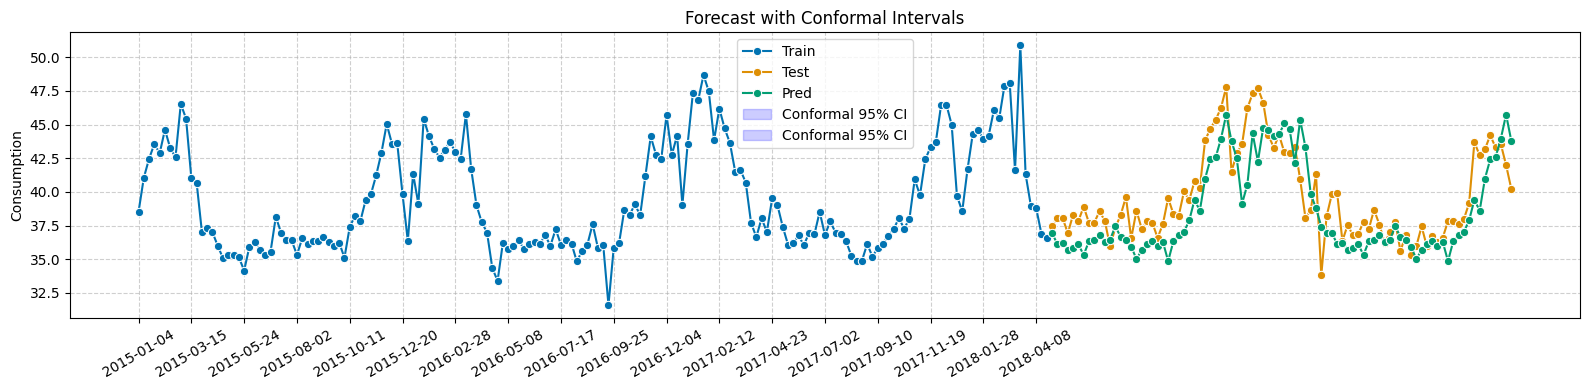

<Figure size 640x480 with 0 Axes>

In [488]:
# Данные
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)

# Получаем интервалы на тесте
y_pred, lower, upper = conformal_intervals_on_test(
    forecaster=forecaster,
    y_train=y_train,
    y_test=y_test,
    alpha=0.05
)

# Визуализация
plot_forecast_with_intervals(y_train, y_test, y_pred, lower, upper)

In [465]:
import numpy as np
import pandas as pd
from sktime.forecasting.base import ForecastingHorizon

def conformal_prediction_intervals(
    forecaster,
    y_train,
    y_calib,
    fh_test,
    alpha=0.05,  # for (1 - alpha) coverage, e.g. alpha=0.05 → 95% CI
):
    """
    Построение конформных интервалов для временного ряда.
    
    Параметры:
    ----------
    forecaster : sktime forecaster
        Базовая модель (уже обучена или будет обучена на y_train).
    y_train : pd.Series
        Обучающая часть ряда.
    y_calib : pd.Series
        Калибровочная часть (должна идти сразу после y_train!).
    fh_test : ForecastingHorizon
        Горизонт прогноза для теста.
    alpha : float
        Уровень значимости (например, 0.05 для 95% интервала).
    
    Возвращает:
    ----------
    lower : pd.Series
        Нижняя граница интервала.
    upper : pd.Series
        Верхняя граница интервала.
    """
    # 1. Обучаем модель на y_train
    forecaster.fit(y_train, fh=fh_test)
    
    # 2. Получаем точечный прогноз на тест
    y_pred = forecaster.predict(fh=fh_test)
    
    # 3. Вычисляем nonconformity scores на калибровочной части
    #    Делаем in-sample прогнозы пошагово
    residuals = []
    calib_index = y_calib.index
    
    for i in range(len(calib_index)):
        # Определяем момент времени
        t = calib_index[i]
        
        # Строим обучающее окно: всё до t
        y_up_to_t = pd.concat([y_train, y_calib[:t][:-1]])  # исключаем саму точку t
        
        # Обучаем временную модель
        temp_forecaster = forecaster.clone()
        temp_forecaster.fit(y_up_to_t, fh=[1])
        
        # Прогнозируем на 1 шаг вперёд
        pred_t = temp_forecaster.predict(fh=[1]).iloc[0]
        true_t = y_calib.iloc[i]
        
        # Ошибка (nonconformity score)
        residuals.append(np.abs(true_t - pred_t))
    
    residuals = np.array(residuals)
    
    # 4. Находим квантиль ошибок
    q = np.quantile(residuals, 1 - alpha)
    
    # 5. Строим интервалы
    lower = y_pred - q
    upper = y_pred + q
    
    return lower, upper

In [466]:
from sktime.forecasting.naive import NaiveForecaster

# Разделение данных (без перемешивания!)
train_end = len(y) // 2
calib_end = train_end + 20

y_train = y[:train_end]
y_calib = y[train_end:calib_end]
y_test  = y[calib_end:]

fh_test = ForecastingHorizon(y_test.index, is_relative=False)

# Модель
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)

# Конформные интервалы
lower, upper = conformal_prediction_intervals(
    forecaster=forecaster,
    y_train=y_train,
    y_calib=y_calib,
    fh_test=fh_test,
    alpha=0.05  # 95% CI
)

# Оценка покрытия
coverage = ((y_test >= lower) & (y_test <= upper)).mean()
print(f"Empirical coverage: {coverage:.3f}")

Empirical coverage: 0.712


           Consumption           
                   0.9           
                 lower      upper
2019-04-28   33.677818  47.374071
2019-05-05   33.072253  46.787747
2019-05-12   33.512245  47.246978
2019-05-19    32.79275  46.546723
2019-05-26   32.743446  46.516659


ValueError: operands could not be broadcast together with shapes (36,) (111,) 

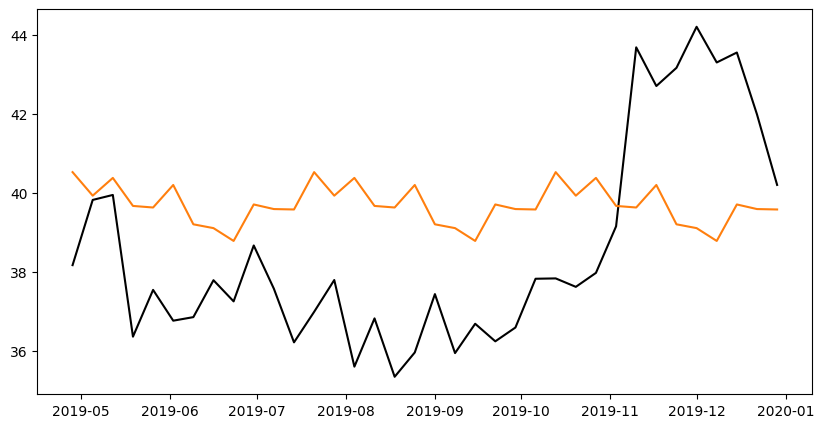

In [467]:
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.conformal import ConformalIntervals
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon
import matplotlib.pyplot as plt

# split
y_train_val, y_test = temporal_train_test_split(y, test_size=36)
fh = ForecastingHorizon(y_test.index, is_relative=False)

# базовый прогнозер
forecaster = NaiveForecaster(strategy="mean", sp=SEASON)

# обёртка для конформных интервалов
conformal_forecaster = ConformalIntervals(
    forecaster=forecaster,
    method="conformal",  # можно попробовать "empirical_residual"
    initial_window=0.3  # первые 30% для калибровки остатков
)

conformal_forecaster.fit(y_train_val)

# предсказание интервалов
pred_int = conformal_forecaster.predict_interval(fh=fh, coverage=0.9)

# pred_int — DataFrame с колонками "lower" и "upper"
print(pred_int.head())

plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, conformal_forecaster.predict(fh=fh), label="Point Forecast")
plt.fill_between(y_test.index, lower, upper, color="orange", alpha=0.3, label="Conformal 90% CI")
plt.legend()
plt.show()

PIT — это диагностический инструмент для оценки калибровки вероятностной модели.
Если прогнозное распределение 
F t(y) правильно калибровано, то величины:
ut=Ft(yt)
должны быть равномерно распределены на [0,1]

На практике:

Для дискретных или квантильных прогнозов PIT аппроксимируется через линейную интерполяцию между квантилями.
Если гистограмма ut имеет U-форму — модель недооценивает дисперсию (интервалы узкие);
Если колоколообразная — переоценивает дисперсию (интервалы широкие);
Равномерность → хорошая калибровка.

In [444]:
pred_int.droplevel(0)

ValueError: Cannot remove 1 levels from an index with 1 levels: at least one level must be left.

In [432]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.conformal import ConformalIntervals
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon
from sktime.utils.plotting import plot_series

# ------------------------------
# Параметры
# ------------------------------
SEASON = 12  # пример сезонности
TEST_SIZE = 0.34

# ------------------------------
# Разбиваем данные
# ------------------------------
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

# ------------------------------
# Forecasting Horizon
# ------------------------------
fh = ForecastingHorizon(y_test.index, is_relative=False)

# ------------------------------
# NaiveForecaster
# ------------------------------
forecaster = NaiveForecaster(strategy="mean", sp=min(SEASON, len(y_train)))
forecaster.fit(y_train)
y_pred = forecaster.predict(fh=fh)

# ------------------------------
# ConformalIntervals
# ------------------------------
conformal_forecaster = ConformalIntervals(forecaster, method="conformal")
conformal_forecaster.fit(y_train)
pred_int = conformal_forecaster.predict_interval(fh=fh, coverage=0.9)

# ------------------------------
# Преобразуем MultiIndex в плоский DataFrame
# ------------------------------
# Просто берём все нижние и верхние границы для каждого fh
lower = pred_int["lower"].droplevel(0)
upper = pred_int["upper"].droplevel(0)

# Если fh индексами совпадают с y_test.index, можно просто:
lower.index = y_test.index
upper.index = y_test.index

# ------------------------------
# Построение графика
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train.values, label="Train")
plt.plot(y_test.index, y_test.values, label="Test")
plt.plot(y_test.index, y_pred.values, label="Point Forecast")
plt.fill_between(y_test.index, lower.values, upper.values, color="orange", alpha=0.3, label="Conformal 90% CI")
plt.legend()
plt.title("Naive Forecast with Conformal Intervals (No MultiIndex)")
plt.show()


KeyError: 'lower'

In [433]:
# fh — ForecastingHorizon
pred_int = conformal_forecaster.predict_interval(fh=fh, coverage=0.9)

# создаём плоские серии для нижней и верхней границы
# level 0 = fh, level 1 = bound ('lower'/'upper')
lower = pred_int.xs("lower", axis=1, level=1)
upper = pred_int.xs("upper", axis=1, level=1)

# в случае если fh — не числа, а таймстемпы, подгоняем индекс
lower.index = y_test.index
upper.index = y_test.index

# Построение графика
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train.values, label="Train")
plt.plot(y_test.index, y_test.values, label="Test")
plt.plot(y_test.index, y_pred.values, label="Point Forecast")
plt.fill_between(y_test.index, lower.values[:,0], upper.values[:,0], 
                 color="orange", alpha=0.3, label="Conformal 90% CI")
plt.legend()
plt.title("Naive Forecast with Conformal Intervals")
plt.show()


KeyError: 'lower'

- Берем прогнозное распределение для 
yt(квантили или CDF).
- Берем реальное наблюдаемое значение 
yt.
- Определяем, какая доля прогнозного распределения меньше или равна 
yt.
- Это число — PIT value для t.


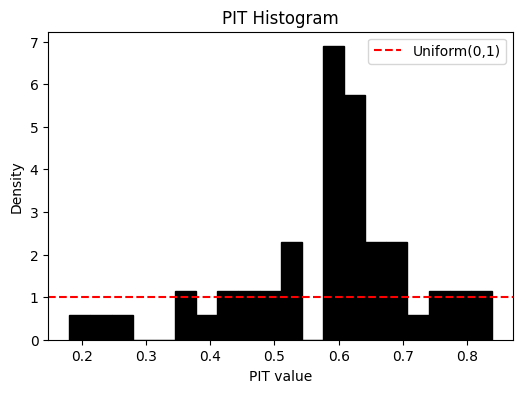

In [376]:
def compute_pit(y_true, pred_quantiles):
    """
    Считает PIT (Probability Integral Transform) для прогнозов квантилей.
    
    y_true: pd.Series или np.ndarray (с индексом времени)
    pred_quantiles: pd.DataFrame
        index   = timestamps / fh
        columns = quantile levels (float)
    """
    
    # Если y_true ndarray — делаем Series с индексом из pred_quantiles
    if isinstance(y_true, np.ndarray):
        y_true = pd.Series(y_true, index=pred_quantiles.index[:len(y_true)])
    
    if not isinstance(y_true, pd.Series):
        raise TypeError("y_true must be pd.Series with a time index")
    
    # Если колонки MultiIndex — берём последний уровень
    if isinstance(pred_quantiles.columns, pd.MultiIndex):
        pred_quantiles.columns = pred_quantiles.columns.get_level_values(-1)
    
    # Пересечение индексов
    common_index = y_true.index.intersection(pred_quantiles.index)
    y = y_true.loc[common_index].values
    q = pred_quantiles.loc[common_index].values
    alphas = pred_quantiles.columns.astype(float).values
    
    pits = np.zeros(len(y))
    for t in range(len(y)):
        pits[t] = np.interp(
            y[t],
            q[t],
            alphas,
            left=0.0,
            right=1.0
        )
    
    return pits

pits = compute_pit(y, pred_quantiles)

plt.figure(figsize=(6,4))
plt.hist(pits, bins=20, density=True, edgecolor="black")
plt.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
plt.xlabel("PIT value")
plt.ylabel("Density")
plt.title("PIT Histogram")
plt.legend()
plt.show()


# plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
# fix_plot(y)

In [373]:
print(pred_quantiles.columns)

Index([0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98], dtype='float64')


In [369]:
from sktime.forecasting.conformal import ConformalIntervals



# Оборачиваем в ConformalIntervals
conformal_forecaster = ConformalIntervals(forecaster, initial_window=50)

# Обучение и прогноз
conformal_forecaster.fit(y_train)
y_pred_interval = conformal_forecaster.predict_interval(fh=fh, coverage=0.95)

IndexError: index -1 is out of bounds for axis 0 with size 0

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6973: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/axes/_axes.py:6974: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

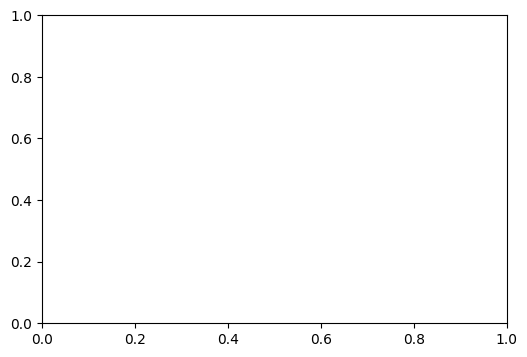

In [367]:
def compute_pit(y_true, pred_quantiles):
    """
    y_true: pd.Series с временным индексом
    pred_quantiles: pd.DataFrame с колонками квантилей или MultiIndex
    """
    if not isinstance(y_true, pd.Series):
        raise TypeError("y_true must be pd.Series with a time index")
    
    # пересечение по индексу времени
    common_index = y_true.index.intersection(pred_quantiles.index)
    
    if len(common_index) == 0:
        raise ValueError("Нет пересечения индексов y_true и pred_quantiles")
    
    y = y_true.loc[common_index].values
    
    q = pred_quantiles.loc[common_index].values

    # вытягиваем квантили
    if isinstance(pred_quantiles.columns, pd.MultiIndex):
        alphas = pred_quantiles.columns.get_level_values(-1).astype(float).values
    else:
        alphas = pred_quantiles.columns.astype(float).values

    # проверка на размеры
    if q.shape[1] != len(alphas):
        raise ValueError(f"Количество колонок pred_quantiles ({q.shape[1]}) "
                         f"не совпадает с количеством alphas ({len(alphas)})")

    pits = np.zeros(len(y))
    for t in range(len(y)):
        pits[t] = np.interp(
            y[t],
            q[t],
            alphas,
            left=0.0,
            right=1.0
        )
    return pits


def plot_pit_histogram(pits, bins=20, title="PIT Histogram"):
    plt.figure(figsize=(6, 4))
    plt.hist(pits, bins=bins, density=True, edgecolor="black")
    plt.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
    plt.xlabel("PIT value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


forecaster.fit(y_train, fh=fh)

# квантили (важно: широкий набор)
alphas = [0.02, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.98]
pred_quantiles = forecaster.predict_quantiles(fh=fh, alpha=alphas)

# считаем PIT
pits = compute_pit(y_test, pred_quantiles)

# строим гистограмму
plot_pit_histogram(pits, title="PIT Histogram (Expanding Window)")

In [368]:
pred_quantiles

Consumption                                        
                  0.02 0.05 0.10 0.25 0.50 0.75 0.90 0.95 0.98
2018-04-29         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-05-06         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-05-13         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-05-20         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-05-27         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-06-03         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-06-10         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-06-17         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-06-24         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-07-01         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-07-08         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-07-15         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-07-22         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-07-29         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-08-05         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-08-12         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-08-19         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-08-26         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-09-02         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-09-09         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-09-16         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-09-23         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-09-30         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-10-07         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-10-14         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-10-21         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-10-28         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-11-04         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-11-11         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-11-18         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-11-25         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-12-02         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-12-09         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-12-16         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-12-23         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2018-12-30         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-01-06         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-01-13         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-01-20         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-01-27         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-02-03         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-02-10         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-02-17         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-02-24         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-03-03         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-03-10         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-03-17         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-03-24         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-03-31         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-04-07         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-04-14         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-04-21         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2019-04-28         NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

## Шаблоны создания моделей предсказания

Библиотека `sktime` поддерживает ряд продвинутых шаблонов композиции для создания моделей прогноза из нескольких компонентов. [Такими методами могут быть следующие](https://www.sktime.net/en/latest/examples/01_forecasting.html#3.-Advanced-composition-patterns---pipelines,-reduction,-autoML,-and-more).

* [__Редукция__](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.make_reduction.html)  - построение прогноза из оценок более "простых" фреймровков работы с моделями машинного обучения, таких как регрессоры [`scikit-learn`](https://scikit-learn.org/). Приемами редукции являются табуляция с помощью скользящего окна - так называемая "стратегия прямой редукции".
* [__Тюнинг моделей__](https://machinelearningmastery.com/how-to-grid-search-deep-learning-models-for-time-series-forecasting/) - определение значений гиперпараметров модели прогноза на основе данных. Частым примером является `GridSearch` поиск на временно скользящем оконе разделения на тренировку/тестирование.
* [__Конвейеризация__](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.TransformedTargetForecaster.html) - объединение нескольких техник, например предобработки с моделью прогноза для получения единого предсказателя. Частым примером предобработки является удаление тренда (`detrender`)  и сезона `deseasonalizer` с последующим прогнозированием. Может быть произведено разложение временного ряда, например "STL forecaster".
* [__AutoML__](https://winedarksea.github.io/AutoTS/build/html/source/tutorial.html), также известный как автоматизированный выбор модели - использование автоматизированных стратегий настройки для выбора не только гиперпараметров, но и подходов прогнозирования. Распространенным примером является выбор методов в режиме реального времени.
* [__Ансамблирование моделей__](https://github.com/business-science/modeltime.ensemble) - набор методо для объеденения результатов нескольких методов.



<!-- Для наглядности все приведенные ниже оценщики будут представлены в рамках базового рабочего процесса прогнозирования, хотя они также поддерживают расширенные рабочие процессы прогнозирования и оценки в рамках единого интерфейса aeon (см. раздел 1).

Для использования в других рабочих процессах просто замените "блок спецификации форкастера" ("forecaster=") на блок спецификации форкастера в примерах, представленных ниже. -->


<!-- aeon supports a number of advanced composition patterns to create forecasters out of simpler components:
* Reduction - building a forecaster from estimators of “simpler” scientific types, like scikit-learn regressors. A common example is feature/label tabulation by rolling window, aka the “direct reduction strategy”.
* Tuning - determining values for hyper-parameters of a forecaster in a data-driven manner. A common example is grid search on temporally rolling re-sampling of train/test splits.
* Pipelining - concatenating transformers with a forecaster to obtain one forecaster. A common example is detrending and deseasonalizing then forecasting, an instance of this is the common “STL forecaster”.
* AutoML, also known as automated model selection - using automated tuning strategies to select not only hyper-parameters but entire forecasting strategies. A common example is on-line multiplexer tuning. -->

### Редукция временного ряда

Начнем с пункта <b>Редукция временного ряда</b>. Редукция предоставляет собой мета-метод, который позволяет использовать любой оценочный инструмент, например `scikit-learn` или совместимых фреймворков для прогнозирования. Как правило в таких фреймворках требуется табличная модальность данных. В случае временного ряда это может означать что каждый семпл теперь будет считаться значением столбца таблицы.

Посмотрим на на работу редукции на примере стратегии <b><code>recursive reduction </code></b>. Принцип работы показана ниже.  Принцип заключается в движении по меткам ряда окна, размером с тренировочную выборку, таким образом, что каждый следующий семпл ответ связан с положением окна. Данная техника может быть реализована в рамках  функции `make_reduction`. Отметим, что в общем случае [данная функция имеет и другие режимы редукции](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.make_reduction.html) можно найти в спраке. Другими режимами могут быть `direct`, и `multioutput`. 

<img src="https://www.cienciadedatos.net/images/transform_timeseries.gif" width = 500px>

В примере мы определим стратегию редукции к сформированной таблице для  регрессора `k-nearest neighbors` (`sklearn KNeighborsRegressor`). Режим редукции - рекурсивный. 

> Отметим, что на самом деле есть некоторые [различия](https://www.sktime.net/en/latest/examples/01a_forecasting_sklearn.html) между задачами регрессии (типичными для пакета `sklearn`) и задачами предсказания временных рядов. \
> Также отметим отдельную возможность решения задач регрессии в рамках пакетов для предсказания [временных рядов](https://www.aeon-toolkit.org/en/latest/examples/regression/regression.html).
> Дополнительно стоит указать на формальную возможносать решения задач [регрессии ВР](https://www.kaggle.com/code/robikscube/tutorial-time-series-forecasting-with-xgboost) без использования [сторонних библиотек](https://machinelearningmastery.com/random-forest-for-time-series-forecasting/).


<!-- aeon provides a meta-estimator that allows the use of any scikit-learn estimator for forecasting.

modular and compatible with scikit-learn, so that we can easily apply any scikit-learn regressor to solve our forecasting problem,

parametric and tuneable, allowing us to tune hyper-parameters such as the window length or strategy to generate forecasts

adaptive, in the sense that it adapts the scikit-learn’s estimator interface to that of a forecaster, making sure that we can tune and properly evaluate our model

Example: we will define a tabulation reduction strategy to convert a k-nearest neighbors regressor (sklearn KNeighborsRegressor) into a forecaster. The composite algorithm is an object compliant with the aeon forecaster interface (picture: big robot), and contains the regressor as a parameter accessible component (picture: little robot). In fit, the composite algorithm uses a sliding window strategy to tabulate the data, and fit the regressor to the tabulated data (picture: left half). In predict, the composite algorithm presents the regressor with the last observed window to obtain predictions (picture: right half). -->

In [59]:
from sklearn.utils._testing import set_random_state

sMAPE = 0.059


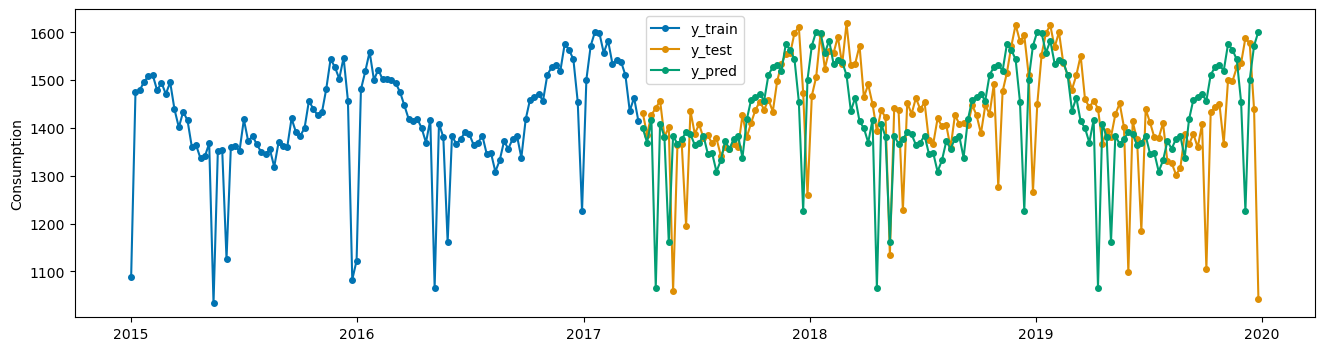

In [62]:
from sklearn.neighbors import KNeighborsRegressor
from sktime.forecasting.compose import make_reduction

regressor = KNeighborsRegressor(n_neighbors=1)
forecaster = make_reduction(regressor, window_length=52, strategy="recursive")

fh = ForecastingHorizon(y_test.index, is_relative=False)

forecaster.fit(y_train)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Отметим, что экзогенные факторы и мультимодальные (многокомпонентные) ряды могут также быть сведены к табличному виду.

[Экзогенные факторы](https://cienciadedatos.net/documentos/py27-time-series-forecasting-python-scikitlearn.html#Machine-learning-for-forecasting) могут быть добавлены [в виде дополнительного столбца данных](https://joaquinamatrodrigo.github.io/skforecast/0.4.3/notebooks/autoregresive-forecaster-exogenous.html).
<img src="https://skforecast.org/0.5.0/img/matrix_transformation_with_exog_variable.png" width = 500px>

Отметим также, что многокомпонентные ряды также могут быть представлены [в виде нескольких таблиц](https://joaquinamatrodrigo.github.io/skforecast/0.11.0/user_guides/dependent-multi-series-multivariate-forecasting.html).
<!-- <img src="https://skforecast.org/0.5.0/img/forecaster_multivariate_train_matrix_diagram.png" width = 500px> -->


Старатегии рекурсси могут быть разилчиными, например: [`direct`, `recursive` или `multioutput`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.make_reduction.html).

sMAPE = 0.033


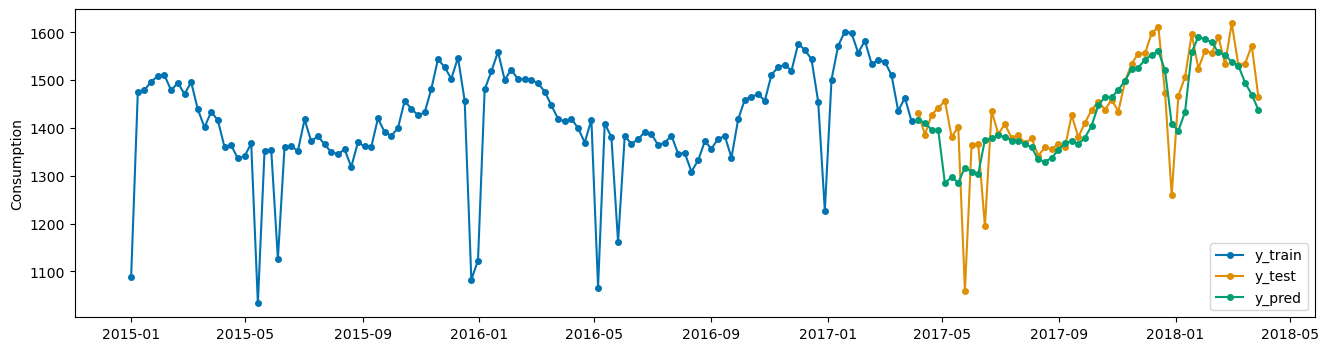

In [63]:
# from sklearn.ensemble import HistGradientBoostingRegressor
regressor  = KNeighborsRegressor(n_neighbors=3) #HistGradientBoostingRegressor()
forecaster = make_reduction(regressor, strategy="direct", window_length=52)
# fh = ForecastingHorizon(y_test.index, is_relative=False)
forecaster.fit(y_train.values, fh =np.arange(52)+1)
y_pred = forecaster.predict()

y_pred = pd.Series(y_pred.squeeze())
y_pred.index = y_test.index[:52]

plot_series(y_train, y_test[:52], y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values[:52]):.3f}')

В  следующих двух разделах будет также показано как можно встроить пайплайны с использованием редукции временных рядов в продвинутые модели предсказания. Также отметим что существуют и более развернутые фреймворки [адаптации табличных фреймворков к задачам временных рядов](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost.html). Кроме того некоторый функционал по предсказанию временных рядов можно найти и [в стандартных табличных фреймворках](https://scikit-learn.org/stable/auto_examples/applications/plot_time_series_lagged_features.html).

### Построение конвейера предсказаний

Рассмотрим возможность создания <b>конвейеров (`pipeline`)</b> как единых моделей предсказания. Библиотека `sktime` предоставляет особый  тип конвейера для  моделей предсказания  `TransforemdTargetForecaster`. Однако, это не единственный тип конвейеров [в фреймоврке](https://github.com/sktime/sktime/blob/main/examples/03_transformers.ipynb). Конвейер связывает произвольное количество преобразований([transforms](https://www.aeon-toolkit.org/en/stable/examples/transformations/transformations.html#Pipelines-with-transformers)) или других вспомогательных операций с моделью прогноза. Преобразования могут быть как предобработкой, так и постобработкой результатов прогноза временного ряда. Пример конвейера с моделью и предварительными преобразованиями можно увидеть ниже. 

<!-- aeon provides a generic pipeline object for this kind of composite modelling, the TransforemdTargetForecaster. It chains an arbitrary number of transformations with a forecaster. The transformations can either be pre-processing transformations or a post-processing transformations. An example of a forecaster with pre-processing transformations can be seen below -->

In [64]:
from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
from sktime.forecasting.trend import PolynomialTrendForecaster

sMAPE = 0.043


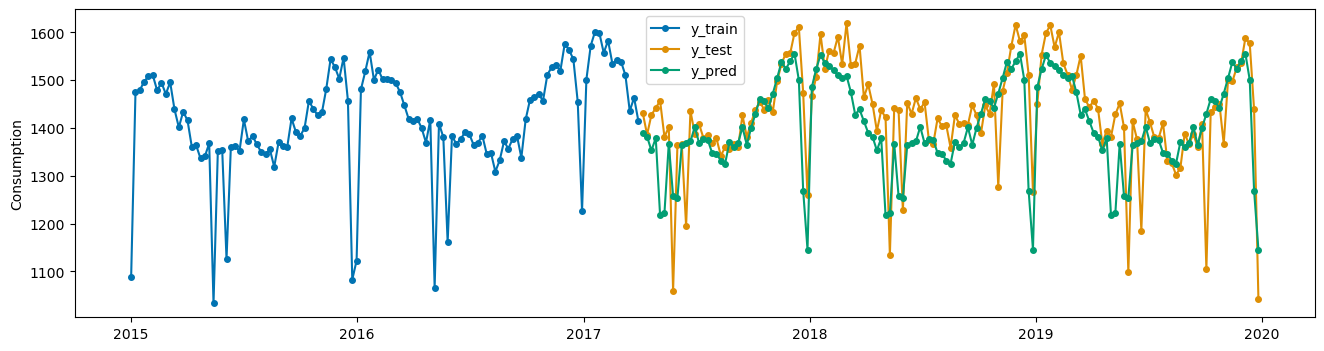

In [66]:
forecaster = TransformedTargetForecaster(
    [
        ("deseasonalize", Deseasonalizer(model="multiplicative", sp=52)),
        ("detrend", Detrender(forecaster=PolynomialTrendForecaster(degree=0))),
        ("forecast", NaiveForecaster(strategy='mean',sp=52)),
    ]
)

fh = ForecastingHorizon(y_test.index, is_relative=False)

forecaster.fit(y_train)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Для того, чтобы более верно понять [суть конвейера](https://github.com/sktime/sktime/blob/main/examples/03b_forecasting_transformers_pipelines_tuning.ipynb) создадим ешл аналог без использования объекта `TransformedTargetForecaster`.

In [38]:
from sktime.transformations.series.detrend import Deseasonalizer, Detrender

detrender = Detrender(forecaster=PolynomialTrendForecaster(degree=0))
deseasonalizer = Deseasonalizer(model="multiplicative", sp=52)
forecaster = NaiveForecaster(strategy='mean',sp=52)

# fit_transform
y_train_1 = deseasonalizer.fit_transform(y_train)
y_train_2 = detrender.fit_transform(y_train_1)

# fit
forecaster.fit(y_train_2)

# predidct
y_pred_2 = forecaster.predict(fh)

# inverse_transform
y_pred_1 = detrender.inverse_transform(y_pred_2)
y_pred = deseasonalizer.inverse_transform(y_pred_1)

В данном примере видно наличие двух операций, заменяемых одной в составе конвейера: прямое преобразование (выполняемое в качестве предобработки) и обратное преобразование (постобработке).  Кроме того сама структура преобразования кажется куда менее читаемой, чем при использовании конвейера. 

Ниже мы проверим корректность работы ручного аналога

sMAPE = 0.043


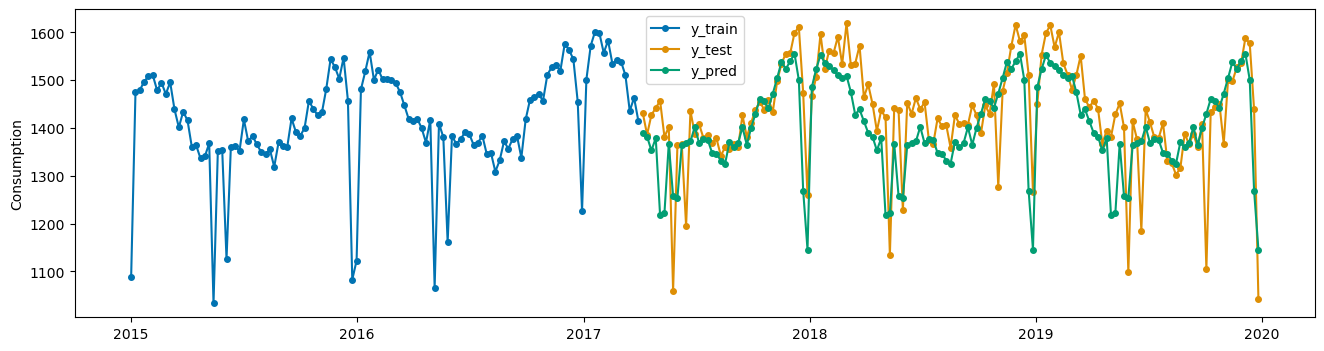

In [67]:
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

На самом деле реализация конвейера может быть минималистична записана [через оператор`*`](https://github.com/sktime/sktime/blob/main/examples/03a_transformers_cheat_sheet.ipynb). Более того  в конвейер могут быть добавлены и дополнительные операции, например при помощи класса [`FunctionTransformer`](https://www.sktime.net/en/v0.23.1/api_reference/auto_generated/sktime.transformations.series.func_transform.FunctionTransformer.html).

sMAPE = 0.043


  Покажем что это PIPELINE


TransformedTargetForecaster(steps=[Deseasonalizer(model='multiplicative',
                                                  sp=52),
                                   NaiveForecaster(sp=52, strategy='mean'),
                                   FunctionTransformer(func=<function <lambda> at 0x000002361285AFC0>)])

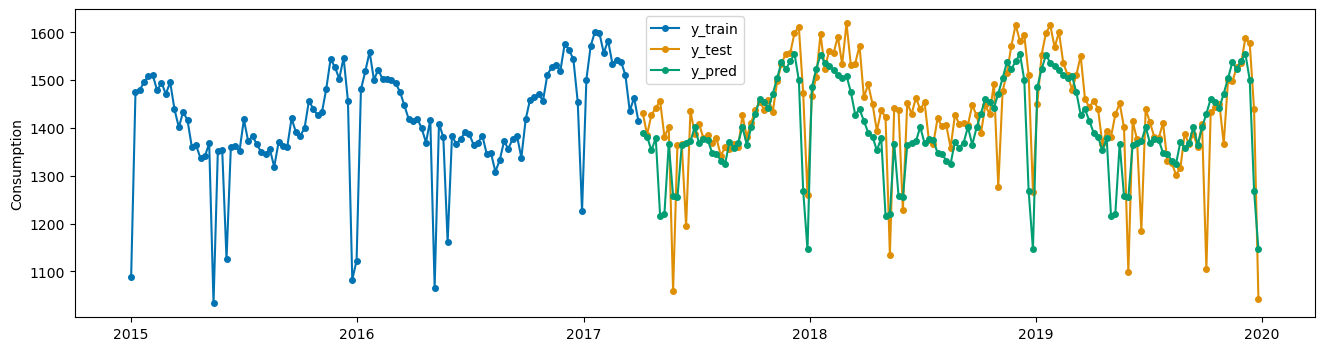

In [68]:
from sktime.transformations.series.func_transform import FunctionTransformer

forecaster = Deseasonalizer(model="multiplicative", sp=52) *\
             NaiveForecaster(strategy="mean",sp=52) *\
             FunctionTransformer(lambda y: y.round())

forecaster.fit(y_train)

fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

print('\n\n  Покажем что это PIPELINE')
forecaster

Так как конвейеры могут быть достаточно сложными отметим что иногда полезно показать параметры итоговой модели


In [41]:
forecaster.get_params()

{'steps': [Deseasonalizer(model='multiplicative', sp=52),
  NaiveForecaster(sp=52, strategy='mean'),
  FunctionTransformer(func=<function <lambda> at 0x00000230E4361DA0>)],
 'Deseasonalizer': Deseasonalizer(model='multiplicative', sp=52),
 'NaiveForecaster': NaiveForecaster(sp=52, strategy='mean'),
 'FunctionTransformer': FunctionTransformer(func=<function <lambda> at 0x00000230E4361DA0>),
 'Deseasonalizer__model': 'multiplicative',
 'Deseasonalizer__sp': 52,
 'NaiveForecaster__sp': 52,
 'NaiveForecaster__strategy': 'mean',
 'NaiveForecaster__window_length': None,
 'FunctionTransformer__X_type': None,
 'FunctionTransformer__check_inverse': True,
 'FunctionTransformer__func': <function __main__.<lambda>(y)>,
 'FunctionTransformer__inv_kw_args': None,
 'FunctionTransformer__inverse_func': None,
 'FunctionTransformer__kw_args': None}

Отдельно отеметим возможность упращения ряда алгоритмов при помощи конвейеров. Эта возможность уже упомяналась в работе `ARIMA`. Однако тут она будет полезна в смысле дискурса.

sMAPE = 0.047


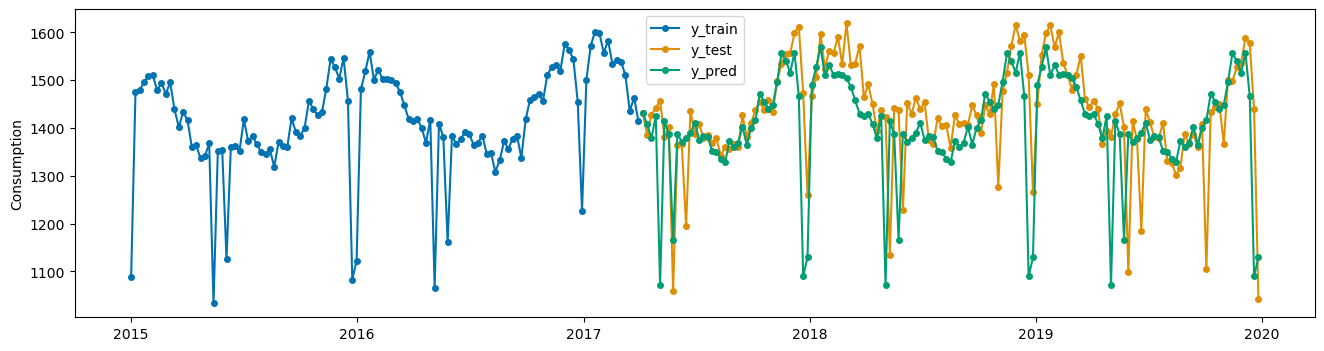

In [69]:
from sktime.forecasting.sarimax import SARIMAX
forecaster = TransformedTargetForecaster(
    [
        ("deseasonalise", Deseasonalizer(model="multiplicative", sp=52)),
        ("forecast", SARIMAX(order=(1, 0, 0),
                             seasonal_order=(0, 0, 0, 0),),
        ),
    ]
)

forecaster.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Можно сравнить результат выше по сложности с тем, какой бы он был без выделения сезонности. 

Также отдельно стоит упомянуть возможность создания авторегрессионных конвейеров с использованием сторонних алгоритмов машинного обучения. Посмотрим на такой пример для градиентного бустинга.

In [70]:
import xgboost as xgb

sMAPE = 0.050


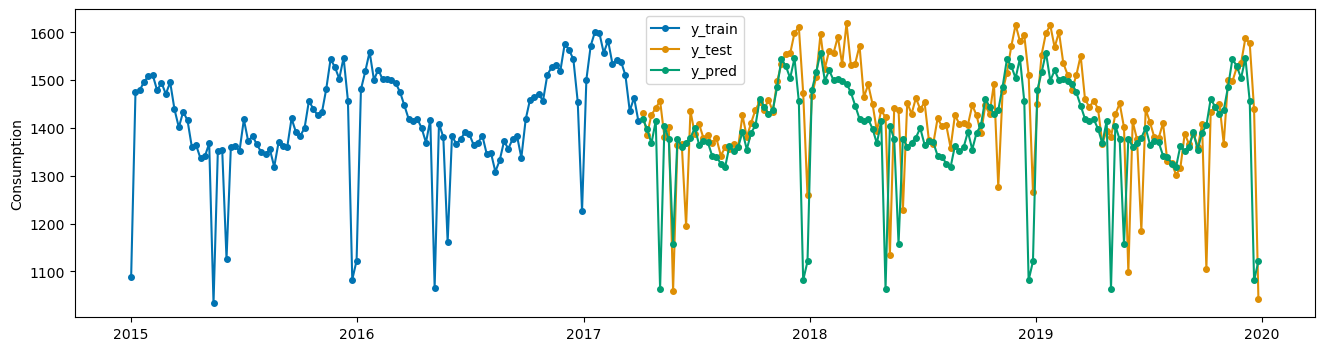

In [71]:
regressor = xgb.XGBRegressor(verbose = -1)
  
forecaster = TransformedTargetForecaster(
    [
        ("deseasonalise", Deseasonalizer(model="multiplicative", sp=52)),
        ("forecast", make_reduction(regressor, window_length=1, strategy="recursive"),
        ),
    ]
)

forecaster.fit(y_train)
fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Рассмотрим еще примеры полезных трюков в конвейере

sMAPE = 0.063


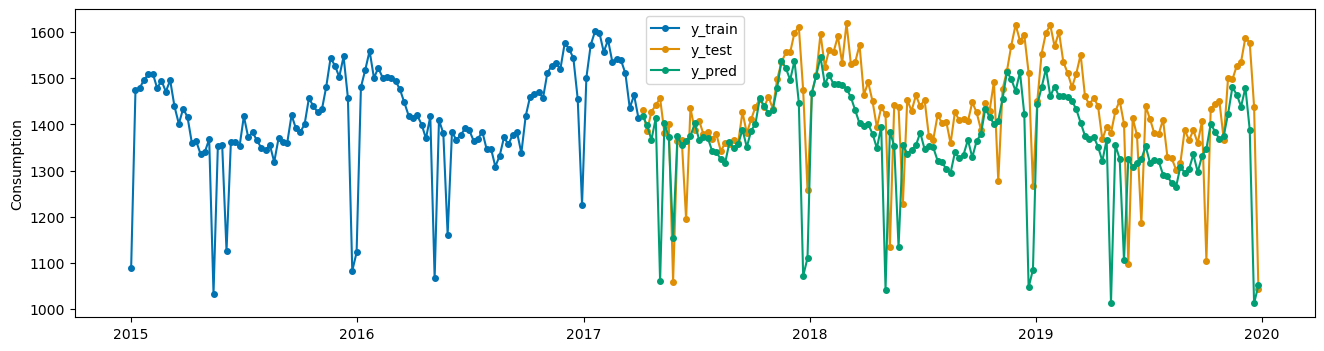

In [72]:
from sktime.transformations.series.difference import Differencer
from sktime.forecasting.trend import TrendForecaster
from sktime.transformations.series.detrend import Deseasonalizer

forecaster = Differencer(lags=1) * Deseasonalizer(sp=52) * TrendForecaster()


forecaster.fit(y_train)

fh = ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)
# y_pred = pd.Series(y_pred)
# y_pred.index = y_test.index
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])

print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

### Тонкая настройка моделей предсказания

Для [<b>тюинига</b>](https://github.com/sktime/sktime/blob/main/examples/03b_forecasting_transformers_pipelines_tuning.ipynb) выбранных моделей предсказания может быть использован ряд автоматизированных методов отбора параметров, например такой подходы как [`ForecastingGridSearchCV`](https://sktime-backup.readthedocs.io/en/latest/api_reference/auto_generated/sktime.forecasting.model_selection.ForecastingGridSearchCV.html). 

Подход `ForecastingGridSearchCV` (и другие тюнеры) строятся из модели для настройки методами кросс-валидации по сетке значений параметров (подобно `scikit-learn`). Также указываются и параметры, специфичные для стратегии настройки. Также для использования этого метода нужно определится со стратегией обучения. Например `SlidingWindowSplitter`. В данном примере попробуем для этой стратегии задать не равнозначными начальное окон и скользящее окон.


In [73]:
path_ts = 'de_data.csv'
df = pd.read_csv(path_ts, parse_dates=['Date'], index_col="Date")
y = df.Consumption.asfreq('7d')

TEST_SIZE = int(0.55*y.size)
y_train, y_test = temporal_train_test_split(y, test_size=TEST_SIZE)

In [74]:
from sklearn.neighbors import KNeighborsRegressor
from sktime.forecasting.compose import make_reduction
from sktime.forecasting.model_selection import (
    ForecastingGridSearchCV,
    SlidingWindowSplitter,
)

(<Figure size 1600x480 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

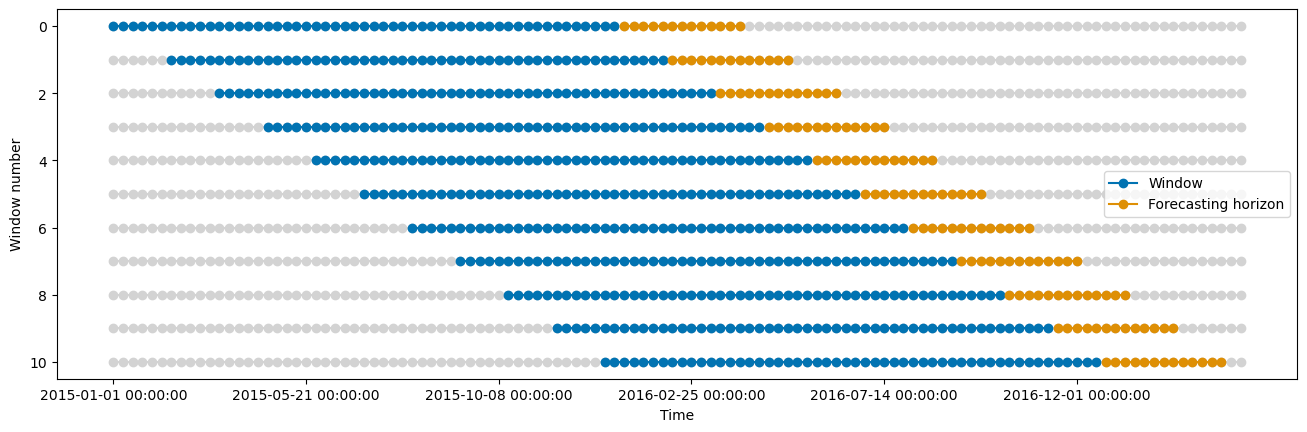

In [80]:
forecaster = NaiveForecaster(sp=52)

param_grid = {"sp": [13, 26, 52]}

cv = SlidingWindowSplitter(initial_window=int(len(y_train.values) * 0.45), step_length=5, window_length=52, fh=1+np.arange(13))

gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid
)

plot_windows(cv,y_train)

Посмотрим на выбор модели

In [81]:
gscv.fit(y_train.values)
gscv.best_params_

{'sp': 52}

Отметим то, как бы выглядило растущее окно `ExpandingWindowSplitter`.

{'sp': 52}


(<Figure size 1600x480 with 1 Axes>,
 <Axes: xlabel='Time', ylabel='Window number'>)

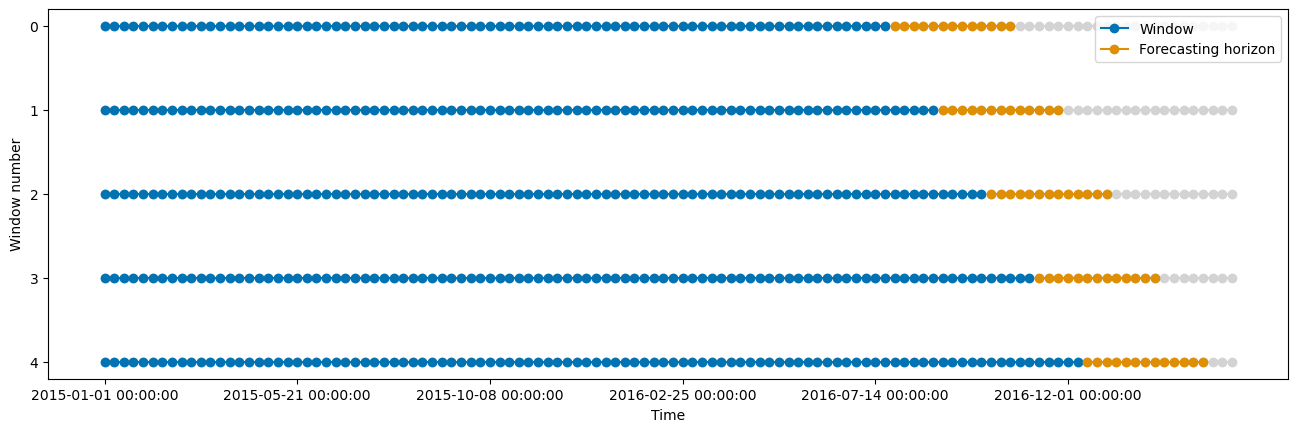

In [82]:
fh=1+np.arange(52)
cv = ExpandingWindowSplitter(initial_window=int(len(y_train.values) * 0.7), fh=np.arange(13)+1,  step_length=5)

gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid,
)
gscv.fit(y_train.values)
print(gscv.best_params_)

plot_windows(cv,y_train)

Все алгоритмы настройки в aeon позволяют пользователю задать скор оценки параметров(`score`); для прогнозирования по умолчанию используется средняя абсолютная процентная ошибка (`MeanAbsolutePercentageError`). Оценка может быть задана с помощью аргумента `score`. Зададим аргумент `MeanSquaredPercentageError`. Результат будем теперь смотреть не только как лучший из сетки поиска, но как всю сводку. Для этого используетм  метод `cv_results_`.

In [83]:
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError, MeanSquaredPercentageError

forecaster = NaiveForecaster(sp=52)

param_grid = {"strategy" : ["last", "mean", "drift"], "window_length":[None,52]}

cv = ExpandingWindowSplitter(initial_window=int(len(y_train.values) * 0.5), fh=np.arange(52)+1)

gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid, scoring=MeanSquaredPercentageError()
)

gscv.fit(y_train.values)
gscv.cv_results_.sort_values(by='mean_test_MeanSquaredPercentageError')

,mean_test_MeanSquaredPercentageError,mean_fit_time,mean_pred_time,params,rank_test_MeanSquaredPercentageError
0,0.006192,0.018425,0.243428,"{'strategy': 'last', 'window_length': None}",2.0
1,0.006192,0.015115,0.246570,"{'strategy': 'last', 'window_length': 52}",2.0
3,0.006192,0.015628,0.018392,"{'strategy': 'mean', 'window_length': 52}",2.0
2,0.006318,0.021329,0.015992,"{'strategy': 'mean', 'window_length': None}",4.0
5,0.009402,0.098890,0.013734,"{'strategy': 'drift', 'window_length': 52}",5.0
4,0.029827,0.097705,0.010954,"{'strategy': 'drift', 'window_length': None}",6.0


Помимо традиционных решений для метрик возможно использование и вероятностных метрик

In [84]:
from sktime.performance_metrics.forecasting.probabilistic import PinballLoss

forecaster = NaiveForecaster(sp=52)

param_grid = {"strategy" : ["last", "mean", "drift"], "window_length":[None,52]}

cv = ExpandingWindowSplitter(initial_window=int(len(y_train.values) * 0.5), fh=np.arange(52)+1,  step_length=20)

gscv = ForecastingGridSearchCV(
    forecaster, strategy="refit", cv=cv, param_grid=param_grid, scoring=PinballLoss()
)

gscv.fit(y_train.values, fh=np.arange(52)+1,)


ForecastingGridSearchCV(cv=ExpandingWindowSplitter(fh=array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52]),
                                                   initial_window=59,
                                                   step_length=20),
                        forecaster=NaiveForecaster(sp=52),
                        param_grid={'strategy': ['last', 'mean', 'drift'],
                                    'window_length': [None, 52]},
                        scoring=PinballLoss())

In [53]:
gscv.cv_results_.sort_values(by='mean_test_PinballLoss')

,mean_test_PinballLoss,mean_fit_time,params,rank_test_PinballLoss
2,15.524876,0.003176,"{'strategy': 'mean', 'window_length': None}",1.0
0,16.808656,0.002652,"{'strategy': 'last', 'window_length': None}",2.5
1,16.808656,0.002543,"{'strategy': 'last', 'window_length': 52}",2.5
5,20.300794,0.020158,"{'strategy': 'drift', 'window_length': 52}",4.0
4,26.399831,0.025202,"{'strategy': 'drift', 'window_length': None}",5.0
3,NaN,0.002644,"{'strategy': 'mean', 'window_length': 52}",NaN


In [85]:
gscv.predict_interval().head(3)

0             
             0.9             
           lower        upper
118  1139.447092  1640.069908
119  1131.358592  1631.981408
120  1102.675092  1603.297908

sMAPE = 0.043


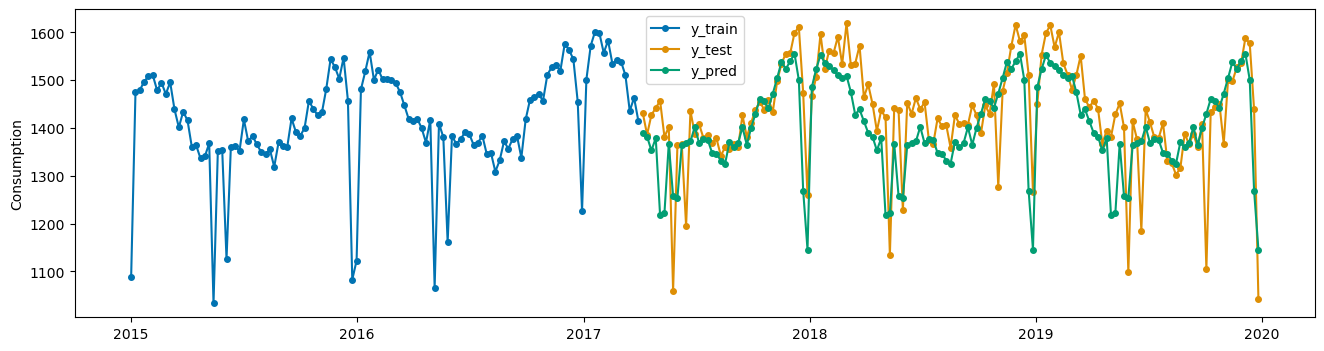

In [86]:
fh = 1+np.arange(len(y_test))
y_pred = gscv.predict(fh).squeeze()
y_pred = pd.Series(y_pred)
y_pred.index = y_test.index
plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Отметим что часто настройка необходима не только для отдельных предсказтелей, но и для [конвейеров предказания](https://github.com/sktime/sktime-tutorial-ODSC-Europe-2023/blob/main/notebooks/04_feateng_pipe_tune.ipynb). Эти примеры мы покажем ниже.

>Процедура настройки может занимать досточно много времени. Поэтому в ряде случаев может быть разделена на два этпа.  На первом этапе используйте стратегию <tt>без refit</tt> для первоначального поиска пространства гиперпараметров потенциального интереса (чтобы сузить диапазон значений). Затем сосредоточьтесь на выявленной области интереса и примените индивидуальную <tt>стратегию обратного тестирования</tt>, соответствующую конкретным требованиям варианта использования моделей.

Также важно указать, что помимо рассмотренного [`ForecastingGridSearchCV`](https://www.sktime.net/en/v0.28.0/api_reference/auto_generated/sktime.forecasting.model_selection.ForecastingGridSearchCV.html) и [`ForecastingRandomizedSearchCV`](https://www.sktime.net/en/v0.28.0/api_reference/auto_generated/sktime.forecasting.model_selection.ForecastingRandomizedSearchCV.html) фреймворк `sktime` предлагает [`ForecastingSkoptSearchCV`](https://www.sktime.net/en/v0.28.0/api_reference/auto_generated/sktime.forecasting.model_selection.ForecastingSkoptSearchCV.html) - Байесовский поиск параметров, на основе заявленного распределения их значний. На данный момент функционал реализуется в тестовом варианте.


В дополнение к выше сказанному приведем пример оптимизации моделей через фреймворк [`optuna`](https://optuna.org/) который является одним из стандартов оптимизации, в том числе для [временных рядов](https://www.kaggle.com/code/toshimelonhead/store-sales-time-series-forecasting-using-sktime). Фреймфорк предполаагет работу в несколько этапов:
1. Описывается объект обучения `objective` в виде функции.
2. В объекте оптимизируемые параметры задаются через т.н. `trial`, которые являются параметрами объекта. Могут быть разные `trial`, категориальные, случайные и другие.
3. Результат работы объекта должен быть числом (ошибкой), которую необходимо минимизировать.
4. Для объекта создается "исследование" `study`, например, минимизирующее ошибку.
5. Исследование проводится при помощи оптимизатора `optimize` c заданными параметрами.
6. Результат исследования может быть получен в виде `best_params`.

В нашем случае особенностью оптмизации в `optuna` будет тестирование методом `backtesting` на заданных окнах `cv`. Для этого мы будем использовать функцию `evaluate`. Ошибку будем считать как среднюю по `rmse` на всех шагах тестирования. Более подробная справка о возможностях фреймворка `optuna` может быть получена [в документации](https://optuna.readthedocs.io/en/stable/tutorial/index.html).

In [87]:
import optuna
from sktime.performance_metrics.forecasting import MeanSquaredError

rmse = MeanSquaredError(square_root=True)
cv = ExpandingWindowSplitter(initial_window=int(len(y_train.values) * 0.5), fh=np.arange(52)+1,  step_length=20)
    

def objective(trial):
    window_length = trial.suggest_int('window_length', 0,52, step=13)
    sp_size = trial.suggest_int('sp', 0,52, step=13)
    strategy = trial.suggest_categorical('strategy ', ["last", "mean", "drift"])
    
    forecaster = NaiveForecaster(strategy=strategy, window_length=window_length, sp=sp_size)

    df = evaluate(forecaster, y=y_train, cv=cv, scoring=rmse, return_data=True)
    
    return df['test_MeanSquaredError'].values.mean()

ModuleNotFoundError: No module named 'optuna'

In [62]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)
study.best_params

[I 2024-04-09 15:43:39,545] A new study created in memory with name: no-name-0b747c4f-90ad-4c1e-9639-14a6bc12d247
[I 2024-04-09 15:43:39,573] Trial 0 finished with value: 107.77266063243678 and parameters: {'window_length': 39, 'sp': 0, 'strategy ': 'mean'}. Best is trial 0 with value: 107.77266063243678.
C:\Users\Ronkin\anaconda3\Lib\site-packages\sktime\utils\parallel.py:92: FitFailedWarning: 
                In evaluate, fitting of forecaster NaiveForecaster failed,
                you can set error_score='raise' in evaluate to see
                the exception message.
                Fit failed for the 0-th data split, on training data y_train with
                cutoff <NA>, and len(y_train)=59.
                The score will be set to nan.
                Failed forecaster with parameters: NaiveForecaster(sp=52, strategy='mean', window_length=26).
                
  ret = [fun(x, meta=meta) for x in iter]
[W 2024-04-09 15:43:39,589] Trial 1 failed with parameters: {'window_leng

{'window_length': 39, 'sp': 0, 'strategy ': 'mean'}

### Автоматизация обучения предсказателей

Помимо тюнинга, может быть проведен и автоматический выбор моделей (**AutoML**). Напомним, что Тюнинг  использует стратегии, основанные на данных, для поиска оптимальных гиперпараметров для выбранной модели. Авто выбор модели объединяют выбор на уровне [моделей](https://michael-fuchs-python.netlify.app/2022/03/01/automl-for-time-series-analysis/), или их комбинаций. При этом могут также быть настроены параметры моделей или их ансамблирования.

<!-- aeon provides a number of compositors for ensembling and automated model selection. In contrast to tuning, which uses data-driven strategies to find optimal hyper-parameters for a fixed forecaster, the strategies in this section combine or select on the level of estimators, using a collection of forecasters to combine or select from.

The strategies discussed in this section are: * autoML aka automated model selection * simple ensembling * prediction weighted ensembles with weight updates, and hedging strategies -->

Наиболее гибким способом отбора моделей по прогнозистам является использование [`MultiplexForecaster`](https://github.com/sktime/sktime/discussions/5122), который представляет выбор модели из списка как гиперпараметр, настраиваемый с помощью типичных стратегий настройки гиперпараметров. У данного метода  есть единственный гиперпараметр, `selected_forecaster`. Данный метод будем использовать для тюнинга в аналогичной выше манере.

<!-- The most flexible way to perform model selection over forecasters is by using the `MultiplexForecaster`, which exposes the choice of a forecaster from a list as a hyper-parameter that is tunable by generic hyper-parameter tuning strategies
 
MultiplexForecaster is constructed with a named list forecasters, of forecasters. It has a single hyper-parameter, selected_forecaster, which can be set to the name of any forecaster in forecasters, and behaves exactly like the forecaster keyed in forecasters by selected_forecaster.

The MultiplexForecaster is not too useful in isolation, but allows for flexible autoML when combined with a tuning wrapper. -->

In [88]:
from sktime.forecasting.compose import MultiplexForecaster
from sktime.forecasting.exp_smoothing import ExponentialSmoothing
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.croston import Croston
from sktime.forecasting.tbats import TBATS

In [89]:
forecaster = MultiplexForecaster(
    forecasters=[
        ("naive", NaiveForecaster(strategy="last")),
        ("season", NaiveForecaster(strategy="last", sp=52)),
        ("ets", ExponentialSmoothing(trend="add", sp=52)),
        ("hw", ExponentialSmoothing(trend="add", seasonal='add', sp=26)),
        ("TBATS", TBATS( sp=52,
                        use_box_cox=False,
                        use_trend=False,
                        use_damped_trend=False,
                        use_arma_errors=False,
                        n_jobs=1))
        
    ],
)
forecaster.set_params(**{"selected_forecaster": "ets"})

ModuleNotFoundError: TBATS requires package 'tbats' to be present in the python environment, but 'tbats' was not found. 'tbats' is a soft dependency and not included in the base sktime installation. Please run: `pip install tbats` to install the tbats package. To install all soft dependencies, run: `pip install sktime[all_extras]`

In [181]:
from sktime.forecasting.model_selection import (
    ForecastingGridSearchCV,
    SlidingWindowSplitter,
)

cv = SlidingWindowSplitter(initial_window=104, window_length=52, step_length =26, fh=np.arange(10)+1)

forecaster_param_grid = {"selected_forecaster": ["ets", "naive", "hw", "season", "TBATS"]}

gscv = ForecastingGridSearchCV(forecaster, cv=cv, param_grid=forecaster_param_grid, scoring=MeanSquaredPercentageError())


gscv.fit(y_train.values, )

gscv.cv_results_.sort_values(by='mean_test_MeanSquaredPercentageError')

,mean_test_MeanSquaredPercentageError,mean_fit_time,mean_pred_time,params,rank_test_MeanSquaredPercentageError
4,0.001333,1.047950,0.004248,{'selected_forecaster': 'TBATS'},1.0
3,0.001807,0.007241,0.070464,{'selected_forecaster': 'season'},2.0
2,0.004784,0.163214,0.004592,{'selected_forecaster': 'hw'},3.0
0,0.006168,0.043789,0.003895,{'selected_forecaster': 'ets'},4.0
1,0.007708,0.007418,0.012144,{'selected_forecaster': 'naive'},5.0


sMAPE = 0.043


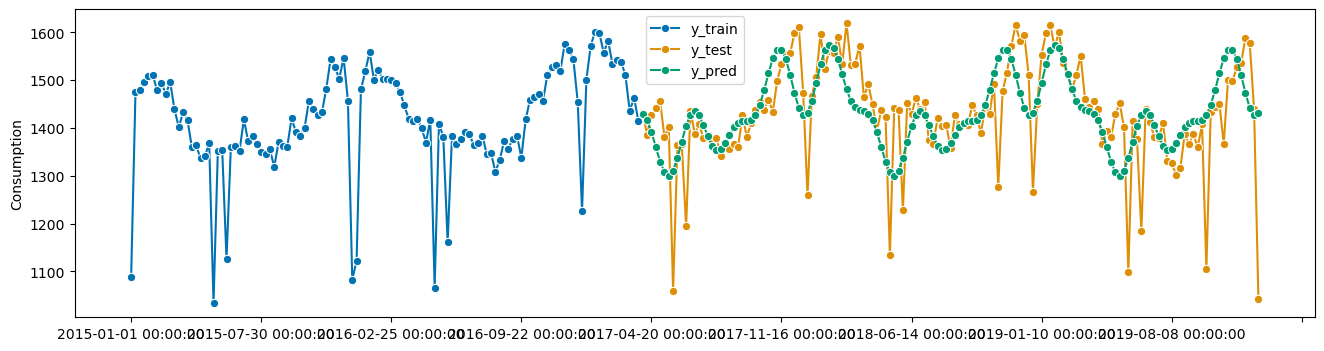

In [182]:
fh = 1+np.arange(len(y_test))#ForecastingHorizon(y_test.index, is_relative=False)
y_pred = gscv.predict(fh)

y_pred = pd.Series(y_pred.squeeze())
y_pred.index = y_test.index

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Фреймворк `sktime` также предоставляет возможности для автоматического выбора компонентов **Конвейера**, т.е. егр структуры. Это достигается с помощью преобразователя [`OptionalPassthrough`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.transformations.compose.OptionalPassthrough.html). Отметим, что у `OptionalPassthrough` есть гиперпараметр `passthrough: bool`, который можно настраивать: если выставить `False`, то он ведет себя как встроенное преобразование, если `True`, то он игнорирует преобразование. Также чтобы эффективно использовать `OptionalPasstrhough`, определите подходящий набор параметров с помощью нотации `__` (двойное подчеркивание), знакомой по `scikit-learn`. Это позволяет получать доступ и настраивать атрибуты вложенных объектов. Мы можем использовать `__` несколько раз, если у нас более двух уровней вложенности.

В следующем примере мы берем конвейер `deseasonalize/scale` и настраиваем его по четырем возможным комбинациям.


<!-- aeon also provides capabilities for automated selection of pipeline components inside a pipeline, i.e., pipeline structure. This is achieved with the OptionalPassthrough transformer.

The OptionalPassthrough transformer allows to tune whether a transformer inside a pipeline is applied to the data or not. For example, if we want to tune whether sklearn.StandardScaler is bringing an advantage to the forecast or not, we wrap it in OptionalPassthrough. Internally, OptionalPassthrough has a hyperparameter passthrough: bool that is tuneable; when False the composite behaves like the wrapped transformer, when True, it ignores the transformer within.

To make effective use of OptionalPasstrhough, define a suitable parameter set using the __ (double underscore) notation familiar from scikit-learn. This allows to access and tune attributes of nested objects like TabularToSeriesAdaptor(StandardScaler()). We can use __ multiple times if we have more than two levels of nesting.

In the following example, we take a deseasonalize/scale pipeline and tune over the four possible combinations of deseasonalizer and scaler being included in the pipeline yes/no (2 times 2 = 4); as well as over the forecaster’s and the scaler’s parameters.

Note: this could be arbitrarily combined with MultiplexForecaster, as in Section 3.4.1, to select over pipeline architecture as well as over pipeline structure.

Note: scikit-learn and aeon do not support conditional parameter sets at current (unlike, e.g., the mlr3 package). This means that the grid search will optimize over the scaler’s parameters even when it is skipped. Designing/implementing this capability would be an interesting area for contributions or research. -->

In [183]:
from sklearn.preprocessing import StandardScaler

from sktime.forecasting.compose import TransformedTargetForecaster
from sktime.forecasting.model_selection import (
    ForecastingGridSearchCV,
    SlidingWindowSplitter,
)
from sktime.forecasting.naive import NaiveForecaster
from sktime.transformations.series.adapt import TabularToSeriesAdaptor
from sktime.transformations.compose import OptionalPassthrough
from sktime.transformations.series.detrend import Deseasonalizer

warnings.simplefilter('ignore', category=UserWarning)

In [184]:
pipe = TransformedTargetForecaster(
    steps=[
        ("deseasonalizer", OptionalPassthrough(Deseasonalizer())),
        ("scaler", OptionalPassthrough(TabularToSeriesAdaptor(StandardScaler()))),
        ("forecaster", NaiveForecaster(sp=52)),
    ]
)

cv = SlidingWindowSplitter(initial_window=104, window_length=52, start_with_window=True)

param_grid = {
    "deseasonalizer__passthrough": [True, False],
    "scaler__transformer__transformer__with_mean": [True, False],
    "scaler__passthrough": [True, False],
    "forecaster__strategy": ["drift", "mean", "last"],
}

gscv = ForecastingGridSearchCV(forecaster=pipe, param_grid=param_grid, cv=cv, n_jobs=-1)
gscv.fit(y_train.values)

gscv.best_params_

{'deseasonalizer__passthrough': True,
 'forecaster__strategy': 'last',
 'scaler__passthrough': True,
 'scaler__transformer__transformer__with_mean': True}

sMAPE = 0.042


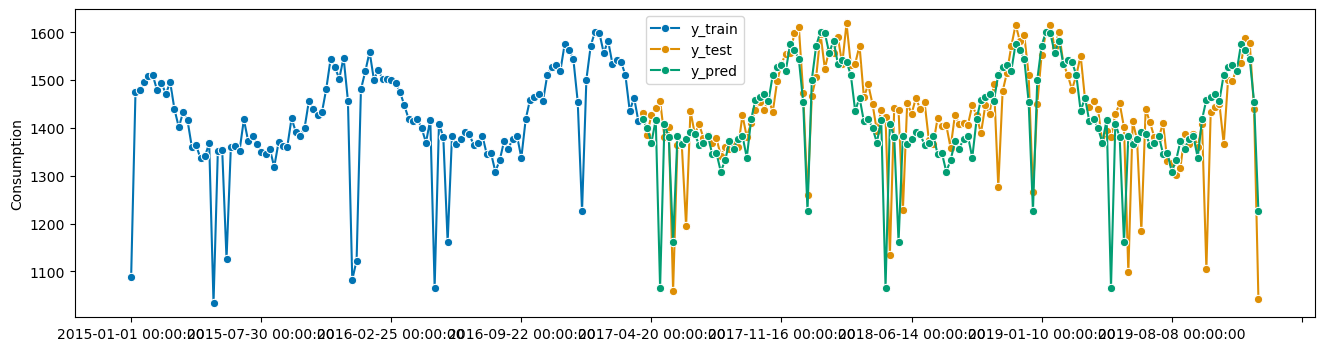

In [185]:
fh = 1+np.arange(len(y_test))#ForecastingHorizon(y_test.index, is_relative=False)
y_pred = gscv.predict(fh)

y_pred = pd.Series(y_pred.squeeze())
y_pred.index = y_test.index

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Отметим также возможность построения конвейеров с выбором моделей напрямую в [`grid search`](https://sktime-backup.readthedocs.io/en/latest/api_reference/auto_generated/sktime.forecasting.model_selection.ForecastingGridSearchCV.html).

In [186]:
pipe = TransformedTargetForecaster(
    steps=[
        ("imputer", Imputer()),
        ("forecaster", NaiveForecaster())
    ])


gscv = ForecastingGridSearchCV(
    forecaster=pipe,
    param_grid=[{
        "forecaster": [NaiveForecaster(sp=52)],
        "forecaster__strategy": ["drift", "last", "mean"],
    },
    {
        "imputer__method": ["mean", "drift"],
        "forecaster": [ThetaForecaster(sp=52)],
    },
    {
        "imputer__method": ["mean", "median"],
        "forecaster": [ExponentialSmoothing(sp=52)],
        "forecaster__trend": ["add", "mul"],
    },
    ],
    cv=cv,
)  
gscv.fit(y)  
ForecastingGridSearchCV(...)
y_pred = gscv.predict(fh=[1,2,3])

NameError: name 'ThetaForecaster' is not defined

## Ансамблирование моделей

Другим важным методом улучшения качества прогнозов является использование [методов ансамблирования предсказателей](https://petolau.github.io/Ensemble-of-trees-for-forecasting-time-series/). 
Напомним, что цель ансамблирования - объеденение нескольких моделей для уменьшения смещния предсказания каждой из них.
В частности, прогнозы каждой модели (базовые модели) складываются и используются в качестве входных данных для конечной модели (метамодели) для вычисления прогноза.
Методов ансамблирования может быть несколько, среди них такие как:
* Простой ансамбль предсказателей [`EnsembleForecaster`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.EnsembleForecaster.html) - аггрегированин результатов предсказания с заданными весовыми значениями.
* Аво-Ансамблиевый предсказатель [`AutoEnsembleForecaster`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.AutoEnsembleForecaster.html) - автовыбор весовых значений предсказателей.
* Стековый ансамбль предсказателей [`StackingForecaster`](https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.compose.StackingForecaster.html)  - стек предсказатей со сложной метомоделью.

> Напомним, что данные типы ансамблирования не единственные, могут также быть, например, [блендинг](https://habr.com/ru/articles/799483/). 
<!-- In machine learning, stacking is an ensemble technique that combines multiple models to reduce their biases and improve predictive performance. Specifically, the predictions of each model (base models) are stacked and used as input to a final model (metamodel) to compute the prediction.https://skforecast.org/0.11.0/faq/stacking-ensemble-models-forecasting -->

In [ ]:
from sktime.forecasting.compose import EnsembleForecaster

In [ ]:
TBATS(sp=52, use_box_cox=False, use_trend=False,
      use_damped_trend=False, use_arma_errors=False, n_jobs=1)

hw     = ExponentialSmoothing(trend="add", seasonal='add', sp=52)

damped = ExponentialSmoothing(trend="add", seasonal='add', damped_trend=True, sp=52)

naive  = NaiveForecaster(strategy='last', window_length=52, sp=52)

forecaster = EnsembleForecaster(
    [
        ("hw", hw),
        ("damped", damped),
        ("naive", naive),
    ], weights=[4, 10, 4]
)

forecaster.fit(y_train.values)


fh = 1+np.arange(len(y_test))#ForecastingHorizon(y_test.index, is_relative=False)
y_pred = forecaster.predict(fh)

y_pred = pd.Series(y_pred.squeeze())
y_pred.index = y_test.index


plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

Для оценки модели мы иногда хотим оценить несколько прогнозов, используя временную перекрестную валидацию со скользящим окном по тестовым данным. Для этого мы можем использовать прогнозисты из модуля `online_forecasting`, которые используют составной прогнозист, `PredictionWeightedEnsemble`, чтобы отслеживать потери, накопленные каждым прогнозистом, и создавать прогноз, взвешенный по прогнозам наиболее "точных" прогнозистов.
Обратите внимание, что задача прогнозирования изменилась: мы делаем 35 прогнозов, так как нам нужен первый прогноз для обновления весов, мы не прогнозируем на 36 шагов вперед.

Сначала нам нужно инициализировать `PredictionWeightedEnsembler`, который будет отслеживать потери, накопленные каждым прогнозистом, и определить, какую функцию потерь мы хотим использовать.

Затем мы можем создать прогнозиста, определив отдельные прогнозы и указав используемый `PredictionWeightedEnsembler`. Затем, подогнав наши прогнозисты и выполнив обновление и предсказание с помощью функции `update_predict`, мы получим:

In [ ]:
from sktime.forecasting.online_learning import (
    NormalHedgeEnsemble,
    OnlineEnsembleForecaster,
)
from sktime.performance_metrics.forecasting import mean_squared_error
 
hedge_expert = NormalHedgeEnsemble(n_estimators=3, loss_func=mean_squared_error)

In [ ]:
forecaster = OnlineEnsembleForecaster(
    [
        ("hw", hw),
        ("damped", damped),
        ("naive", naive),
    ],
    ensemble_algorithm=hedge_expert,
)

fh = 1+np.arange(len(y_test))#ForecastingHorizon(y_test.index, is_relative=False)
forecaster.fit(y=y_train.values, fh=fh)
y_pred = forecaster.update_predict_single(y_test.values)


y_pred = pd.Series(y_pred.squeeze())
y_pred.index = y_test.index

plot_series(y_train, y_test, y_pred, labels=["y_train", "y_test", "y_pred"])
print(f'sMAPE = {smape(y_pred.values, y_test.values):.3f}')

В конце укажаем на возмжность построения и более сложных ансамблей, однако в режимах, пока не заданных в фреймворке.

## Вместо заключения


В конце отметим некоторые «эмпирические» рекомендации к выбору предсказателей:

* всегда сначала пробуйте более простые модели
* всегда сравнивайте «простое» и «сложное»
* всегда сравнивайте собственный вариант использования, производительность тестов и ключевые показатели эффективности (например, интерпретируемость)

Отметим, что фреймворк [`sktime`](https://github.com/sktime/sktime) постоянно развивается, в том числе расширяется. Например, в последних версиях в фреймворк добавлены большое число моделей глубокого обучения нейронных сетей и других интересных современных алгоритмов. 

>Дополнительно отметим возможность встраивания [своих алгоритмов в интерфейс фреймворка](https://www.sktime.net/en/latest/examples/01_forecasting.html#4.-Extension-guide---implementing-your-own-forecaster). Для этого может быть рассмотрен в том числе [следующий шаблон](https://github.com/sktime/sktime/blob/main/extension_templates/forecasting_supersimple.py).
<!-- 
Приведем несколько примеров ранее не рассмотренных современных алгоритмов, встроенных  в фреймворк. Одними из таких являются модели предложенные в рамках знаковой статьи [*Are Transformers Effective for Time Series Forecasting?*](https://arxiv.org/pdf/2205.13504.pdf). В рамках статьи авторы предложили линейные модели, вдохнавленные эффектом "длительной памяти" в замен популярных архитектур "Трансформеров". Рассмотрим такую модель `LTSFLinearForecaster`.

from sktime.forecasting.ltsf import LTSFLinearForecaster, LTSFNLinearForecaster , LTSFDLinearForecaster

# deep learning models may have parameters set in line with fh, data, etc.
forecaster = LTSFLinearForecaster(
    seq_len=10, pred_len=10, in_channels=1, num_epochs=50, individual=True
)

fh = 1+np.arange(len(y_test))#ForecastingHorizon(y_test.index, is_relative=False)
forecaster.fit(y=y_train.values, fh=fh)
y_pred = forecaster.update_predict_single(y_test.values) 

from sktime.forecasting.neuralforecast import NeuralForecastRNN

forecaster = NeuralForecastRNN(freq = y.index.freq,  
                          context_size=10,     
                          decoder_hidden_size=200,   
                          decoder_layers=2 )


-->

<!-- Допонительно также отметим возможность построения прогнозов (скорее регрессий) временных рядов на основе [признаков  ВР](https://tsfresh.readthedocs.io/en/latest/). Такие прзинаки строятся по [лагам и стат. параметрам сегментов ВР](https://htmlpreview.github.io/?https://github.com/robjhyndman/M4metalearning/blob/master/docs/M4_methodology.html#features). Признаковыве предсказатели являются скорее экзотичными, однако позволяют сокращать пространство для хранения ВР. В этой части мы попробуем признаки библиотеки [`tsfeatures`](https://github.com/Nixtla/tsfeatures). Отметим, что указанный подход [не единственный](https://www.sktime.net/en/stable/examples/transformation/feature_extraction_with_tsfresh.html). -->